# INTRO

## Notebook for applying Data Assimilation on modern data (Based on Caldarescu et al., 2021 data from Gulf of Panama)

### Assemble data in the proxy domain using offline (block update) assimilation instead of point-by-point
### Assemble data in SST (D47), SAT (D47), SSS (d18Oc) and precipitation domain (SSS data as measurements, not modelled)

Author: **N.J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

**References used in coding**

*Data assimiliation*
- Steiger, N.J., Hakim, G.J., Steig, E.J., Battisti, D.S., Roe, G.H., 2014. Assimilation of Time-Averaged Pseudoproxies for Climate Reconstruction. Journal of Climate 27, 426–441. https://doi.org/10.1175/JCLI-D-12-00693.1
- Hakim, G.J., Emile-Geay, J., Steig, E.J., Noone, D., Anderson, D.M., Tardif, R., Steiger, N., Perkins, W.A., 2016. The last millennium climate reanalysis project: Framework and first results. Journal of Geophysical Research: Atmospheres 121, 6745–6764. https://doi.org/10.1002/2016JD024751
- King, J., Tierney, J., Osman, M., Judd, E.J., Anchukaitis, K.J., 2023. DASH: a MATLAB toolbox for paleoclimate data assimilation. Geoscientific Model Development 16, 5653–5683. https://doi.org/10.5194/gmd-16-5653-2023
- Judd, E.J., Tierney, J.E., Lunt, D.J., Montañez, I.P., Huber, B.T., Wing, S.L., Valdes, P.J., 2024. A 485-million-year history of Earth’s surface temperature. Science 385, eadk3705. https://doi.org/10.1126/science.adk3705

*Data sources*
- Caldarescu, D. E., Sadatzki, H., Andersson, C., Schäfer, P., Fortunato, H., and Meckler, A. N.: Clumped isotope thermometry in bivalve shells: A tool for reconstructing seasonal upwelling, Geochimica et Cosmochimica Acta, 294, 174–191, https://doi.org/10.1016/j.gca.2020.11.019, 2021.
- Gutiérrez, J.M., R.G. Jones, G.T. Narisma, L.M. Alves, M. Amjad, I.V.Gorodetskaya, M. Grose, N.A.B. Klutse, S. Krakovska, J. Li, D.Martínez-Castro, L.O. Mearns, S.H. Mernild, T. Ngo-Duc, B. van den Hurk, and J.-H. Yoon, 2021: Atlas. In Climate Change 2021: The Physical Science Basis. Contribution of Working Group I to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change [Masson-Delmotte, V., P. Zhai, et al. (eds.)]. Cambridge University Press, Cambridge, United Kingdom and New York, NY, USA, pp. 1927–2058, doi:10.1017/9781009157896.021. Interactive Atlas available from http://interactive-atlas.ipcc.ch/
- Iturbide, M., Fernández, J., Gutiérrez, J.M. et al. Implementation of FAIR principles in the IPCC: the WGI AR6 Atlas repository. Sci Data 9, 629 (2022). https://doi.org/10.1038/s41597-022-01739-y
- Boutin, J.; Vergely, J.-L.; Koehler, J.; Rouffi, F.; Reul, N. (2019): ESA Sea Surface Salinity Climate Change Initiative (Sea_Surface_Salinity_cci): Weekly Sea Surface Salinity product v1.8. Centre for Environmental Data Analysis, date of citation. https://catalogue.ceda.ac.uk/uuid/e5666094722c4ca787e323a9585b0a92
- SST Monitoring - Physical Monitoring | Smithsonian Tropical Research Institute, Physical Monitoring, [URL](https://striresearch.si.edu/physical-monitoring/sst-monitoring/)


*Calibration equations*
- Graniero, L. E., Grossman, E. L., Robbins, J., Morales, J., Thompson, R., and O’Dea, A.: Conus Shell δ13C values as proxies for δ13CDIC in tropical waters, Palaeogeography, Palaeoclimatology, Palaeoecology, 472, 119–127, https://doi.org/10.1016/j.palaeo.2017.02.007, 2017.
- Daëron, M. and Vermeesch, P.: Omnivariant generalized least squares regression: Theory, geochronological applications, and making the case for reconciled Δ47 calibrations, Chemical Geology, 121881, https://doi.org/10.1016/j.chemgeo.2023.121881, 2023.
- Grossman, E. L. and Ku, T.-L.: Oxygen and carbon isotope fractionation in biogenic aragonite: temperature effects, Chemical Geology: Isotope Geoscience section, 59, 59–74, 1986.
- Gonfiantini, R., Stichler, W., and Rozanski, K.: Standards and intercomparison materials distributed by the International Atomic Energy Agency for stable isotope measurements, 1995.
- Dettman, D. L., Reische, A. K., and Lohmann, K. C.: Controls on the stable isotope composition of seasonal growth bands in aragonitic fresh-water bivalves (Unionidae), Geochimica et Cosmochimica Acta, 63, 1049–1057, 1999.

## Load packages

In [2]:
# Load packages
import numpy as np # The 'numpy' package is needed for matrix operations and calculations
import pandas as pd # The 'pandas' package helps us to import and manage data
import math as math # Math package for data cleaning
from scipy import stats # Import scipy.package for confidence intervals
from sklearn.preprocessing import StandardScaler # Import the package for standardizing data
import D47calib as D47c # Import the package for treating clumped isotope data by Daëron and Vermeesch (2023; https://github.com/mdaeron/D47calib)
import matplotlib.pyplot as plt # The 'matplotlib' package contains tools needed to plot our data and results
from matplotlib.patches import Rectangle # The 'Rectangle' function is used to add rectangles to our plots
import seaborn as sns # The 'seaborn' package is used to make our plots look nicer (e.g. enable heatmaps)
import warnings # The 'warnings' package is used to suppress warnings that might occur during the calculations
%matplotlib inline

# PRIOR - MONTHLY
## Load monthly SST model data

In [3]:
# Load model SST data as prior and show data structure
IPCC_Atlas_SST = pd.read_csv('Modern case/SSTdat.csv')  # Load the data into Python and in the Jupyter environment.
# Pivot the data to have months as columns and grid cells (lat, lon) as rows
IPCC_Atlas_SST = IPCC_Atlas_SST.pivot(index=['lat', 'lon'], columns='month', values='tos').reset_index()
# Rename months to two-letter codes
month_mapping = {
    'January': 'ja', 'February': 'fb', 'March': 'mr', 'April': 'ar', 'May': 'my', 
    'June': 'jn', 'July': 'jl', 'August': 'ag', 'September': 'sp', 'October': 'ot', 
    'November': 'nv', 'December': 'dc'
}
IPCC_Atlas_SST.rename(columns=month_mapping, inplace=True) # Rename the columns to two-letter codes for months
IPCC_Atlas_SST.head()

month,lat,lon,ar,ag,dc,fb,ja,jl,jn,mr,my,nv,ot,sp
0,7.5,-81.5,27.870666,28.807864,28.234173,27.020926,27.569698,28.706740,28.716516,27.074181,28.717969,28.279754,28.346880,28.698233
1,7.5,-80.5,26.808416,27.472491,28.242612,26.442010,27.180057,27.630609,27.446476,26.412426,27.232879,28.372525,27.958568,27.736655
2,7.5,-79.5,26.814397,28.957019,28.453653,26.170235,27.295458,28.806538,28.734703,26.018813,28.156229,28.510441,28.605194,28.915533
3,7.5,-78.5,26.891758,29.054418,28.537700,26.116582,27.303514,28.938615,28.816935,26.014780,28.164300,28.650586,28.788851,29.053953
4,7.5,-77.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Load monthly SAT model data

In [4]:
# Load model SAT data as prior and show data structure
IPCC_Atlas_SAT = pd.read_csv('Modern case/SATdat.csv')  # Load the data into Python and in the Jupyter environment.
# Pivot the data to have months as columns and grid cells (lat, lon) as rows
IPCC_Atlas_SAT = IPCC_Atlas_SAT.pivot(index=['lat', 'lon'], columns='month', values='tas').reset_index()
# Rename months to two-letter codes
month_mapping = {
    'January': 'ja', 'February': 'fb', 'March': 'mr', 'April': 'ar', 'May': 'my', 
    'June': 'jn', 'July': 'jl', 'August': 'ag', 'September': 'sp', 'October': 'ot', 
    'November': 'nv', 'December': 'dc'
}
IPCC_Atlas_SAT.rename(columns=month_mapping, inplace=True) # Rename the columns to two-letter codes for months
IPCC_Atlas_SAT.head()

month,lat,lon,ar,ag,dc,fb,ja,jl,jn,mr,my,nv,ot,sp
0,7.5,-81.5,27.583176,26.552208,26.558420,26.835735,26.682741,26.458174,26.592540,27.186361,27.313580,26.218864,26.229807,26.476027
1,7.5,-80.5,27.275017,26.536266,26.511211,26.583742,26.550386,26.459099,26.570900,26.928097,27.066269,26.204203,26.266203,26.487984
2,7.5,-79.5,27.001470,26.600628,26.552113,26.399340,26.497887,26.529715,26.607323,26.664957,26.917267,26.256363,26.311296,26.543280
3,7.5,-78.5,26.625885,26.183826,26.066435,26.162770,26.128641,26.111752,26.153196,26.438007,26.403248,25.779915,25.811575,26.081343
4,7.5,-77.5,26.058582,25.183080,24.992147,25.759280,25.274055,25.143060,25.183006,26.192318,25.495410,24.729294,24.765930,25.051905


## Load monthly SSS model outcomes (HadGEM3-GC31-LL 1995-2014)

In [5]:
# Load HadGEM3 SSS data as prior and show data structure
HadGEM3_SSS = pd.read_csv('Modern case/HadGEM3_SSS_ROI_Panama.csv')  # Load the data into Python and in the Jupyter environment.
# Convert 'timeseries' column to datetime
HadGEM3_SSS['date'] = pd.to_datetime(HadGEM3_SSS['date'], format='%Y-%m-%d')
# Rename longitude and latitude columns to 'lon' and 'lat'
HadGEM3_SSS = HadGEM3_SSS.rename(columns={'longitude': 'lon', 'latitude': 'lat'})

# Extract month as two-letter code
month_abbr = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']
HadGEM3_SSS['month'] = HadGEM3_SSS['date'].dt.month.apply(lambda x: month_abbr[x-1])

# Group by lat, lon, and month, then calculate the mean salinity for each group
HadGEM3_SSS = HadGEM3_SSS.groupby(['lat', 'lon', 'month'], as_index=False)['SSS'].mean()

# Pivot to make one column per month, keeping all data
HadGEM3_SSS = HadGEM3_SSS.pivot(index=['lat', 'lon'], columns='month', values='SSS').reset_index()

# Round latitudes to nearest whole value and subtract 0.5 to align with model grid
HadGEM3_SSS['lat'] = HadGEM3_SSS['lat'].round().astype(int) - 0.5

HadGEM3_SSS.head()

month,lat,lon,ag,ar,dc,fb,ja,jl,jn,mr,my,nv,ot,sp
0,7.5,-84.5,30.189136,31.977873,31.473394,30.929856,30.345405,30.069491,30.195029,31.414025,32.039624,30.546265,29.788526,29.800602
1,7.5,-83.5,29.721171,32.084429,30.293614,30.814989,29.829491,30.040615,29.755975,31.457839,31.915529,30.029132,29.261298,29.054229
2,7.5,-82.5,29.425948,32.328173,29.279388,30.813826,29.614315,29.724405,29.525366,31.731921,31.874593,29.038743,28.927378,28.785658
3,7.5,-81.5,29.718203,32.912211,29.224964,31.114077,29.523134,29.884337,29.375634,32.313844,31.924800,28.856813,28.677410,28.918779
4,7.5,-80.5,28.278848,33.240089,28.165424,32.267726,30.310458,29.069918,28.696457,32.986556,31.064224,28.199434,27.682365,27.385693


## Load monthly precipitation data

In [6]:
# Load model precip data as prior and show data structure
IPCC_Atlas_precip = pd.read_csv('Modern case/precipdat.csv')  # Load the data into Python and in the Jupyter environment.
# Pivot the data to have months as columns and grid cells (lat, lon) as rows
IPCC_Atlas_precip = IPCC_Atlas_precip.pivot(index=['lat', 'lon'], columns='month', values='pr').reset_index()
# Rename months to two-letter codes
month_mapping = {
    'January': 'ja', 'February': 'fb', 'March': 'mr', 'April': 'ar', 'May': 'my', 
    'June': 'jn', 'July': 'jl', 'August': 'ag', 'September': 'sp', 'October': 'ot', 
    'November': 'nv', 'December': 'dc'
}
IPCC_Atlas_precip.rename(columns=month_mapping, inplace=True) # Rename the columns to two-letter codes for months
IPCC_Atlas_precip.head()

month,lat,lon,ar,ag,dc,fb,ja,jl,jn,mr,my,nv,ot,sp
0,7.5,-81.5,1.689385,12.423080,2.590541,0.387124,0.582265,12.162777,11.670250,0.545877,6.474045,7.746123,11.768444,12.815062
1,7.5,-80.5,1.779216,12.493553,2.881293,0.449284,0.714600,12.262433,11.679930,0.586808,6.634595,7.909942,11.458197,12.675345
2,7.5,-79.5,2.001780,12.659093,3.562033,0.458198,0.814399,12.203677,11.351872,0.630577,7.039908,9.019142,12.075278,12.758909
3,7.5,-78.5,2.500152,13.219075,4.115735,0.685854,1.062848,12.568253,11.503000,0.875989,7.622621,9.605698,12.277294,13.266212
4,7.5,-77.5,3.386591,13.334969,4.033405,0.920459,1.207844,12.501793,11.494451,1.238471,8.514819,9.458278,12.520760,13.403852


## Combine SST, SAT, SSS and precipitation data by lat and lon

In [7]:
# Merge the datasets of SST, SAT, SSS, and precipitation, force suffixes to be added to the column names
IPCC_Atlas = pd.merge(
    IPCC_Atlas_SST.rename(columns={c: c + '_SST' for c in IPCC_Atlas_SST.columns if c not in ['lat', 'lon']}),
    IPCC_Atlas_SAT.rename(columns={c: c + '_SAT' for c in IPCC_Atlas_SAT.columns if c not in ['lat', 'lon']}),
    on=['lat', 'lon'],
    how='outer'
)

IPCC_Atlas = pd.merge(
    IPCC_Atlas,
    HadGEM3_SSS.rename(columns={c: c + '_SSS' for c in HadGEM3_SSS.columns if c not in ['lat', 'lon']}),
    on=['lat', 'lon'],
    how='outer'
)

IPCC_Atlas = pd.merge(
    IPCC_Atlas,
    IPCC_Atlas_precip.rename(columns={c: c + '_precip' for c in IPCC_Atlas_precip.columns if c not in ['lat', 'lon']}),
    on=['lat', 'lon'],
    how='outer'
)

# Display the combined dataset
IPCC_Atlas.head()

month,lat,lon,ar_SST,ag_SST,dc_SST,fb_SST,ja_SST,jl_SST,jn_SST,mr_SST,...,dc_precip,fb_precip,ja_precip,jl_precip,jn_precip,mr_precip,my_precip,nv_precip,ot_precip,sp_precip
0,7.5,-84.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7.5,-83.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.5,-82.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.5,-81.5,27.870666,28.807864,28.234173,27.020926,27.569698,28.706740,28.716516,27.074181,...,2.590541,0.387124,0.582265,12.162777,11.67025,0.545877,6.474045,7.746123,11.768444,12.815062
4,7.5,-80.5,26.808416,27.472491,28.242612,26.442010,27.180057,27.630609,27.446476,26.412426,...,2.881293,0.449284,0.714600,12.262433,11.67993,0.586808,6.634595,7.909942,11.458197,12.675345


## Calculate the monthly prior for model SST, SAT, SSS and precipitation values

In [8]:
# Create list of month names
months = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']

# Prior SST, SAT, SSS & precipitation estimates from climate models (mean)
mu_prior_SAT_monthly = np.array(IPCC_Atlas[[f"{month}_SAT" for month in months]].mean(axis=0, skipna=True))
mu_prior_SST_monthly = np.array(IPCC_Atlas[[f"{month}_SST" for month in months]].mean(axis=0, skipna=True))
mu_prior_SSS_monthly = np.array(IPCC_Atlas[[f"{month}_SSS" for month in months]].mean(axis=0, skipna=True))
mu_prior_precip_monthly = np.array(IPCC_Atlas[[f"{month}_precip" for month in months]].mean(axis=0, skipna=True))

# Covariance between months in prior SST, SAT, SSS, and precip estimates from climate models (covariance matrix)
cov_prior_SAT_monthly = np.cov(IPCC_Atlas[[f"{month}_SAT" for month in months]].dropna(), rowvar=False)
cov_prior_SST_monthly = np.cov(IPCC_Atlas[[f"{month}_SST" for month in months]].dropna(), rowvar=False)
cov_prior_SSS_monthly = np.cov(IPCC_Atlas[[f"{month}_SSS" for month in months]].dropna(), rowvar=False)
cov_prior_precip_monthly = np.cov(IPCC_Atlas[[f"{month}_precip" for month in months]].dropna(), rowvar=False)

# Store copy of original prior means to keep when later updating the prior
mu_prior_SAT_monthly_original, cov_prior_SAT_monthly_original = mu_prior_SAT_monthly.copy(), cov_prior_SAT_monthly.copy()
mu_prior_SST_monthly_original, cov_prior_SST_monthly_original = mu_prior_SST_monthly.copy(), cov_prior_SST_monthly.copy()
mu_prior_SSS_monthly_original, cov_prior_SSS_monthly_original = mu_prior_SSS_monthly.copy(), cov_prior_SSS_monthly.copy()
mu_prior_precip_monthly_original, cov_prior_precip_monthly_original = mu_prior_precip_monthly.copy(), cov_prior_precip_monthly.copy()

# Extract the standard deviations (uncertainty) from the covariance matrix
std_prior_SAT_monthly = np.sqrt(np.diag(cov_prior_SAT_monthly))
std_prior_SST_monthly = np.sqrt(np.diag(cov_prior_SST_monthly))
std_prior_SSS_monthly = np.sqrt(np.diag(cov_prior_SSS_monthly))
std_prior_precip_monthly = np.sqrt(np.diag(cov_prior_precip_monthly))

print("SAT Monthly Means:", mu_prior_SAT_monthly)
print("SAT Monthly Std Devs:", std_prior_SAT_monthly)
print("SST Monthly Means:", mu_prior_SST_monthly)
print("SST Monthly Std Devs:", std_prior_SST_monthly)
print("SSS Monthly Means:", mu_prior_SSS_monthly)
print("SSS Monthly Std Devs:", std_prior_SSS_monthly)
print("Precip Monthly Means:", mu_prior_precip_monthly)
print("Precip Monthly Std Devs:", std_prior_precip_monthly)

SAT Monthly Means: [26.19674833 26.2856926  26.61780667 26.9355932  26.83360707 26.53449047
 26.469068   26.5685366  26.55148913 26.3253362  26.23056327 26.30819593]
SAT Monthly Std Devs: [0.47312434 0.41409864 0.41961986 0.45581423 0.52380544 0.58817398
 0.60908107 0.63073153 0.65805864 0.67241717 0.66092167 0.57625065]
SST Monthly Means: [27.44732929 26.77931444 26.66707259 27.07042812 27.81826605 28.38219858
 28.62096962 28.7972226  29.09194208 29.15567638 28.99711452 28.42136266]
SST Monthly Std Devs: [0.38677244 0.81134486 1.05313182 1.09679318 1.00268654 0.70288835
 0.47347404 0.48010207 0.46942236 0.53116255 0.47287623 0.36093464]
SSS Monthly Means: [32.9342162  33.62086235 34.05787824 34.33567287 33.89529622 32.50127564
 32.15152274 32.05213394 31.54662009 31.37093452 31.85204499 32.38620964]
SSS Monthly Std Devs: [2.75280482 2.29538948 2.0329931  1.88701351 2.35053874 3.0075095
 2.69062003 2.87471767 3.03645453 2.85139432 2.7804909  2.98121591]
Precip Monthly Means: [ 0.953264

## Plot the monthly priors for all model values

[Text(1, 0, 'January'),
 Text(2, 0, 'February'),
 Text(3, 0, 'March'),
 Text(4, 0, 'April'),
 Text(5, 0, 'May'),
 Text(6, 0, 'June'),
 Text(7, 0, 'July'),
 Text(8, 0, 'August'),
 Text(9, 0, 'September'),
 Text(10, 0, 'October'),
 Text(11, 0, 'November'),
 Text(12, 0, 'December')]

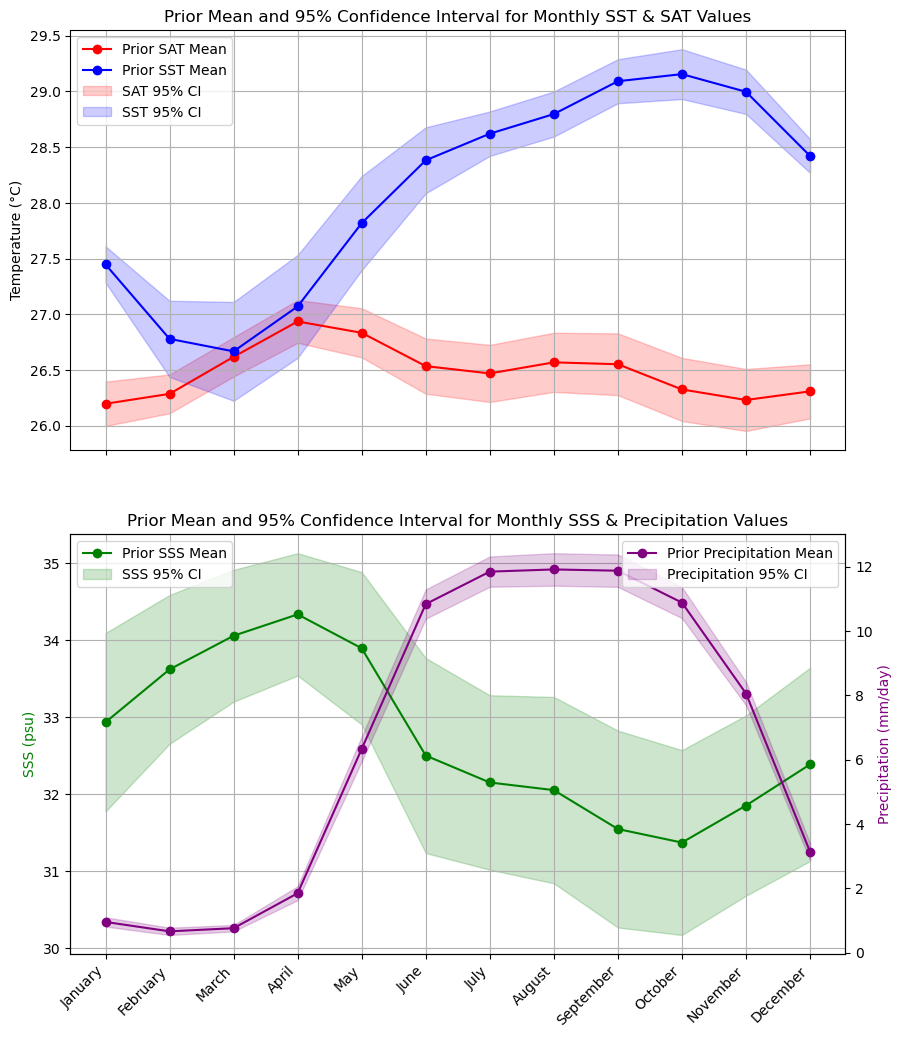

In [9]:
# Set dimensions of data
n_gridcells_monthly = len(IPCC_Atlas["lat"])  # Find the total number of models (use monthly data because monthly data has this column duplicated 3 times)

# Create a monthly scale for the x-axis
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']  # List full month names
months_scale = np.arange(len(months)) + 1  # Create monthly scale

# Create the figure and axes
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Panel 1: Plot the prior distribution for SST and SAT
axes[0].plot(months_scale, mu_prior_SAT_monthly, label='Prior SAT Mean', marker='o', color='r')
axes[0].plot(months_scale, mu_prior_SST_monthly, label='Prior SST Mean', marker='o', color='b')

# Add 95% confidence intervals for SAT
axes[0].fill_between(
    months_scale,
    mu_prior_SAT_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SAT_monthly / np.sqrt(n_gridcells_monthly),
    mu_prior_SAT_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SAT_monthly / np.sqrt(n_gridcells_monthly),
    alpha=0.2, color='r', label='SAT 95% CI'
)

# Add 95% confidence intervals for SST
axes[0].fill_between(
    months_scale,
    mu_prior_SST_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SST_monthly / np.sqrt(n_gridcells_monthly),
    mu_prior_SST_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SST_monthly / np.sqrt(n_gridcells_monthly),
    alpha=0.2, color='b', label='SST 95% CI'
)

axes[0].set_title('Prior Mean and 95% Confidence Interval for Monthly SST & SAT Values')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True)

# Panel 2: Plot the prior distribution for SSS and precipitation
axes[1].plot(months_scale, mu_prior_SSS_monthly, label='Prior SSS Mean', marker='o', color='g')
ax2 = axes[1].twinx()  # Create a secondary y-axis for precipitation
ax2.plot(months_scale, mu_prior_precip_monthly, label='Prior Precipitation Mean', marker='o', color='purple')

# Add 95% confidence intervals for SSS
axes[1].fill_between(
    months_scale,
    mu_prior_SSS_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SSS_monthly / np.sqrt(n_gridcells_monthly),
    mu_prior_SSS_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SSS_monthly / np.sqrt(n_gridcells_monthly),
    alpha=0.2, color='g', label='SSS 95% CI'
)

# Add 95% confidence intervals for precipitation
ax2.fill_between(
    months_scale,
    mu_prior_precip_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_precip_monthly / np.sqrt(n_gridcells_monthly),
    mu_prior_precip_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_precip_monthly / np.sqrt(n_gridcells_monthly),
    alpha=0.2, color='purple', label='Precipitation 95% CI'
)

axes[1].set_ylabel('SSS (psu)', color='g')
ax2.set_ylabel('Precipitation (mm/day)', color='purple')
axes[1].set_title('Prior Mean and 95% Confidence Interval for Monthly SSS & Precipitation Values')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1].grid(True)

# Update the x-axis with month names
axes[1].set_xticks(months_scale)
axes[1].set_xticklabels(month_names, rotation=45, ha="right")

### Convert SST and SAT model data to D47 domain using the regression by Daëron and Vermeesch (2023) and propagate uncertainty in the calibration

In [10]:
# Apply T47()-function from the D47calib package to all SST columns
# Identify the SST and SAT columns separately
SST_columns = [col for col in IPCC_Atlas.columns if col.endswith('_SST')]
SAT_columns = [col for col in IPCC_Atlas.columns if col.endswith('_SAT')]

# Apply the conversion function to the SST and SAT columns and add new columns for D47 and D47_SE
for col in SST_columns:
    base_col_name = col.replace('_SST', '') # Remove the '_SST' suffix from the column name
    IPCC_Atlas[f'{base_col_name}_SST_D47'], IPCC_Atlas[f'{base_col_name}_SST_D47_SE'] = zip(*IPCC_Atlas[col].apply(
        lambda x: D47c.OGLS23.T47(T = x) if not pd.isna(x) else (np.nan, np.nan)
    )) # Use zip() to unpack the tuple returned by the apply() method and apply the T47()-function to each value in the column
for col in SAT_columns:
    base_col_name = col.replace('_SAT', '') # Remove the '_SST' suffix from the column name
    IPCC_Atlas[f'{base_col_name}_SAT_D47'], IPCC_Atlas[f'{base_col_name}_SAT_D47_SE'] = zip(*IPCC_Atlas[col].apply(
        lambda x: D47c.OGLS23.T47(T = x) if not pd.isna(x) else (np.nan, np.nan)
    )) # Use zip() to unpack the tuple returned by the apply() method and apply the T47()-function to each value in the column

# Display the combined data with D47 and D47_SE columns
D47_columns = [col for col in IPCC_Atlas.columns if col.endswith('_D47')]
D47_se_columns = [col for col in IPCC_Atlas.columns if '_D47_SE' in col]
print("D47 values for all grid cells:\n", IPCC_Atlas[D47_columns].head())
print("Calibration standard errors for all grid cells:\n", IPCC_Atlas[D47_se_columns].head())

D47 values for all grid cells:
 month  ar_SST_D47  ag_SST_D47  dc_SST_D47  fb_SST_D47  ja_SST_D47  jl_SST_D47  \
0             NaN         NaN         NaN         NaN         NaN         NaN   
1             NaN         NaN         NaN         NaN         NaN         NaN   
2             NaN         NaN         NaN         NaN         NaN         NaN   
3        0.584869    0.582139    0.583807    0.587368    0.585752    0.582432   
4        0.587996    0.586037    0.583782    0.589082    0.586898    0.585573   

month  jn_SST_D47  mr_SST_D47  my_SST_D47  nv_SST_D47  ...  dc_SAT_D47  \
0             NaN         NaN         NaN         NaN  ...         NaN   
1             NaN         NaN         NaN         NaN  ...         NaN   
2             NaN         NaN         NaN         NaN  ...         NaN   
3        0.582404    0.587211    0.582399    0.583674  ...    0.588737   
4        0.586114    0.589170    0.586742    0.583404  ...    0.588877   

month  fb_SAT_D47  ja_SAT_D47  jl_SA

### Estimate seawater oxygen isotope value from salinity based on modern Gulf of Panama d18Ow-salinity relationship by Graniero et al. (2017; rainy season)

In [11]:
# Apply the d18Ow-SSS function from Graniero et al. (2017) to all SSS columns
# Identify the SSS columns
SSS_columns = [col for col in IPCC_Atlas.columns if col.endswith('_SSS')]

# Apply the conversion function to the SSS columns and add new columns for d18Ow and d18Ow_SE
for col in SSS_columns:
    base_col_name = col.replace('_SSS', '')  # Remove the '_SSS' suffix from the column name
    IPCC_Atlas[f'{base_col_name}_SSS_d18Ow'] = IPCC_Atlas[col].apply(
        lambda x: -7.89 + 0.23 * x if not pd.isna(x) else np.nan  # Calculate d18Ow
    )

# Display the combined data with d18Ow and d18Ow_SE columns
d18Ow_columns = [col for col in IPCC_Atlas.columns if col.endswith('_d18Ow')]
print("d18Ow values for all model outcomes:\n", IPCC_Atlas[d18Ow_columns].head())

d18Ow values for all model outcomes:
 month  ag_SSS_d18Ow  ar_SSS_d18Ow  dc_SSS_d18Ow  fb_SSS_d18Ow  ja_SSS_d18Ow  \
0         -0.946499     -0.535089     -0.651119     -0.776133     -0.910557   
1         -1.054131     -0.510581     -0.922469     -0.802553     -1.029217   
2         -1.122032     -0.454520     -1.155741     -0.802820     -1.078707   
3         -1.054813     -0.320192     -1.168258     -0.733762     -1.099679   
4         -1.385865     -0.244780     -1.411953     -0.468423     -0.918595   

month  jl_SSS_d18Ow  jn_SSS_d18Ow  mr_SSS_d18Ow  my_SSS_d18Ow  nv_SSS_d18Ow  \
0         -0.974017     -0.945143     -0.664774     -0.520886     -0.864359   
1         -0.980658     -1.046126     -0.654697     -0.549428     -0.983300   
2         -1.053387     -1.099166     -0.591658     -0.558844     -1.211089   
3         -1.016603     -1.133604     -0.457816     -0.547296     -1.252933   
4         -1.203919     -1.289815     -0.303092     -0.745229     -1.404130   

month  ot_SS

### Calculate carbonate oxygen isotope value from SST and seawater oxygen isotope data using Grossman and Ku (1986) with the VPDB-VSMOW scale correction by Gonfiantini et al. (1995) and Dettman et al. (1999)

In [12]:
# Iterate over each model and calculate d18Oc values
for index, row in IPCC_Atlas.iterrows():
    # Iterate over each month
    for month in months:
        SST = row[f"{month}_SST"]
        d18Ow = row[f"{month}_SSS_d18Ow"]
        if not pd.isna(SST) and not pd.isna(d18Ow):
            d18Oc = (20.6 - SST) / 4.34 + (d18Ow - 0.27)
        else:
            d18Oc = np.nan
        # Add the calculated d18Oc value to the DataFrame
        IPCC_Atlas.loc[index, f"{month}_d18Oc"] = d18Oc

# Display the updated DataFrame
IPCC_Atlas.head()


month,lat,lon,ar_SST,ag_SST,dc_SST,fb_SST,ja_SST,jl_SST,jn_SST,mr_SST,...,mr_d18Oc,ar_d18Oc,my_d18Oc,jn_d18Oc,jl_d18Oc,ag_d18Oc,sp_d18Oc,ot_d18Oc,nv_d18Oc,dc_d18Oc
0,7.5,-84.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7.5,-83.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.5,-82.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.5,-81.5,27.870666,28.807864,28.234173,27.020926,27.569698,28.706740,28.716516,27.074181,...,-2.219563,-2.26546,-2.687796,-3.273769,-3.154515,-3.216026,-3.374633,-3.349191,-3.292461,-3.197284
4,7.5,-80.5,26.808416,27.472491,28.242612,26.442010,27.180057,27.630609,27.446476,26.412426,...,-1.912361,-1.94529,-2.543542,-3.137344,-3.093875,-3.239388,-3.505681,-3.488579,-3.465035,-3.442923


### Calculate the monthly prior for model SST- and SAT-derived D47 values and SSS-derived seawater oxygen isotope values with propagated uncertainty

In [13]:
# Set the weights of the data based on the standard errors
weights_monthly_SST_D47 = 1 / IPCC_Atlas[[f"{month}_SST_D47_SE" for month in months]] ** 2
weights_monthly_SAT_D47 = 1 / IPCC_Atlas[[f"{month}_SAT_D47_SE" for month in months]] ** 2

# Change the column suffixes from "_D47_SE" to "_D47" in weights_monthly_SST_D47 to match the headers of the D47 matrix later for multiplication
weights_monthly_SST_D47.columns = [col.replace('_SST_D47_SE', '_SST_D47') for col in weights_monthly_SST_D47.columns]
weights_monthly_SAT_D47.columns = [col.replace('_SAT_D47_SE', '_SAT_D47') for col in weights_monthly_SAT_D47.columns]

# Prior D47 estimates from climate models (weighted mean)
mu_prior_SST_D47_monthly = np.array((IPCC_Atlas[[f"{month}_SST_D47" for month in months]] * weights_monthly_SST_D47).sum(axis = 0, skipna = True) / weights_monthly_SST_D47.sum(axis = 0, skipna = True)) # Calculate weighted monthly mean D47 values and convert to numpy array
mu_prior_SAT_D47_monthly = np.array((IPCC_Atlas[[f"{month}_SAT_D47" for month in months]] * weights_monthly_SAT_D47).sum(axis = 0, skipna = True) / weights_monthly_SAT_D47.sum(axis = 0, skipna = True)) # Calculate weighted monthly mean D47 values and convert to numpy array

# Calculate simple (unweighted) mean for monthly d18Ow values
mu_prior_SSS_d18Ow_monthly = np.array(IPCC_Atlas[[f"{month}_SSS_d18Ow" for month in months]].mean(axis=0, skipna=True))
mu_prior_d18Oc_monthly = np.array(IPCC_Atlas[[f"{month}_d18Oc" for month in months]].mean(axis=0, skipna=True))

# Decompose variance within and between model outcomes
model_variances_SST = IPCC_Atlas[[f"{month}_SST_D47" for month in months]].var(axis = 0, ddof = 1)  # Compute variance across models
model_variances_SAT = IPCC_Atlas[[f"{month}_SAT_D47" for month in months]].var(axis = 0, ddof = 1)  # Compute variance across models
model_variances_d18Ow = IPCC_Atlas[[f"{month}_SSS_d18Ow" for month in months]].var(axis = 0, ddof = 1)  # Compute variance across models
model_variances_d18Oc = IPCC_Atlas[[f"{month}_d18Oc" for month in months]].var(axis = 0, ddof = 1)  # Compute variance across models
measurement_variances_SST = (IPCC_Atlas[[f"{month}_SST_D47_SE" for month in months]] ** 2).mean(axis = 0, skipna = True)  # Compute variance on measurements
measurement_variances_SAT = (IPCC_Atlas[[f"{month}_SAT_D47_SE" for month in months]] ** 2).mean(axis = 0, skipna = True)  # Compute variance on measurements

# Covariance between months in prior D47 estimates from climate models (weighted covariance matrix)
cov_raw_monthly_SST = np.cov(IPCC_Atlas[[f"{month}_SST_D47" for month in months]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_raw_monthly_SAT = np.cov(IPCC_Atlas[[f"{month}_SAT_D47" for month in months]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_raw_monthly_d18Ow = np.cov(IPCC_Atlas[[f"{month}_SSS_d18Ow" for month in months]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_raw_monthly_d18Oc = np.cov(IPCC_Atlas[[f"{month}_d18Oc" for month in months]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_prior_SST_D47_monthly = cov_raw_monthly_SST.copy() # Copy covariance matrix to add uncertainty coming from the measurements
cov_prior_SAT_D47_monthly = cov_raw_monthly_SAT.copy() # Copy covariance matrix to add uncertainty coming from the measurements
np.fill_diagonal(cov_prior_SST_D47_monthly, np.diagonal(cov_raw_monthly_SST) + measurement_variances_SST)  # Add diagonal terms for measurement uncertainties (which have no covariance between models)
np.fill_diagonal(cov_prior_SAT_D47_monthly, np.diagonal(cov_raw_monthly_SAT) + measurement_variances_SAT)  # Add diagonal terms for measurement uncertainties (which have no covariance between models)

# Store copy of original prior means to keep when later updating the prior
mu_prior_SST_D47_monthly_original, cov_prior_SST_D47_monthly_original = mu_prior_SST_D47_monthly.copy(), cov_prior_SST_D47_monthly.copy()
mu_prior_SAT_D47_monthly_original, cov_prior_SAT_D47_monthly_original = mu_prior_SAT_D47_monthly.copy(), cov_prior_SAT_D47_monthly.copy()
mu_prior_SSS_d18Ow_monthly_original, cov_prior_SSS_d18Ow_monthly_original = mu_prior_SSS_d18Ow_monthly.copy(), cov_raw_monthly_d18Ow.copy()
mu_prior_d18Oc_monthly_original, cov_prior_d18Oc_monthly_original = mu_prior_d18Oc_monthly.copy(), cov_raw_monthly_d18Oc.copy()

# Extract the standard deviations (uncertainty) from the covariance matrix
std_prior_SST_D47_monthly = np.sqrt(np.diag(cov_prior_SST_D47_monthly))
std_prior_SAT_D47_monthly = np.sqrt(np.diag(cov_prior_SAT_D47_monthly))
std_prior_SSS_d18Ow_monthly = np.sqrt(np.diag(cov_raw_monthly_d18Ow))
std_prior_d18Oc_monthly = np.sqrt(np.diag(cov_raw_monthly_d18Oc))

# Print the results
print("Prior D47 estimates from SST in climate models (weighted mean):")
print(mu_prior_SST_D47_monthly)
print("Prior D47 estimates from SST in climate models (weighted covariance matrix):")
print(std_prior_SST_D47_monthly)
print("Prior D47 estimates from SAT in climate models (weighted mean):")
print(mu_prior_SAT_D47_monthly)
print("Prior D47 estimates from SAT in climate models (weighted covariance matrix):")
print(std_prior_SAT_D47_monthly)
print("Prior d18Ow estimates from SSS in climate models (weighted mean):")
print(mu_prior_SSS_d18Ow_monthly)
print("Prior d18Ow estimates from SSS in climate models (weighted covariance matrix):")
print(std_prior_SSS_d18Ow_monthly)
print("Prior d18Oc estimates from SST and d18Ow in climate models (weighted mean):")
print(mu_prior_d18Oc_monthly)
print("Prior d18Oc estimates from SST and d18Ow in climate models (weighted covariance matrix):")
print(std_prior_d18Oc_monthly)

Prior D47 estimates from SST in climate models (weighted mean):
[0.58611136 0.58807854 0.58840607 0.58721478 0.58502217 0.58337762
 0.5826824  0.58217063 0.58131734 0.58113373 0.58159202 0.58326221]
Prior D47 estimates from SST in climate models (weighted covariance matrix):
[0.00154225 0.00262358 0.0033056  0.00341755 0.00312591 0.00229783
 0.00172489 0.00174205 0.00171518 0.00185845 0.00171988 0.00147969]
Prior D47 estimates from SAT in climate models (weighted mean):
[0.58980992 0.58954575 0.58855954 0.5876189  0.58791991 0.58880551
 0.58899953 0.58870432 0.58875453 0.58942555 0.5897075  0.5894774 ]
Prior D47 estimates from SAT in climate models (weighted covariance matrix):
[0.0017582  0.00161882 0.00162767 0.00170748 0.0018731  0.00203748
 0.00209141 0.00214556 0.00221785 0.00226071 0.00223188 0.00201213]
Prior d18Ow estimates from SSS in climate models (weighted mean):
[-0.31513027 -0.15720166 -0.056688    0.00720476 -0.09408187 -0.4147066
 -0.49514977 -0.51800919 -0.63427738 -0.

### Plot the monthly prior for model SST- and SAT-derived D47 values, model SSS-derived carbonate d18O values and precipitation with propagated uncertainty

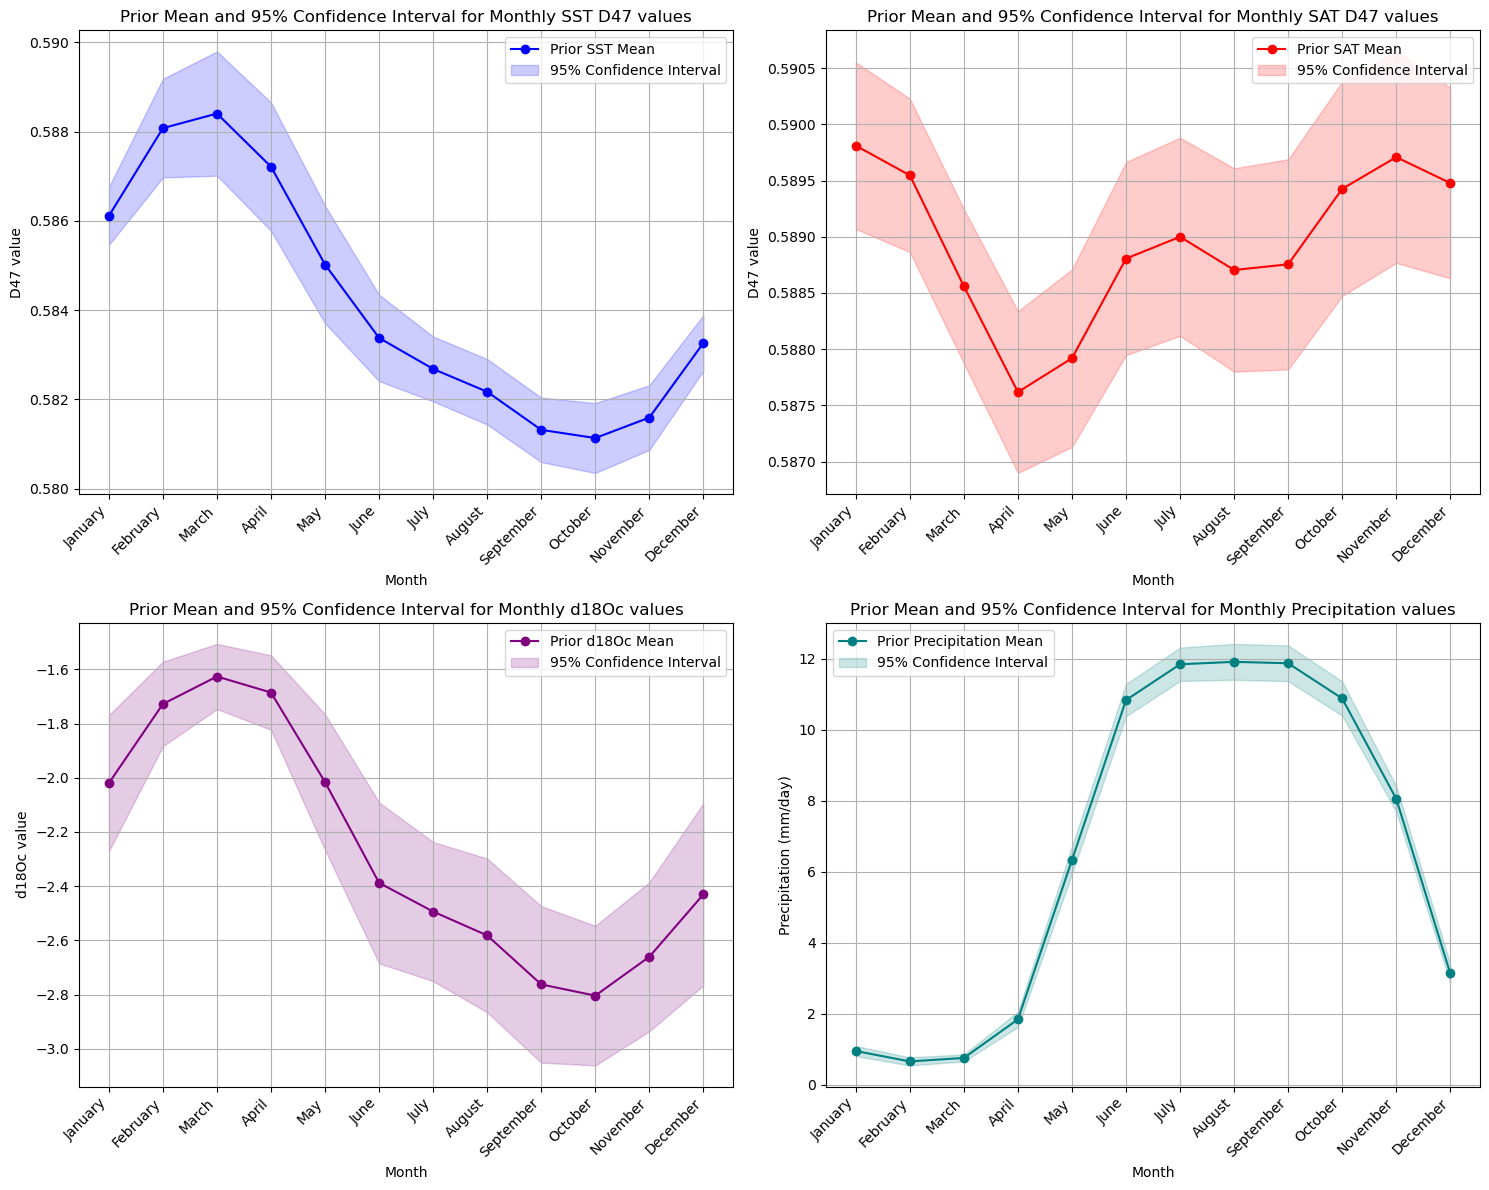

In [14]:
# Plot monthly prior distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))  # Adjust the figure to have 2x2 grid

# Plot the prior distribution for SST
axes[0, 0].plot(months_scale, mu_prior_SST_D47_monthly, label='Prior SST Mean', color='b', marker='o')
axes[0, 0].fill_between(months_scale,
                        mu_prior_SST_D47_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SST_D47_monthly / np.sqrt(n_gridcells_monthly),
                        mu_prior_SST_D47_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SST_D47_monthly / np.sqrt(n_gridcells_monthly),
                        color='b', alpha=0.2, label='95% Confidence Interval')
axes[0, 0].set_xticks(months_scale)
axes[0, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 0].set_title('Prior Mean and 95% Confidence Interval for Monthly SST D47 values')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('D47 value')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot the prior distribution for SAT
axes[0, 1].plot(months_scale, mu_prior_SAT_D47_monthly, label='Prior SAT Mean', color='r', marker='o')
axes[0, 1].fill_between(months_scale,
                        mu_prior_SAT_D47_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SAT_D47_monthly / np.sqrt(n_gridcells_monthly),
                        mu_prior_SAT_D47_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_SAT_D47_monthly / np.sqrt(n_gridcells_monthly),
                        color='r', alpha=0.2, label='95% Confidence Interval')
axes[0, 1].set_xticks(months_scale)
axes[0, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 1].set_title('Prior Mean and 95% Confidence Interval for Monthly SAT D47 values')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('D47 value')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot the prior distribution for d18Oc
axes[1, 0].plot(months_scale, mu_prior_d18Oc_monthly, label='Prior d18Oc Mean', color='purple', marker='o')
axes[1, 0].fill_between(months_scale,
                        mu_prior_d18Oc_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_d18Oc_monthly / np.sqrt(n_gridcells_monthly),
                        mu_prior_d18Oc_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_d18Oc_monthly / np.sqrt(n_gridcells_monthly),
                        color='purple', alpha=0.2, label='95% Confidence Interval')
axes[1, 0].set_xticks(months_scale)
axes[1, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 0].set_title('Prior Mean and 95% Confidence Interval for Monthly d18Oc values')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('d18Oc value')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot the prior distribution for precipitation
axes[1, 1].plot(months_scale, mu_prior_precip_monthly, label='Prior Precipitation Mean', color='teal', marker='o')
axes[1, 1].fill_between(months_scale,
                        mu_prior_precip_monthly - stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_precip_monthly / np.sqrt(n_gridcells_monthly),
                        mu_prior_precip_monthly + stats.t.ppf(1 - 0.025, n_gridcells_monthly) * std_prior_precip_monthly / np.sqrt(n_gridcells_monthly),
                        color='teal', alpha=0.2, label='95% Confidence Interval')
axes[1, 1].set_xticks(months_scale)
axes[1, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 1].set_title('Prior Mean and 95% Confidence Interval for Monthly Precipitation values')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Precipitation (mm/day)')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Update the layout and show the plot
plt.tight_layout()
plt.show()

## Calculate the monthly covariance matrix for D47 values of SST and SAT, d18Oc and precipitation

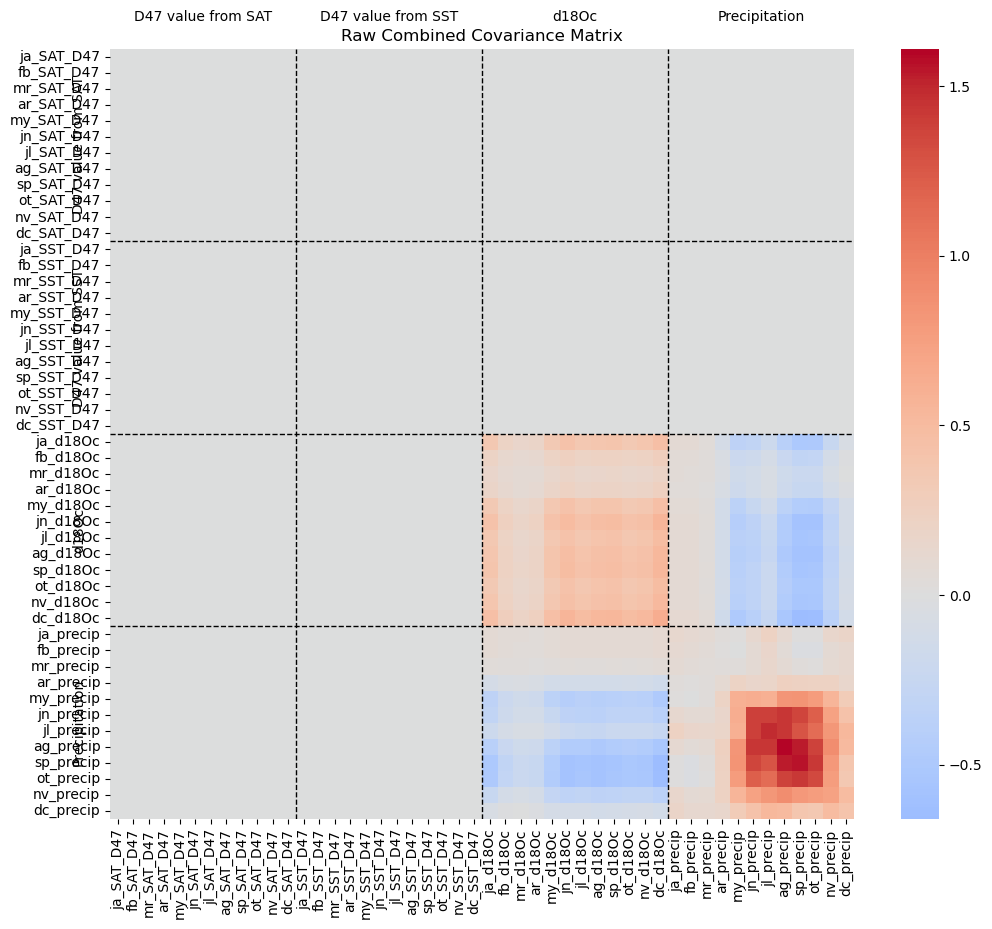

In [15]:
# Define column names for SAT, SST, d18Oc, and precipitation
SAT_D47_columns_monthly = [f"{month}_SAT_D47" for month in months]
SST_D47_columns_monthly = [f"{month}_SST_D47" for month in months]
d18Oc_columns_monthly = [f"{month}_d18Oc" for month in months]
precip_columns_monthly = [f"{month}_precip" for month in months]

# Extract the relevant columns for SAT, SST D47, d18Oc, and precipitation
SAT_D47_columns_monthly = [f"{month}_SAT_D47" for month in months]
SST_D47_columns_monthly = [f"{month}_SST_D47" for month in months]
d18Oc_columns_monthly = [f"{month}_d18Oc" for month in months]
precip_columns_monthly = [f"{month}_precip" for month in months]

# Combine the relevant columns into a single dataframe
combined_data_monthly = IPCC_Atlas[SAT_D47_columns_monthly + SST_D47_columns_monthly + d18Oc_columns_monthly + precip_columns_monthly]

# Calculate the covariance matrix for the combined data
cov_combined_monthly = np.cov(combined_data_monthly.dropna(), rowvar=False)

# Plot the heatmap of the raw combined covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cov_combined_monthly,  # Use the raw covariance matrix
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=SAT_D47_columns_monthly + SST_D47_columns_monthly + d18Oc_columns_monthly + precip_columns_monthly,
    yticklabels=SAT_D47_columns_monthly + SST_D47_columns_monthly + d18Oc_columns_monthly + precip_columns_monthly
)

# Add titles to the axes per parameter
plt.axvline(x=len(SAT_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly), color='black', linestyle='--', linewidth=1)

plt.axhline(y=len(SAT_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly), color='black', linestyle='--', linewidth=1)

# Add parameter labels
plt.text(len(SAT_D47_columns_monthly) / 2, -2, 'D47 value from SAT', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) / 2, -2, 'D47 value from SST', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) / 2, -2, 'd18Oc', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) + len(precip_columns_monthly) / 2, -2, 'Precipitation', ha='center', va='center', fontsize=10)

plt.text(-2, len(SAT_D47_columns_monthly) / 2, 'D47 value from SAT', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-2, len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) / 2, 'D47 value from SST', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-2, len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) / 2, 'd18Oc', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-2, len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) + len(precip_columns_monthly) / 2, 'Precipitation', ha='center', va='center', rotation=90, fontsize=10)

plt.title("Raw Combined Covariance Matrix")
plt.show()

## Plot normalized monthly covariance matrix between D47 values of SST and SAT, d18Oc and precipitation

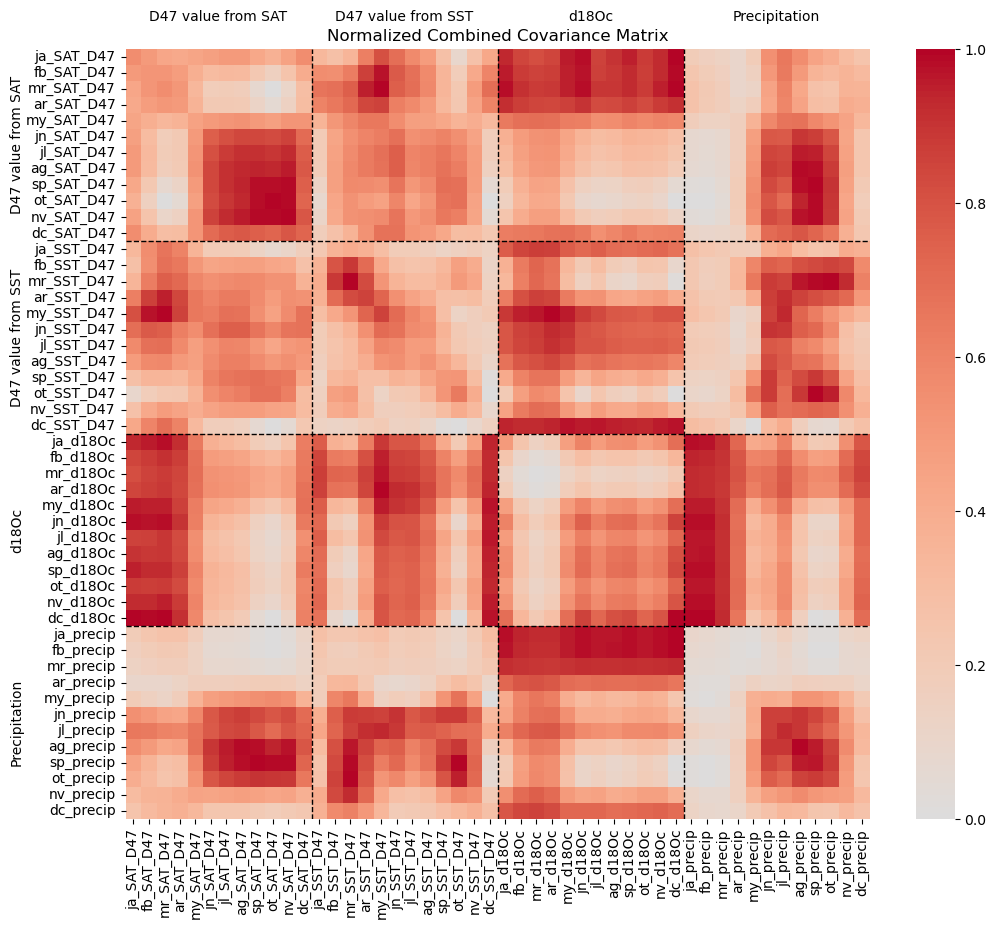

In [16]:
# Normalize each submatrix independently for better visualization
def normalize_matrix(matrix):
    min_val = np.min(matrix)
    max_val = np.max(matrix)
    return (matrix - min_val) / (max_val - min_val)

# Extract the relevant columns for SAT, SST D47, d18Oc, and precipitation
SAT_D47_columns_monthly = [f"{month}_SAT_D47" for month in months]
SST_D47_columns_monthly = [f"{month}_SST_D47" for month in months]
d18Oc_columns_monthly = [f"{month}_d18Oc" for month in months]
precip_columns_monthly = [f"{month}_precip" for month in months]

# Combine the relevant columns into a single dataframe
combined_data_monthly = IPCC_Atlas[SAT_D47_columns_monthly + SST_D47_columns_monthly + d18Oc_columns_monthly + precip_columns_monthly]

# Calculate the covariance matrix for the combined data
cov_combined_monthly = np.cov(combined_data_monthly.dropna(), rowvar=False)

# Extract the covariance matrices for SAT D47, SST D47, d18Oc, and precipitation
cov_SAT_D47_monthly = cov_combined_monthly[:len(months), :len(months)]
cov_SST_D47_monthly = cov_combined_monthly[len(months):2*len(months), len(months):2*len(months)]
cov_d18Oc_monthly = cov_combined_monthly[2*len(months):3*len(months), 2*len(months):3*len(months)]
cov_precip_monthly = cov_combined_monthly[3*len(months):, 3*len(months):]

# Extract the cross-covariance matrices
cross_cov_SAT_SST_D47_monthly = cov_combined_monthly[:len(months), len(months):2*len(months)]
cross_cov_SAT_d18Oc_monthly = cov_combined_monthly[:len(months), 2*len(months):3*len(months)]
cross_cov_SAT_precip_monthly = cov_combined_monthly[:len(months), 3*len(months):]
cross_cov_SST_d18Oc_monthly = cov_combined_monthly[len(months):2*len(months), 2*len(months):3*len(months)]
cross_cov_SST_precip_monthly = cov_combined_monthly[len(months):2*len(months), 3*len(months):]
cross_cov_d18Oc_precip_monthly = cov_combined_monthly[2*len(months):3*len(months), 3*len(months):]

# Normalize each submatrix
normalized_cov_SAT_D47_monthly = normalize_matrix(cov_SAT_D47_monthly)
normalized_cov_SST_D47_monthly = normalize_matrix(cov_SST_D47_monthly)
normalized_cov_d18Oc_monthly = normalize_matrix(cov_d18Oc_monthly)
normalized_cov_precip_monthly = normalize_matrix(cov_precip_monthly)

# Normalize each cross-covariance matrix
normalized_cross_cov_SAT_SST_D47_monthly = normalize_matrix(cross_cov_SAT_SST_D47_monthly)
normalized_cross_cov_SAT_d18Oc_monthly = normalize_matrix(cross_cov_SAT_d18Oc_monthly)
normalized_cross_cov_SAT_precip_monthly = normalize_matrix(cross_cov_SAT_precip_monthly)
normalized_cross_cov_SST_d18Oc_monthly = normalize_matrix(cross_cov_SST_d18Oc_monthly)
normalized_cross_cov_SST_precip_monthly = normalize_matrix(cross_cov_SST_precip_monthly)
normalized_cross_cov_d18Oc_precip_monthly = normalize_matrix(cross_cov_d18Oc_precip_monthly)

# Combine the normalized submatrices into a single normalized covariance matrix
normalized_cov_combined_monthly = np.block([
    [normalized_cov_SAT_D47_monthly, normalized_cross_cov_SAT_SST_D47_monthly, normalized_cross_cov_SAT_d18Oc_monthly, normalized_cross_cov_SAT_precip_monthly],
    [normalized_cross_cov_SAT_SST_D47_monthly.T, normalized_cov_SST_D47_monthly, normalized_cross_cov_SST_d18Oc_monthly, normalized_cross_cov_SST_precip_monthly],
    [normalized_cross_cov_SAT_d18Oc_monthly.T, normalized_cross_cov_SST_d18Oc_monthly.T, normalized_cov_d18Oc_monthly, normalized_cross_cov_d18Oc_precip_monthly],
    [normalized_cross_cov_SAT_precip_monthly.T, normalized_cross_cov_SST_precip_monthly.T, normalized_cross_cov_d18Oc_precip_monthly.T, normalized_cov_precip_monthly]
])

# Plot the heatmap of the normalized combined covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    normalized_cov_combined_monthly,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=SAT_D47_columns_monthly + SST_D47_columns_monthly + d18Oc_columns_monthly + precip_columns_monthly,
    yticklabels=SAT_D47_columns_monthly + SST_D47_columns_monthly + d18Oc_columns_monthly + precip_columns_monthly
)

# Add titles to the axes per parameter
plt.axvline(x=len(SAT_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly), color='black', linestyle='--', linewidth=1)

plt.axhline(y=len(SAT_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly), color='black', linestyle='--', linewidth=1)

# Add parameter labels
plt.text(len(SAT_D47_columns_monthly) / 2, -2, 'D47 value from SAT', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) / 2, -2, 'D47 value from SST', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) / 2, -2, 'd18Oc', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) + len(precip_columns_monthly) / 2, -2, 'Precipitation', ha='center', va='center', fontsize=10)

plt.text(-7, len(SAT_D47_columns_monthly) / 2, 'D47 value from SAT', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-7, len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) / 2, 'D47 value from SST', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-7, len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) / 2, 'd18Oc', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-7, len(SAT_D47_columns_monthly) + len(SST_D47_columns_monthly) + len(d18Oc_columns_monthly) + len(precip_columns_monthly) / 2, 'Precipitation', ha='center', va='center', rotation=90, fontsize=10)

plt.title("Normalized Combined Covariance Matrix")
plt.show()

## Create combined monthly state vector in D47 and d18Oc domain

In [17]:
# Combine the prior means of D47 and SAT into a single state vector
mu_prior_monthly_combined = np.concatenate((mu_prior_SST_D47_monthly, mu_prior_SAT_D47_monthly, mu_prior_d18Oc_monthly, mu_prior_precip_monthly))

# Combine the covariance matrices of D47 values of SST and SAT, including the cross-covariance
cov_prior_monthly_combined = cov_combined_monthly.copy()

# PRIOR - SEASONAL

## Seasonal model data (convert the IPCC_Atlas data to seasonal means)

In [18]:
# Define the seasons
seasons = {
    "winter": ["dc", "ja", "fb"],
    "spring": ["mr", "ar", "my"],
    "summer": ["jn", "jl", "ag"],
    "autumn": ["sp", "ot", "nv"],
}

# Stack monthly columns to create seasonal dataframes
# Initialize dictionaries to store seasonal data
IPCC_Atlas_seasonal_dict = {}

# Identify the columns to process (all except the modelname column)
columns_to_process = [col for col in IPCC_Atlas.columns if any(suffix in col for suffix in [
    '_SST', '_SAT', '_SST_D47', '_SST_D47_SE', '_SAT_D47', '_SAT_D47_SE',
    '_SSS', '_d18Oc', '_precip'
])]

# Process each season
for season, months in seasons.items():  # Iterate over the seasons and corresponding months
    for col in columns_to_process:  # Iterate over the columns to process
        base_col_name = col.split('_')[0]  # Extract the base column name
        suffix = '_'.join(col.split('_')[1:])  # Extract the suffix
        if base_col_name in months:  # Check if the column corresponds to the current season
            season_col_name = f"{season}_{suffix}"  # Create the new column name
            if season_col_name not in IPCC_Atlas_seasonal_dict:  # Check if the new column name already exists in the seasonal data
                IPCC_Atlas_seasonal_dict[season_col_name] = []  # If not, initialize a new column in the seasonal data means
            IPCC_Atlas_seasonal_dict[season_col_name].append(IPCC_Atlas[col])

# Combine the seasonal data into a single dataframe
IPCC_Atlas_seasonal = pd.DataFrame()
for season_col_name, data in IPCC_Atlas_seasonal_dict.items():
    # Concatenate the data for each season and reshape it properly
    concatenated_data = pd.concat(data, axis=0).reset_index(drop=True)
    IPCC_Atlas_seasonal[season_col_name] = concatenated_data

# Add model names
IPCC_Atlas_seasonal["lat"] = np.tile(IPCC_Atlas["lat"].values, 3)  # Repeat the model names for each season
IPCC_Atlas_seasonal["lon"] = np.tile(IPCC_Atlas["lon"].values, 3)  # Repeat the model names for each season

# Display the new seasonal DataFrame
D47_columns_seasonal = [col for col in IPCC_Atlas_seasonal.columns if col.endswith('_D47')]
D47_se_columns_seasonal = [col for col in IPCC_Atlas_seasonal.columns if '_D47_SE' in col]
SSS_columns_seasonal = [col for col in IPCC_Atlas_seasonal.columns if col.endswith('_SSS')]
d18Oc_columns_seasonal = [col for col in IPCC_Atlas_seasonal.columns if col.endswith('_d18Oc')]
precip_columns_seasonal = [col for col in IPCC_Atlas_seasonal.columns if col.endswith('_precip')]

print("Seasonal D47 values for all SST model outcomes:\n", IPCC_Atlas_seasonal[D47_columns_seasonal].head())
print("Calibration standard errors for all SST model outcomes:\n", IPCC_Atlas_seasonal[D47_se_columns_seasonal].head())
print("Seasonal SSS values for all model outcomes:\n", IPCC_Atlas_seasonal[SSS_columns_seasonal].head())
print("Seasonal d18Oc values for all model outcomes:\n", IPCC_Atlas_seasonal[d18Oc_columns_seasonal].head())
print("Seasonal precipitation values for all model outcomes:\n", IPCC_Atlas_seasonal[precip_columns_seasonal].head())

Seasonal D47 values for all SST model outcomes:
    winter_SST_D47  winter_SAT_D47  spring_SST_D47  spring_SAT_D47  \
0             NaN             NaN             NaN             NaN   
1             NaN             NaN             NaN             NaN   
2             NaN             NaN             NaN             NaN   
3        0.583807        0.588737        0.584869        0.585712   
4        0.583782        0.588877        0.587996        0.586618   

   summer_SST_D47  summer_SAT_D47  autumn_SST_D47  autumn_SAT_D47  
0             NaN             NaN             NaN             NaN  
1             NaN             NaN             NaN             NaN  
2             NaN             NaN             NaN             NaN  
3        0.582139        0.588755        0.583674        0.589746  
4        0.586037        0.588803        0.583404        0.589790  
Calibration standard errors for all SST model outcomes:
    winter_SST_D47_SE  winter_SAT_D47_SE  spring_SST_D47_SE  spring_SAT_

## Calculate the seasonal prior for model SST, SAT, SSS and precipitation with propagated uncertainty

In [19]:
# Prior estimates from climate models (mean)
mu_prior_SAT_seasonal = np.array(IPCC_Atlas_seasonal[[f"{season}_SAT" for season in seasons]].mean(axis=0, skipna=True))
mu_prior_SST_seasonal = np.array(IPCC_Atlas_seasonal[[f"{season}_SST" for season in seasons]].mean(axis=0, skipna=True))
mu_prior_SSS_seasonal = np.array(IPCC_Atlas_seasonal[[f"{season}_SSS" for season in seasons]].mean(axis=0, skipna=True))
mu_prior_precip_seasonal = np.array(IPCC_Atlas_seasonal[[f"{season}_precip" for season in seasons]].mean(axis=0, skipna=True))

# Covariance between seasons in prior estimates from climate models (covariance matrix)
cov_prior_SAT_seasonal = np.cov(IPCC_Atlas_seasonal[[f"{season}_SAT" for season in seasons]].dropna(), rowvar=False)
cov_prior_SST_seasonal = np.cov(IPCC_Atlas_seasonal[[f"{season}_SST" for season in seasons]].dropna(), rowvar=False)
cov_prior_SSS_seasonal = np.cov(IPCC_Atlas_seasonal[[f"{season}_SSS" for season in seasons]].dropna(), rowvar=False)
cov_prior_precip_seasonal = np.cov(IPCC_Atlas_seasonal[[f"{season}_precip" for season in seasons]].dropna(), rowvar=False)

# Store copy of original prior means to keep when later updating the prior
mu_prior_SAT_seasonal_original, cov_prior_SAT_seasonal_original = mu_prior_SAT_seasonal.copy(), cov_prior_SAT_seasonal.copy()
mu_prior_SST_seasonal_original, cov_prior_SST_seasonal_original = mu_prior_SST_seasonal.copy(), cov_prior_SST_seasonal.copy()
mu_prior_SSS_seasonal_original, cov_prior_SSS_seasonal_original = mu_prior_SSS_seasonal.copy(), cov_prior_SSS_seasonal.copy()
mu_prior_precip_seasonal_original, cov_prior_precip_seasonal_original = mu_prior_precip_seasonal.copy(), cov_prior_precip_seasonal.copy()

# Extract the standard deviations (uncertainty) from the covariance matrix
std_prior_SAT_seasonal = np.sqrt(np.diag(cov_prior_SAT_seasonal))
std_prior_SST_seasonal = np.sqrt(np.diag(cov_prior_SST_seasonal))
std_prior_SSS_seasonal = np.sqrt(np.diag(cov_prior_SSS_seasonal))
std_prior_precip_seasonal = np.sqrt(np.diag(cov_prior_precip_seasonal))

# Print the results
print("SAT Seasonal Means:", mu_prior_SAT_seasonal)
print("SAT Seasonal Std Devs:", std_prior_SAT_seasonal)
print("SST Seasonal Means:", mu_prior_SST_seasonal)
print("SST Seasonal Std Devs:", std_prior_SST_seasonal)
print("SSS Seasonal Means:", mu_prior_SSS_seasonal)
print("SSS Seasonal Std Devs:", std_prior_SSS_seasonal)
print("Precipitation Seasonal Means:", mu_prior_precip_seasonal)
print("Precipitation Seasonal Std Devs:", std_prior_precip_seasonal)

SAT Seasonal Means: [26.26354562 26.79566898 26.52403169 26.36912953]
SAT Seasonal Std Devs: [0.48353899 0.47684737 0.59702245 0.66270196]
SST Seasonal Means: [27.54933547 27.18525559 28.60013027 29.08157766]
SST Seasonal Std Devs: [0.87357802 1.13352575 0.5748445  0.48432974]
SSS Seasonal Means: [32.9804294  34.09628244 32.23497744 31.58986653]
SSS Seasonal Std Devs: [2.69635668 2.07310351 2.82074275 2.85149091]
Precipitation Seasonal Means: [ 1.5836546   2.97928946 11.53320424 10.27162417]
Precipitation Seasonal Std Devs: [1.19706106 2.51465787 1.21440914 1.94491224]


## Plot the seasonal prior for model SST, SAT, SSS and measured precipitation

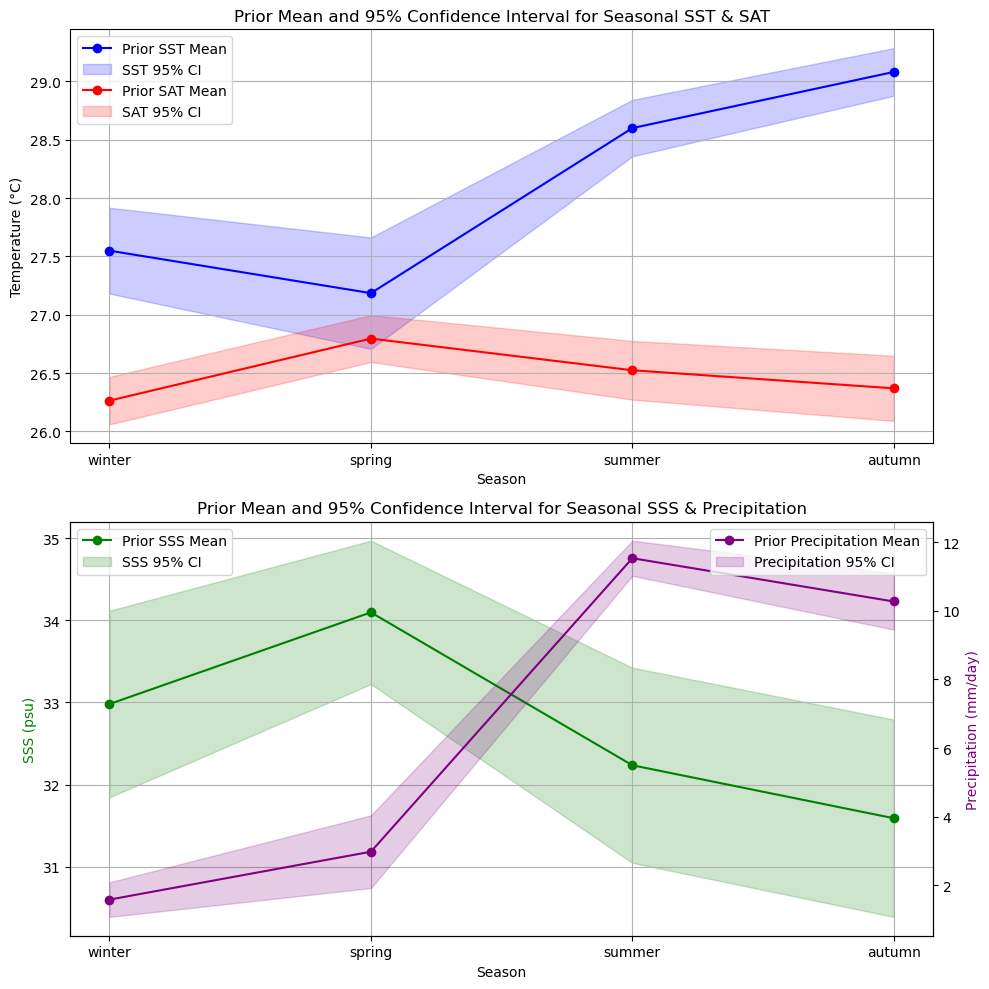

In [20]:
# Define the seasons, number of models, and scale for the x-axis
seasons = ["winter", "spring", "summer", "autumn"]
n_gridcells_seasonal = len(IPCC_Atlas["lat"])  # Find the total number of models
seasons_scale = np.arange(len(seasons)) + 1  # Create seasonal scale

# Create a 1x2 plotting grid
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel 1: Plot the prior distribution for SST and SAT
axes[0].plot(seasons_scale, mu_prior_SST_seasonal, label='Prior SST Mean', marker='o', color='b')
axes[0].fill_between(
    seasons_scale,
    mu_prior_SST_seasonal - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SST_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_SST_seasonal + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SST_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='b', label='SST 95% CI'
)
axes[0].plot(seasons_scale, mu_prior_SAT_seasonal, label='Prior SAT Mean', marker='o', color='r')
axes[0].fill_between(
    seasons_scale,
    mu_prior_SAT_seasonal - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SAT_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_SAT_seasonal + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SAT_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='r', label='SAT 95% CI'
)
axes[0].set_title('Prior Mean and 95% Confidence Interval for Seasonal SST & SAT')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_xticks(seasons_scale)
axes[0].set_xticklabels(seasons)
axes[0].legend()
axes[0].grid(True)

# Panel 2: Plot the prior distribution for SSS and precipitation
axes[1].plot(seasons_scale, mu_prior_SSS_seasonal, label='Prior SSS Mean', marker='o', color='g')
ax2 = axes[1].twinx()  # Create a secondary y-axis for precipitation
ax2.plot(seasons_scale, mu_prior_precip_seasonal, label='Prior Precipitation Mean', marker='o', color='purple')

# Add 95% confidence intervals for SSS
axes[1].fill_between(
    seasons_scale,
    mu_prior_SSS_seasonal - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SSS_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_SSS_seasonal + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SSS_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='g', label='SSS 95% CI'
)

# Add 95% confidence intervals for precipitation
ax2.fill_between(
    seasons_scale,
    mu_prior_precip_seasonal - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_precip_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_precip_seasonal + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_precip_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='purple', label='Precipitation 95% CI'
)

axes[1].set_title('Prior Mean and 95% Confidence Interval for Seasonal SSS & Precipitation')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('SSS (psu)', color='g')
ax2.set_ylabel('Precipitation (mm/day)', color='purple')
axes[1].set_xticks(seasons_scale)
axes[1].set_xticklabels(seasons)
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Calculate the seasonal prior for model SST and SAT-derived D47 values with propagated uncertainty

In [21]:
# Set the weights of the data based on the standard errors
weights_seasonal_SST_D47 = 1 / IPCC_Atlas_seasonal[[f"{season}_SST_D47_SE" for season in seasons]] ** 2
weights_seasonal_SAT_D47 = 1 / IPCC_Atlas_seasonal[[f"{season}_SAT_D47_SE" for season in seasons]] ** 2

# Change the column suffixes from "_D47_SE" to "_D47" in weights_seasonal to match the headers of the D47 matrix later for multiplication
weights_seasonal_SST_D47.columns = [col.replace('_SST_D47_SE', '_SST_D47') for col in weights_seasonal_SST_D47.columns]
weights_seasonal_SAT_D47.columns = [col.replace('_SAT_D47_SE', '_SAT_D47') for col in weights_seasonal_SAT_D47.columns]

# Prior D47 estimates from climate models (weighted mean)
mu_prior_SST_D47_seasonal = np.array((IPCC_Atlas_seasonal[[f"{season}_SST_D47" for season in seasons]] * weights_seasonal_SST_D47).sum(axis = 0, skipna = True) / weights_seasonal_SST_D47.sum(axis = 0, skipna = True)) # Calculate weighted seasonal mean D47 values and convert to numpy array
mu_prior_SAT_D47_seasonal = np.array((IPCC_Atlas_seasonal[[f"{season}_SAT_D47" for season in seasons]] * weights_seasonal_SAT_D47).sum(axis = 0, skipna = True) / weights_seasonal_SAT_D47.sum(axis = 0, skipna = True)) # Calculate weighted seasonal mean D47 values and convert to numpy array

# Calculate simple (unweighted) mean for monthly d18Oc values
mu_prior_d18Oc_seasonal = np.array(IPCC_Atlas_seasonal[[f"{season}_d18Oc" for season in seasons]].mean(axis=0, skipna=True))
mu_prior_precip_seasonal = np.array(IPCC_Atlas_seasonal[[f"{season}_precip" for season in seasons]].mean(axis=0, skipna=True))

# Decompose variance within and between model outcomes
model_variances_SST_D47 = IPCC_Atlas_seasonal[[f"{season}_SST_D47" for season in seasons]].var(axis = 0, ddof = 1)  # Compute variance across models
model_variances_SAT_D47 = IPCC_Atlas_seasonal[[f"{season}_SAT_D47" for season in seasons]].var(axis = 0, ddof = 1)  # Compute variance across models
measurement_variances_SST_D47 = (IPCC_Atlas_seasonal[[f"{season}_SST_D47_SE" for season in seasons]] ** 2).mean(axis = 0, skipna = True)  # Compute variance on measurements
measurement_variances_SAT_D47 = (IPCC_Atlas_seasonal[[f"{season}_SAT_D47_SE" for season in seasons]] ** 2).mean(axis = 0, skipna = True)  # Compute variance on measurements

# Covariance between seasons in prior D47 estimates from climate models (weighted covariance matrix)
cov_raw_seasonal_SST_D47 = np.cov(IPCC_Atlas_seasonal[[f"{season}_SST_D47" for season in seasons]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_raw_seasonal_SAT_D47 = np.cov(IPCC_Atlas_seasonal[[f"{season}_SAT_D47" for season in seasons]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_raw_seasonal_d18Oc = np.cov(IPCC_Atlas_seasonal[[f"{season}_d18Oc" for season in seasons]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_raw_seasonal_precip = np.cov(IPCC_Atlas_seasonal[[f"{season}_precip" for season in seasons]].dropna(), rowvar = False)  # Compute the covariance matrix for the raw data (without measurement uncertainty)
cov_prior_SST_D47_seasonal = cov_raw_seasonal_SST_D47.copy()  # Copy covariance matrix to add uncertainty coming from the measurements
cov_prior_SAT_D47_seasonal = cov_raw_seasonal_SAT_D47.copy()  # Copy covariance matrix to add uncertainty coming from the measurements
cov_prior_d18Oc_seasonal = cov_raw_seasonal_d18Oc.copy()  # Copy covariance matrix to add uncertainty coming from the measurements
cov_prior_precip_seasonal = cov_raw_seasonal_precip.copy()  # Copy covariance matrix to add uncertainty coming from the measurements
np.fill_diagonal(cov_prior_SST_D47_seasonal, np.diagonal(cov_raw_seasonal_SST_D47) + measurement_variances_SST_D47)  # Add diagonal terms for measurement uncertainties (which have no covariance between models)
np.fill_diagonal(cov_prior_SAT_D47_seasonal, np.diagonal(cov_raw_seasonal_SAT_D47) + measurement_variances_SAT_D47)  # Add diagonal terms for measurement uncertainties (which have no covariance between models)

# Store copy of original prior means to keep when later updating the prior
mu_prior_SST_D47_seasonal_original, cov_prior_SST_D47_seasonal_original = mu_prior_SST_D47_seasonal.copy(), cov_prior_SST_D47_seasonal.copy()
mu_prior_SAT_D47_seasonal_original, cov_prior_SAT_D47_seasonal_original = mu_prior_SAT_D47_seasonal.copy(), cov_prior_SAT_D47_seasonal.copy()
mu_prior_d18Oc_seasonal_original, cov_prior_d18Oc_seasonal_original = mu_prior_d18Oc_seasonal.copy(), cov_raw_seasonal_d18Oc.copy()
mu_prior_precip_seasonal_original, cov_prior_precip_seasonal_original = mu_prior_precip_seasonal.copy(), cov_raw_seasonal_precip.copy()

# Extract the standard deviations (uncertainty) from the covariance matrix
std_prior_SST_D47_seasonal = np.sqrt(np.diag(cov_prior_SST_D47_seasonal))
std_prior_SAT_D47_seasonal = np.sqrt(np.diag(cov_prior_SAT_D47_seasonal))
std_prior_d18Oc_seasonal = np.sqrt(np.diag(cov_prior_d18Oc_seasonal))
std_prior_precip_seasonal = np.sqrt(np.diag(cov_prior_precip_seasonal))

print("mu_prior_SST_D47_seasonal:", mu_prior_SST_D47_seasonal)
print("std_prior_SST_D47_seasonal:", std_prior_SST_D47_seasonal)
print("mu_prior_SAT_D47_seasonal:", mu_prior_SAT_D47_seasonal)
print("std_prior_SAT_D47_seasonal:", std_prior_SAT_D47_seasonal)
print("mu_prior_d18Oc_seasonal:", mu_prior_d18Oc_seasonal)
print("std_prior_d18Oc_seasonal:", std_prior_d18Oc_seasonal)
print("mu_prior_precip_seasonal:", mu_prior_precip_seasonal)
print("std_prior_precip_seasonal:", std_prior_precip_seasonal)

mu_prior_SST_D47_seasonal: [0.58581025 0.58687706 0.58274323 0.58134767]
std_prior_SST_D47_seasonal: [0.00277616 0.00351338 0.00197095 0.00174785]
mu_prior_SAT_D47_seasonal: [0.58961097 0.58803244 0.58883642 0.58929545]
std_prior_SAT_D47_seasonal: [0.00178228 0.00175895 0.00205975 0.00223382]
mu_prior_d18Oc_seasonal: [-2.05926297 -1.77569652 -2.48786265 -2.74257046]
std_prior_d18Oc_seasonal: [0.66384694 0.44756316 0.64969896 0.63483524]
mu_prior_precip_seasonal: [ 1.5836546   2.97928946 11.53320424 10.27162417]
std_prior_precip_seasonal: [1.19706106 2.51465787 1.21440914 1.94491224]


## Plot the seasonal prior for model SST- and SAT-derived D47 values, d18Oc values and precipitation with propagated uncertainty

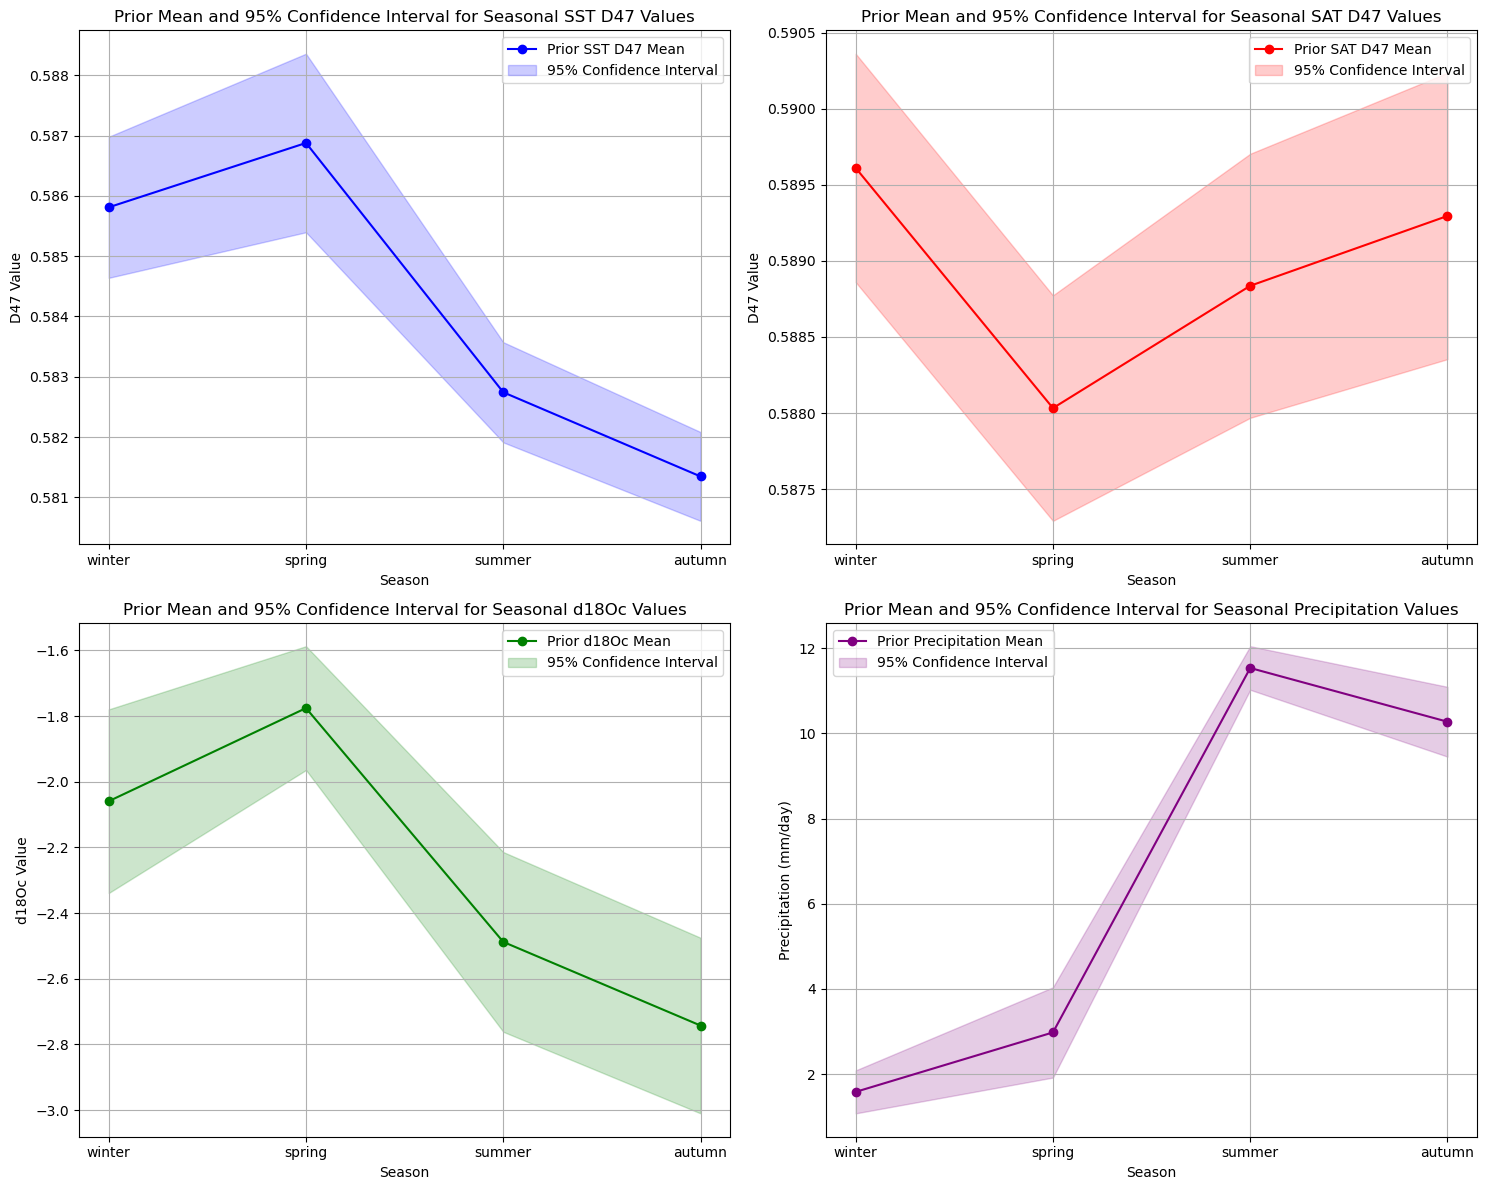

In [22]:
# Define the seasons, number of models, and scale for the x-axis
seasons = ["winter", "spring", "summer", "autumn"]
n_gridcells_seasonal = len(IPCC_Atlas["lat"])  # Find the total number of models (use monthly data because seasonal data has this column duplicated 3 times)
seasons_scale = np.arange(len(seasons)) + 1  # Create seasonal scale

# Create a 2x2 plotting grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Panel 1: Plot the prior distribution for SST D47 values
axes[0, 0].plot(seasons_scale, mu_prior_SST_D47_seasonal[:len(seasons)], label='Prior SST D47 Mean', marker='o', color='b')
axes[0, 0].fill_between(
    seasons_scale,
    mu_prior_SST_D47_seasonal[:len(seasons)] - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SST_D47_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_SST_D47_seasonal[:len(seasons)] + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SST_D47_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='b', label='95% Confidence Interval'
)
axes[0, 0].set_title('Prior Mean and 95% Confidence Interval for Seasonal SST D47 Values')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('D47 Value')
axes[0, 0].set_xticks(seasons_scale)
axes[0, 0].set_xticklabels(seasons)
axes[0, 0].legend()
axes[0, 0].grid(True)

# Panel 2: Plot the prior distribution for SAT D47 values
axes[0, 1].plot(seasons_scale, mu_prior_SAT_D47_seasonal[:len(seasons)], label='Prior SAT D47 Mean', marker='o', color='r')
axes[0, 1].fill_between(
    seasons_scale,
    mu_prior_SAT_D47_seasonal[:len(seasons)] - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SAT_D47_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_SAT_D47_seasonal[:len(seasons)] + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_SAT_D47_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='r', label='95% Confidence Interval'
)
axes[0, 1].set_title('Prior Mean and 95% Confidence Interval for Seasonal SAT D47 Values')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('D47 Value')
axes[0, 1].set_xticks(seasons_scale)
axes[0, 1].set_xticklabels(seasons)
axes[0, 1].legend()
axes[0, 1].grid(True)

# Panel 3: Plot the prior distribution for d18Oc
axes[1, 0].plot(seasons_scale, mu_prior_d18Oc_seasonal, label='Prior d18Oc Mean', marker='o', color='g')
axes[1, 0].fill_between(
    seasons_scale,
    mu_prior_d18Oc_seasonal - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_d18Oc_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_d18Oc_seasonal + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_d18Oc_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='g', label='95% Confidence Interval'
)
axes[1, 0].set_title('Prior Mean and 95% Confidence Interval for Seasonal d18Oc Values')
axes[1, 0].set_xlabel('Season')
axes[1, 0].set_ylabel('d18Oc Value')
axes[1, 0].set_xticks(seasons_scale)
axes[1, 0].set_xticklabels(seasons)
axes[1, 0].legend()
axes[1, 0].grid(True)

# Panel 4: Plot the prior distribution for precipitation
axes[1, 1].plot(seasons_scale, mu_prior_precip_seasonal, label='Prior Precipitation Mean', marker='o', color='purple')
axes[1, 1].fill_between(
    seasons_scale,
    mu_prior_precip_seasonal - stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_precip_seasonal / np.sqrt(n_gridcells_seasonal),
    mu_prior_precip_seasonal + stats.t.ppf(1 - 0.025, n_gridcells_seasonal) * std_prior_precip_seasonal / np.sqrt(n_gridcells_seasonal),
    alpha=0.2, color='purple', label='95% Confidence Interval'
)
axes[1, 1].set_title('Prior Mean and 95% Confidence Interval for Seasonal Precipitation Values')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Precipitation (mm/day)')
axes[1, 1].set_xticks(seasons_scale)
axes[1, 1].set_xticklabels(seasons)
axes[1, 1].legend()
axes[1, 1].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Calculate the seasonal covariance matrix for D47 values derived from SST and SAT values, d18Oc and precipitation

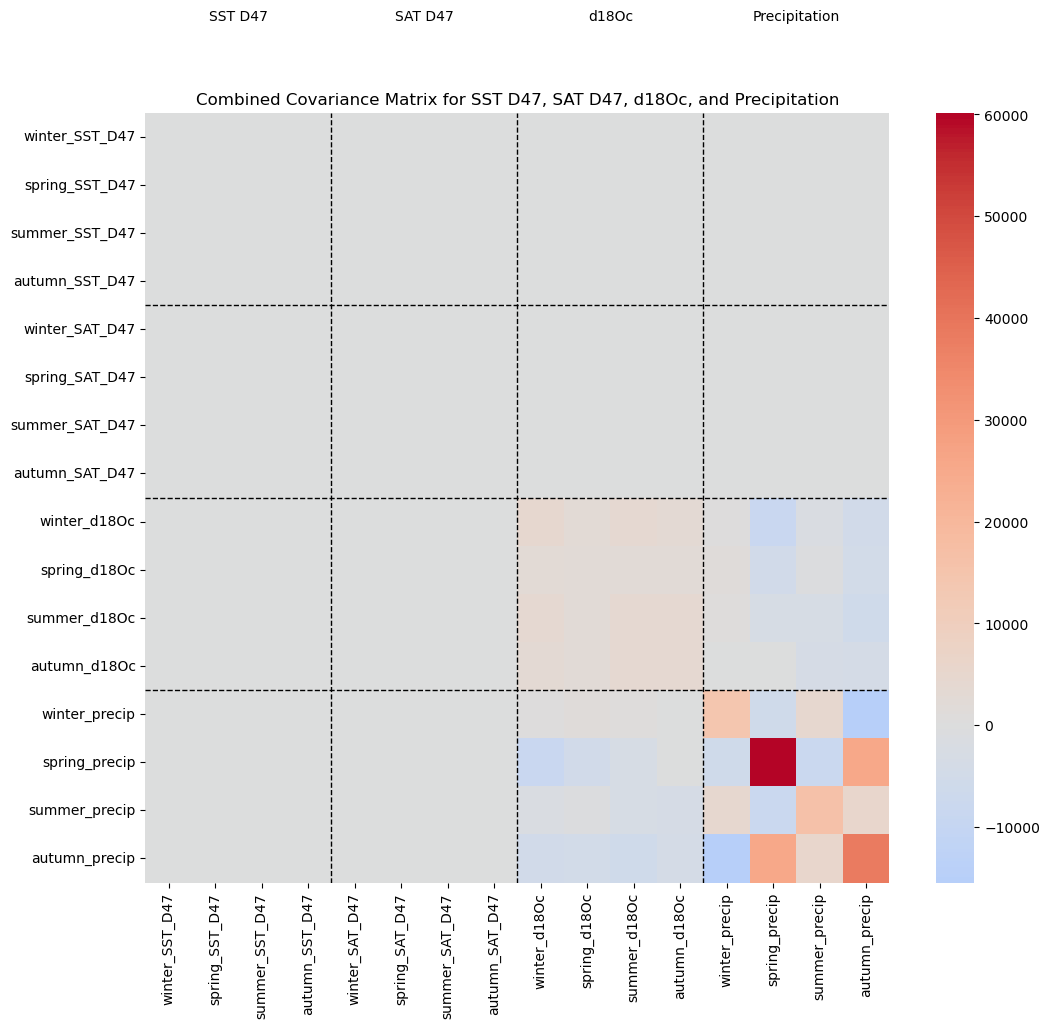

In [23]:
# Extract the relevant columns for SST, SAT D47, d18Oc, and precipitation
SST_D47_columns_seasonal = [f"{season}_SST_D47" for season in seasons]
SAT_D47_columns_seasonal = [f"{season}_SAT_D47" for season in seasons]
d18Oc_columns_seasonal = [f"{season}_d18Oc" for season in seasons]
precip_columns_seasonal = [f"{season}_precip" for season in seasons]

# Combine the relevant columns into a single dataframe
combined_data_seasonal = IPCC_Atlas_seasonal[
    SST_D47_columns_seasonal + SAT_D47_columns_seasonal + d18Oc_columns_seasonal + precip_columns_seasonal
]

# Calculate the covariance matrix for the combined data
cov_combined_seasonal = np.cov(combined_data_seasonal.dropna(), rowvar=False)

# Extract the covariance matrices for each variable
cov_SST_D47_seasonal = cov_combined_seasonal[:len(seasons), :len(seasons)]
cov_SAT_D47_seasonal = cov_combined_seasonal[len(seasons):2*len(seasons), len(seasons):2*len(seasons)]
cov_d18Oc_seasonal = cov_combined_seasonal[2*len(seasons):3*len(seasons), 2*len(seasons):3*len(seasons)]
cov_precip_seasonal = cov_combined_seasonal[3*len(seasons):, 3*len(seasons):]

# Extract the cross-covariance matrices
cross_cov_SST_SAT_D47_seasonal = cov_combined_seasonal[:len(seasons), len(seasons):2*len(seasons)]
cross_cov_SST_d18Oc_seasonal = cov_combined_seasonal[:len(seasons), 2*len(seasons):3*len(seasons)]
cross_cov_SST_precip_seasonal = cov_combined_seasonal[:len(seasons), 3*len(seasons):]
cross_cov_SAT_d18Oc_seasonal = cov_combined_seasonal[len(seasons):2*len(seasons), 2*len(seasons):3*len(seasons)]
cross_cov_SAT_precip_seasonal = cov_combined_seasonal[len(seasons):2*len(seasons), 3*len(seasons):]
cross_cov_d18Oc_precip_seasonal = cov_combined_seasonal[2*len(seasons):3*len(seasons), 3*len(seasons):]

# Plot a heatmap of the combined covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    np.round(cov_combined_seasonal * 10**4, 1),  # Scale by 10^4 for better visualization and round values
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=SST_D47_columns_seasonal + SAT_D47_columns_seasonal + d18Oc_columns_seasonal + precip_columns_seasonal,
    yticklabels=SST_D47_columns_seasonal + SAT_D47_columns_seasonal + d18Oc_columns_seasonal + precip_columns_seasonal
)

# Add titles to the axes per parameter
plt.axvline(x=len(SST_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SST_D47_columns_seasonal) + len(SAT_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SST_D47_columns_seasonal) + len(SAT_D47_columns_seasonal) + len(d18Oc_columns_seasonal), color='black', linestyle='--', linewidth=1)

plt.axhline(y=len(SST_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SST_D47_columns_seasonal) + len(SAT_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SST_D47_columns_seasonal) + len(SAT_D47_columns_seasonal) + len(d18Oc_columns_seasonal), color='black', linestyle='--', linewidth=1)

# Add parameter labels
plt.text(len(SST_D47_columns_seasonal) / 2, -2, 'SST D47', ha='center', va='center', fontsize=10)
plt.text(len(SST_D47_columns_seasonal) + len(SAT_D47_columns_seasonal) / 2, -2, 'SAT D47', ha='center', va='center', fontsize=10)
plt.text(len(SST_D47_columns_seasonal) + len(SAT_D47_columns_seasonal) + len(d18Oc_columns_seasonal) / 2, -2, 'd18Oc', ha='center', va='center', fontsize=10)
plt.text(len(SST_D47_columns_seasonal) + len(SAT_D47_columns_seasonal) + len(d18Oc_columns_seasonal) + len(precip_columns_seasonal) / 2, -2, 'Precipitation', ha='center', va='center', fontsize=10)

plt.title("Combined Covariance Matrix for SST D47, SAT D47, d18Oc, and Precipitation")
plt.show()

## Plot normalized seasonal covariance matrix between D47 values of SST and SAT, d18Oc and precipitation

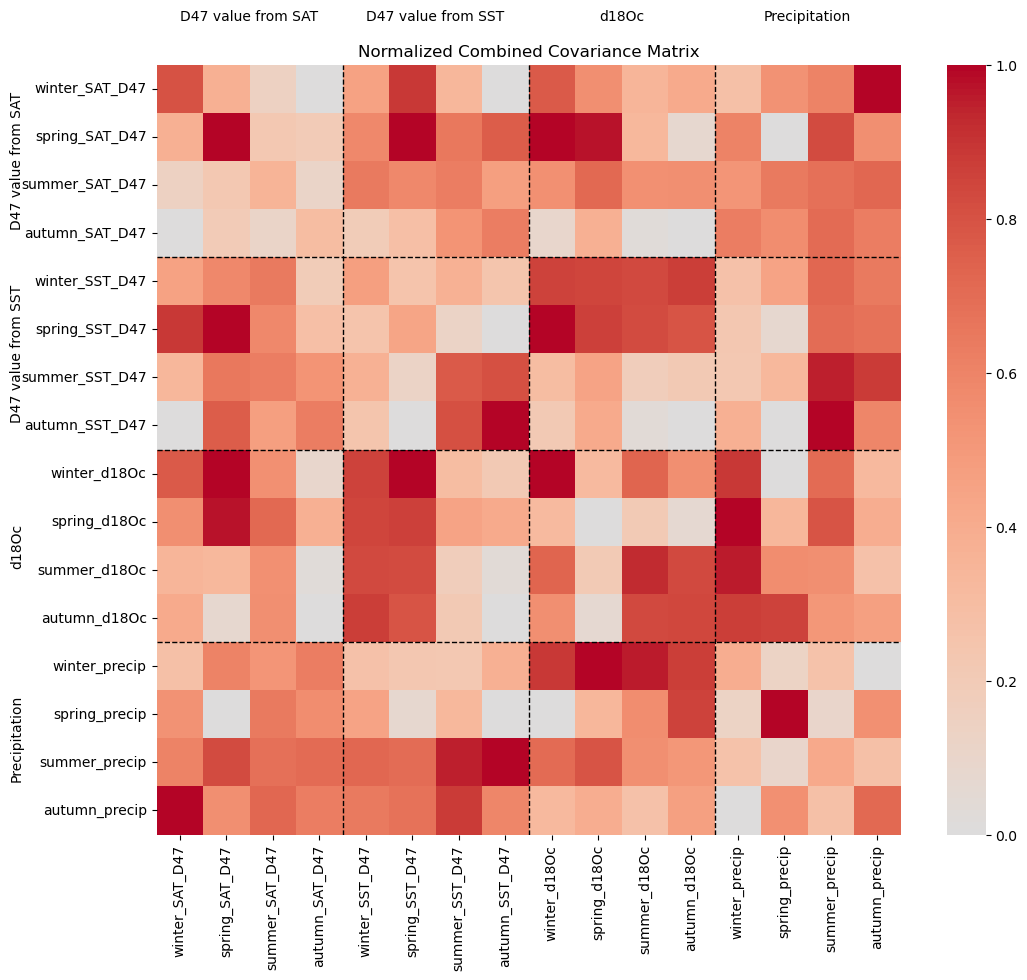

In [24]:
# Normalize each submatrix independently for better visualization
def normalize_matrix(matrix):
    min_val = np.min(matrix)
    max_val = np.max(matrix)
    return (matrix - min_val) / (max_val - min_val)

# Extract the covariance matrices for SAT D47, SST D47, d18Oc, and precipitation
cov_SAT_D47_seasonal = cov_combined_seasonal[:len(seasons), :len(seasons)]
cov_SST_D47_seasonal = cov_combined_seasonal[len(seasons):2*len(seasons), len(seasons):2*len(seasons)]
cov_d18Oc_seasonal = cov_combined_seasonal[2*len(seasons):3*len(seasons), 2*len(seasons):3*len(seasons)]
cov_precip_seasonal = cov_combined_seasonal[3*len(seasons):, 3*len(seasons):]

# Extract the cross-covariance matrices
cross_cov_SAT_SST_D47_seasonal = cov_combined_seasonal[:len(seasons), len(seasons):2*len(seasons)]
cross_cov_SAT_d18Oc_seasonal = cov_combined_seasonal[:len(seasons), 2*len(seasons):3*len(seasons)]
cross_cov_SAT_precip_seasonal = cov_combined_seasonal[:len(seasons), 3*len(seasons):]
cross_cov_SST_d18Oc_seasonal = cov_combined_seasonal[len(seasons):2*len(seasons), 2*len(seasons):3*len(seasons)]
cross_cov_SST_precip_seasonal = cov_combined_seasonal[len(seasons):2*len(seasons), 3*len(seasons):]
cross_cov_d18Oc_precip_seasonal = cov_combined_seasonal[2*len(seasons):3*len(seasons), 3*len(seasons):]

# Normalize each submatrix
normalized_cov_SAT_D47_seasonal = normalize_matrix(cov_SAT_D47_seasonal)
normalized_cov_SST_D47_seasonal = normalize_matrix(cov_SST_D47_seasonal)
normalized_cov_d18Oc_seasonal = normalize_matrix(cov_d18Oc_seasonal)
normalized_cov_precip_seasonal = normalize_matrix(cov_precip_seasonal)

# Normalize each cross-covariance matrix
normalized_cross_cov_SAT_SST_D47_seasonal = normalize_matrix(cross_cov_SAT_SST_D47_seasonal)
normalized_cross_cov_SAT_d18Oc_seasonal = normalize_matrix(cross_cov_SAT_d18Oc_seasonal)
normalized_cross_cov_SAT_precip_seasonal = normalize_matrix(cross_cov_SAT_precip_seasonal)
normalized_cross_cov_SST_d18Oc_seasonal = normalize_matrix(cross_cov_SST_d18Oc_seasonal)
normalized_cross_cov_SST_precip_seasonal = normalize_matrix(cross_cov_SST_precip_seasonal)
normalized_cross_cov_d18Oc_precip_seasonal = normalize_matrix(cross_cov_d18Oc_precip_seasonal)

# Combine the normalized submatrices into a single normalized covariance matrix
normalized_cov_combined_seasonal = np.block([
    [normalized_cov_SAT_D47_seasonal, normalized_cross_cov_SAT_SST_D47_seasonal, normalized_cross_cov_SAT_d18Oc_seasonal, normalized_cross_cov_SAT_precip_seasonal],
    [normalized_cross_cov_SAT_SST_D47_seasonal.T, normalized_cov_SST_D47_seasonal, normalized_cross_cov_SST_d18Oc_seasonal, normalized_cross_cov_SST_precip_seasonal],
    [normalized_cross_cov_SAT_d18Oc_seasonal.T, normalized_cross_cov_SST_d18Oc_seasonal.T, normalized_cov_d18Oc_seasonal, normalized_cross_cov_d18Oc_precip_seasonal],
    [normalized_cross_cov_SAT_precip_seasonal.T, normalized_cross_cov_SST_precip_seasonal.T, normalized_cross_cov_d18Oc_precip_seasonal.T, normalized_cov_precip_seasonal]
])

# Plot the heatmap of the normalized combined covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    normalized_cov_combined_seasonal,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=SAT_D47_columns_seasonal + SST_D47_columns_seasonal + d18Oc_columns_seasonal + precip_columns_seasonal,
    yticklabels=SAT_D47_columns_seasonal + SST_D47_columns_seasonal + d18Oc_columns_seasonal + precip_columns_seasonal
)

# Add titles to the axes per parameter
plt.axvline(x=len(SAT_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axvline(x=len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) + len(d18Oc_columns_seasonal), color='black', linestyle='--', linewidth=1)

plt.axhline(y=len(SAT_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal), color='black', linestyle='--', linewidth=1)
plt.axhline(y=len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) + len(d18Oc_columns_seasonal), color='black', linestyle='--', linewidth=1)

# Add parameter labels
plt.text(len(SAT_D47_columns_seasonal) / 2, -1, 'D47 value from SAT', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) / 2, -1, 'D47 value from SST', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) + len(d18Oc_columns_seasonal) / 2, -1, 'd18Oc', ha='center', va='center', fontsize=10)
plt.text(len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) + len(d18Oc_columns_seasonal) + len(precip_columns_seasonal) / 2, -1, 'Precipitation', ha='center', va='center', fontsize=10)

plt.text(-3, len(SAT_D47_columns_seasonal) / 2, 'D47 value from SAT', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-3, len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) / 2, 'D47 value from SST', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-3, len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) + len(d18Oc_columns_seasonal) / 2, 'd18Oc', ha='center', va='center', rotation=90, fontsize=10)
plt.text(-3, len(SAT_D47_columns_seasonal) + len(SST_D47_columns_seasonal) + len(d18Oc_columns_seasonal) + len(precip_columns_seasonal) / 2, 'Precipitation', ha='center', va='center', rotation=90, fontsize=10)

plt.title("Normalized Combined Covariance Matrix")
plt.show()

## Create combined seasonal state vector

In [25]:
# Combine the prior means of D47 and SAT into a single state vector
mu_prior_seasonal_combined = np.concatenate((mu_prior_SST_D47_seasonal, mu_prior_SAT_D47_seasonal, mu_prior_d18Oc_seasonal, mu_prior_precip_seasonal))

# Combine the covariance matrices of D47 values of SST and SAT, d18Oc and precipitation including the cross-covariance
cov_prior_seasonal_combined = cov_combined_seasonal.copy()

# OBSERVATIONS
## Load clumped data for updating

### Monthly and seasonal data based on age model

In [26]:
# Load measurements and format them into a dictionary
# These are the actual individual D47 measurements and ShellChron outcomes and thus come with a time uncertainty which can be propagated.
Caldarescu_data = pd.read_csv('Modern case/Caldarescu_data.csv') # Load the data into Python and in the Jupyter environment.
Caldarescu_data_dict = Caldarescu_data.to_dict('records') # Convert to dictionary with column headers as keys

# Convert estimated day of year to month (0-11) and season (0-3), set errors to 0
for record in Caldarescu_data_dict:
    doy = record.get("Estimated day of year", np.nan)
    if not pd.isna(doy):
        record["month_score"] = int(doy / 365 * 12) % 12  # month index 0-11
        record["season_score"] = int(doy / 365 * 4) % 4    # season index 0-3
    else:
        record["month_score"] = np.nan
        record["season_score"] = np.nan
    record["Month_err"] = 0
    record["Season_err"] = 0

# Print excerpt of the dictionary to check format
print(Caldarescu_data_dict[1])

{'SampName': 'M5_115', 'Specimen': 'M5', 'SampNum': 115, 'Time of year': 'Apr/Oct', 'Increment number': 2, 'Estimated date': '01/10/2005', 'Estimated day of year': 273.0, 'Final_d13Ccarb': -0.01, 'd13C_SD': 0.030214895, 'Final_d18Ocarb_VPDB': -4.32, 'd18O_SD': 0.059240652, 'D47rfac': 0.644, 'D47': 0.582, 'D47_SD': 0.039056165, 'month_score': 8, 'season_score': 2, 'Month_err': 0, 'Season_err': 0}


### Monthly and seasonal data based on age model with 1-month (1/3-season) age uncertainty

In [27]:
# Format measurements and into a dictionary including artificial 1-month uncertainty on dating
Caldarescu_data_dict_timeSD = Caldarescu_data.to_dict('records') # Convert to dictionary with column headers as keys

# Convert estimated day of year to month (0-11) and season (0-3), set errors to 0
for record in Caldarescu_data_dict_timeSD:
    doy = record.get("Estimated day of year", np.nan)
    if not pd.isna(doy):
        record["month_score"] = int(doy / 365 * 12) % 12  # month index 0-11
        record["season_score"] = int(doy / 365 * 4) % 4    # season index 0-3
    else:
        record["month_score"] = np.nan
        record["season_score"] = np.nan
    record["Month_err"] = 1 # Set 1 month uncertainty on dating
    record["Season_err"] = 1/3 # Set 1/3 season uncertainty on dating

# Print excerpt of the dictionary to check format
print(Caldarescu_data_dict_timeSD[1])

{'SampName': 'M5_115', 'Specimen': 'M5', 'SampNum': 115, 'Time of year': 'Apr/Oct', 'Increment number': 2, 'Estimated date': '01/10/2005', 'Estimated day of year': 273.0, 'Final_d13Ccarb': -0.01, 'd13C_SD': 0.030214895, 'Final_d18Ocarb_VPDB': -4.32, 'd18O_SD': 0.059240652, 'D47rfac': 0.644, 'D47': 0.582, 'D47_SD': 0.039056165, 'month_score': 8, 'season_score': 2, 'Month_err': 1, 'Season_err': 0.3333333333333333}


## Prepare measurement and observation matrices

## Observations parsed as individual values

### Measurement matrix for individual D47 values

In [28]:
# Extract measurements and uncertainties from the dictionary, skipping missing values
D47_measurements_individual = [measurement["D47"] for measurement in Caldarescu_data_dict if not pd.isna(measurement["D47"])] # Extract the D47 values
d18Oc_measurements_individual = [measurement["Final_d18Ocarb_VPDB"] for measurement in Caldarescu_data_dict if not pd.isna(measurement["Final_d18Ocarb_VPDB"])] # Extract the d18Oc values
D47_measurement_uncertainties_individual = [measurement["D47_SD"] ** 2 for measurement in Caldarescu_data_dict if not pd.isna(measurement["D47"])] # Square the standard deviation to get the variance
d18Oc_measurement_uncertainties_individual = [measurement["d18O_SD"] ** 2 for measurement in Caldarescu_data_dict if not pd.isna(measurement["Final_d18Ocarb_VPDB"])] # Square the standard deviation to get the variance

# Create the measurement matrix Z
Z_individual = np.array(D47_measurements_individual + d18Oc_measurements_individual).reshape(-1, 1)

# Create the measurement uncertainty matrix R (diagonal matrix)
R_individual = np.diag(D47_measurement_uncertainties_individual + d18Oc_measurement_uncertainties_individual) # Diagonal matrix of measurement uncertainties

## Observations on seasonal scale

### Observation matrix for seasonal D47 and d18Oc data from individual D47 and d18Oc values

In [29]:
# Create the observation matrix H for seasonal data based on individual measurements
N_measurements = len(Z_individual)

# Number of seasonally averaged measurements
H_seasonal = np.zeros((N_measurements, len(mu_prior_seasonal_combined)))

# Fill the first part of the observation matrix H with ones at the positions corresponding to the D47 measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict if not pd.isna(m["D47"])]):
    time_index = int(measurement["season_score"])
    H_seasonal[i, time_index] = 1  # Indexing the first set of columns (1:4) for SST_D47

# Fill the second part of the observation matrix H with ones at the positions corresponding to the d18Oc measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict if not pd.isna(m["Final_d18Ocarb_VPDB"])]):
    time_index = int(measurement["season_score"])
    H_seasonal[i + len(D47_measurements_individual), time_index + 8] = 1  # Indexing the third column block (8:12) for d18Oc

print(H_seasonal)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Define a wrapped normal distribution to allow uncertainty in the time domain to flow around the year

In [30]:
# Function to calculate wrapped normal distribution weights
def wrapped_normal_pdf(x, mean, sd, num_bins):
    # Calculate the normal PDF for each bin
    pdf = stats.norm.pdf(x, loc = mean, scale = sd)
    # Wrap around the bins
    for i in range(1, num_bins):
        pdf += stats.norm.pdf(x + i * num_bins, loc = mean, scale = sd)
        pdf += stats.norm.pdf(x - i * num_bins, loc = mean, scale = sd)
    # Normalize the weights to ensure the sum equals 1
    pdf /= pdf.sum()
    return pdf

### Observation matrix for monthly D47 data from individual D47 values with time uncertainty

In [31]:
# Define the number of seasons or months
num_seasons = 4

# Number of seasonally averaged measurements
H_seasonal_timeSD = np.zeros((N_measurements, len(mu_prior_seasonal_combined)))

# Fill the first part of the observation matrix H with ones at the positions corresponding to the D47 measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict_timeSD if not pd.isna(m["D47"])]):
    time_index = int(measurement["season_score"])
    time_sd = measurement["Season_err"]
    if time_sd == 0: # If the uncertainty is zero, set the value in H to 1 for the assigned season
            H_seasonal_timeSD[i, time_index] = 1
    else:
        # Calculate the weights for each season based on the normal distribution
        weights = wrapped_normal_pdf(np.arange(num_seasons), mean = time_index, sd = time_sd, num_bins = num_seasons)
        weights /= weights.sum()  # Normalize the weights
        weights = np.concatenate((weights, np.zeros(3 * num_seasons)))  # Concatenate the weights with zeros for the SAT, SSS and precip values (first block of 12 columns for D47)
        H_seasonal_timeSD[i, :] = weights
    i = i + 1 # Increment number of stored values

# Fill the second part of the observation matrix H with ones at the positions corresponding to the d18Oc measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict_timeSD if not pd.isna(m["Final_d18Ocarb_VPDB"])]):
    time_index = int(measurement["season_score"])
    time_sd = measurement["Season_err"]
    if time_sd == 0: # If the uncertainty is zero, set the value in H to 1 for the assigned season
            H_seasonal_timeSD[i + len(D47_measurements_individual), time_index + 24] = 1
    else:
        # Calculate the weights for each season based on the normal distribution
        weights = wrapped_normal_pdf(np.arange(num_seasons), mean = time_index, sd = time_sd, num_bins = num_seasons)
        weights /= weights.sum()  # Normalize the weights
        weights = np.concatenate((np.zeros(2 *num_seasons), weights, np.zeros(num_seasons)))  # Concatenate the weights with zeros for the first two blocks (SST-D47 + D47) and the last block (precipitation) (second block of 12 columns for d18Oc)
        H_seasonal_timeSD[i + len(D47_measurements_individual), :] = weights
    i = i + 1 # Increment number of stored values

# Print the observation matrix H with 3 decimal places
np.set_printoptions(precision = 3, suppress = True)
print(H_seasonal_timeSD)

[[0.    0.011 0.978 ... 0.    0.    0.   ]
 [0.    0.011 0.978 ... 0.    0.    0.   ]
 [0.    0.011 0.978 ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]]


### Measurement matrix for seasonally aggregated D47 values

In [32]:
# Define the list of season names for integer indexing
season_names = ["winter", "spring", "summer", "autumn"]

# Initialize dictionaries to store aggregated measurements and uncertainties per season
D47_measurements_seasonal = {season: [] for season in season_names}
d18Oc_measurements_seasonal = {season: [] for season in season_names}
D47_measurement_uncertainties_seasonal = {season: [] for season in season_names}
d18Oc_measurement_uncertainties_seasonal = {season: [] for season in season_names}
print(D47_measurements_seasonal)

for measurement in Caldarescu_data_dict:
    if not pd.isna(measurement["D47"]):
        season_index = int(measurement["season_score"])
        D47_measurements_seasonal[season_names[season_index]].append(measurement["D47"])
        D47_measurement_uncertainties_seasonal[season_names[season_index]].append(measurement["D47_SD"] ** 2)
    if not pd.isna(measurement["Final_d18Ocarb_VPDB"]):
        season_index = int(measurement["season_score"])
        d18Oc_measurements_seasonal[season_names[season_index]].append(measurement["Final_d18Ocarb_VPDB"])
        d18Oc_measurement_uncertainties_seasonal[season_names[season_index]].append(measurement["d18O_SD"] ** 2)

# Calculate weighted mean and propagated uncertainty for each season
D47_aggregated_measurements_seasonal = []
d18Oc_aggregated_measurements_seasonal = []
D47_aggregated_uncertainties_seasonal = []
d18Oc_aggregated_uncertainties_seasonal = []

for season in season_names:
    if D47_measurements_seasonal[season]:
        weights = 1 / np.array(D47_measurement_uncertainties_seasonal[season])
        weighted_mean = np.sum(np.array(D47_measurements_seasonal[season]) * weights) / np.sum(weights)
        measurement_variance = np.var(D47_measurements_seasonal[season], ddof=1)
        propagated_uncertainty = np.sqrt(1 / np.sum(weights) + measurement_variance)
        propagated_standard_error = propagated_uncertainty / np.sqrt(len(D47_measurements_seasonal[season])) # Assemble D47 data as SE (optional)
        D47_aggregated_measurements_seasonal.append(weighted_mean)
        D47_aggregated_uncertainties_seasonal.append(propagated_uncertainty ** 2)
    if d18Oc_measurements_seasonal[season]:
        weights = 1 / np.array(d18Oc_measurement_uncertainties_seasonal[season])
        weighted_mean = np.sum(np.array(d18Oc_measurements_seasonal[season]) * weights) / np.sum(weights)
        measurement_variance = np.var(d18Oc_measurements_seasonal[season], ddof=1)
        propagated_uncertainty = np.sqrt(1 / np.sum(weights) + measurement_variance)
        d18Oc_aggregated_measurements_seasonal.append(weighted_mean)
        d18Oc_aggregated_uncertainties_seasonal.append(propagated_uncertainty ** 2)

# OPTIONAL: Lower boundary d18Oc varaince at 0.01 (equivalent to 0.1 per mil measuremetn uncertainty)
d18Oc_aggregated_uncertainties_seasonal = [max(uncertainty, 0.01) for uncertainty in d18Oc_aggregated_uncertainties_seasonal]

# Create the measurement matrix Z
Z_seasonal_aggregated = np.array(D47_aggregated_measurements_seasonal + d18Oc_aggregated_measurements_seasonal).reshape(-1, 1)

# Create the measurement uncertainty matrix R (diagonal matrix)
R_seasonal_aggregated = np.diag(D47_aggregated_uncertainties_seasonal + d18Oc_aggregated_uncertainties_seasonal)  # Diagonal matrix of measurement uncertainties

print("Z_seasonal_aggregated:", Z_seasonal_aggregated)
print("R_seasonal_aggregated:", R_seasonal_aggregated)

{'winter': [], 'spring': [], 'summer': [], 'autumn': []}
Z_seasonal_aggregated: [[ 0.62 ]
 [ 0.608]
 [ 0.589]
 [ 0.606]
 [-1.669]
 [-2.198]
 [-4.057]
 [-2.778]]
R_seasonal_aggregated: [[0.002 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.002 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.001 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.002 0.    0.    0.    0.   ]
 [0.    0.    0.    0.    1.222 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.46  0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.144 0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.742]]


### Observation matrix for seasonally aggregated D47 data

In [33]:
# Create the observation matrix H for seasonally aggregated data

# Define the number of seasons or months
num_seasons = 4

# Number of seasonally aggregated measurements
N_measurements_seasonal_aggregated = len(Z_seasonal_aggregated)
H_seasonal_aggregated = np.zeros((N_measurements_seasonal_aggregated, len(mu_prior_seasonal_combined)))

# Fill the observation matrix H with ones at the positions corresponding to the measurements
for i, measurement in enumerate(Z_seasonal_aggregated):
    if i < N_measurements_seasonal_aggregated // 2:
        time_index = i % num_seasons  # Ensure the index is within the range of seasons
        H_seasonal_aggregated[i, time_index] = 1
    else:
        time_index = i % num_seasons
        H_seasonal_aggregated[i, time_index + 8] = 1

print(H_seasonal_aggregated)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


## Observations on monthly scale

### Monthly observation matrix for individual D47 data

In [34]:
# Create the observation matrix H for monthly data based on individual measurements
H_monthly = np.zeros((N_measurements, len(mu_prior_monthly_combined)))

# Fill the first part of the observation matrix H with ones at the positions corresponding to the D47 measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict if not pd.isna(m["D47"])]):
    time_index = int(measurement["month_score"])
    H_monthly[i, time_index] = 1  # Indexing the first set of columns (1:12) for SST_D47

# Fill the second part of the observation matrix H with ones at the positions corresponding to the d18Oc measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict if not pd.isna(m["Final_d18Ocarb_VPDB"])]):
    time_index = int(measurement["month_score"])
    H_monthly[i + len(D47_measurements_individual), time_index + 24] = 1  # Indexing the third column block (25:36) for d18Oc

print(H_monthly)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Observation matrix for monthly D47 data from individual D47 values with time uncertainty

In [35]:
# Define the number of seasons or months
num_months = 12

# Number of seasonally averaged measurements
H_monthly_timeSD = np.zeros((N_measurements, len(mu_prior_monthly_combined)))

# Fill the first part of the observation matrix H with ones at the positions corresponding to the D47 measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict_timeSD if not pd.isna(m["D47"])]):
    time_index = int(measurement["month_score"])
    time_sd = measurement["Month_err"]
    if time_sd == 0: # If the uncertainty is zero, set the value in H to 1 for the assigned season
            H_monthly_timeSD[i, time_index] = 1
    else:
        # Calculate the weights for each season based on the normal distribution
        weights = wrapped_normal_pdf(np.arange(num_months), mean = time_index, sd = time_sd, num_bins = num_months)
        weights /= weights.sum()  # Normalize the weights
        weights = np.concatenate((weights, np.zeros(3 * num_months)))  # Concatenate the weights with zeros for the SAT, SSS and precip values (first block of 12 columns for D47)
        H_monthly_timeSD[i, :] = weights
    i = i + 1 # Increment number of stored values

# Fill the second part of the observation matrix H with ones at the positions corresponding to the d18Oc measurements, ignoring NaN values
for i, measurement in enumerate([m for m in Caldarescu_data_dict_timeSD if not pd.isna(m["Final_d18Ocarb_VPDB"])]):
    time_index = int(measurement["month_score"])
    time_sd = measurement["Month_err"]
    if time_sd == 0: # If the uncertainty is zero, set the value in H to 1 for the assigned season
            H_monthly_timeSD[i + len(D47_measurements_individual), time_index + 24] = 1
    else:
        # Calculate the weights for each season based on the normal distribution
        weights = wrapped_normal_pdf(np.arange(num_months), mean = time_index, sd = time_sd, num_bins = num_months)
        weights /= weights.sum()  # Normalize the weights
        weights = np.concatenate((np.zeros(2 *num_months), weights, np.zeros(num_months)))  # Concatenate the weights with zeros for the first two blocks (SST-D47 + D47) and the last block (precipitation) (second block of 12 columns for d18Oc)
        H_monthly_timeSD[i + len(D47_measurements_individual), :] = weights
    i = i + 1 # Increment number of stored values

# Print the observation matrix H with 3 decimal places
np.set_printoptions(precision = 3, suppress = True)
print(H_monthly_timeSD)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Measurement matrix for monthly aggregated D47 values

In [36]:
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']  # List full month names

# Initialize dictionaries to store aggregated measurements and uncertainties per month
D47_measurements_monthly = {month: [] for month in month_names}
d18Oc_measurements_monthly = {month: [] for month in month_names}
D47_measurement_uncertainties_monthly = {month: [] for month in month_names}
d18Oc_measurement_uncertainties_monthly = {month: [] for month in month_names}

# Aggregate measurements and uncertainties per month
for measurement in Caldarescu_data_dict:
    if not pd.isna(measurement["D47"]):
        month_index = int(measurement["month_score"])
        D47_measurements_monthly[month_names[month_index]].append(measurement["D47"])
        D47_measurement_uncertainties_monthly[month_names[month_index]].append(measurement["D47_SD"] ** 2)
    if not pd.isna(measurement["Final_d18Ocarb_VPDB"]):
        month_index = int(measurement["month_score"])
        d18Oc_measurements_monthly[month_names[month_index]].append(measurement["Final_d18Ocarb_VPDB"])
        d18Oc_measurement_uncertainties_monthly[month_names[month_index]].append(measurement["d18O_SD"] ** 2)

# Calculate weighted mean and propagated uncertainty for each month
D47_aggregated_measurements_monthly = []
d18Oc_aggregated_measurements_monthly = []
D47_aggregated_uncertainties_monthly = []
d18Oc_aggregated_uncertainties_monthly = []

for month in month_names:
    if D47_measurements_monthly[month]:
        weights = 1 / np.array(D47_measurement_uncertainties_monthly[month])
        weighted_mean = np.sum(np.array(D47_measurements_monthly[month]) * weights) / np.sum(weights)
        measurement_variance = np.var(D47_measurements_monthly[month], ddof=1)
        propagated_uncertainty = np.sqrt(1 / np.sum(weights) + measurement_variance)
        propagated_standard_error = propagated_uncertainty / np.sqrt(len(D47_measurements_monthly[month]))  # Assemble D47 data as SE (optional)
        D47_aggregated_measurements_monthly.append(weighted_mean)
        D47_aggregated_uncertainties_monthly.append(propagated_uncertainty ** 2) # Assemble D47 data as SE
    if d18Oc_measurements_monthly[month]:
        weights = 1 / np.array(d18Oc_measurement_uncertainties_monthly[month])
        weighted_mean = np.sum(np.array(d18Oc_measurements_monthly[month]) * weights) / np.sum(weights)
        measurement_variance = np.var(d18Oc_measurements_monthly[month], ddof=1)
        propagated_uncertainty = np.sqrt(1 / np.sum(weights) + measurement_variance)
        d18Oc_aggregated_measurements_monthly.append(weighted_mean)
        d18Oc_aggregated_uncertainties_monthly.append(propagated_uncertainty ** 2)

# OPTIONAL: Lower boundary d18Oc varaince at 0.01 (equivalent to 0.1 per mil measurement uncertainty)
d18Oc_aggregated_uncertainties_monthly = [max(uncertainty, 0.01) for uncertainty in d18Oc_aggregated_uncertainties_monthly]

# Create the measurement matrix Z
Z_monthly_aggregated = np.array(D47_aggregated_measurements_monthly + d18Oc_aggregated_measurements_monthly).reshape(-1, 1)

# Create the measurement uncertainty matrix R (diagonal matrix)
R_monthly_aggregated = np.diag(D47_aggregated_uncertainties_monthly + d18Oc_aggregated_uncertainties_monthly)  # Diagonal matrix of measurement uncertainties

print("Z_monthly_aggregated:", Z_monthly_aggregated)
print("R_monthly_aggregated:", R_monthly_aggregated)

Z_monthly_aggregated: [[ 0.606]
 [ 0.625]
 [ 0.627]
 [ 0.604]
 [ 0.616]
 [ 0.599]
 [ 0.594]
 [ 0.584]
 [ 0.588]
 [ 0.615]
 [ 0.616]
 [ 0.601]
 [-2.839]
 [-1.227]
 [-1.237]
 [-1.752]
 [-2.16 ]
 [-3.53 ]
 [-3.666]
 [-4.023]
 [-4.437]
 [-1.961]
 [-1.995]
 [-3.206]]
R_monthly_aggregated: [[0.002 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.003 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.002 0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.003 0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.002 0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  

### Observation matrix for monthly aggregated D47 data

In [37]:
# Create the observation matrix H for monthly aggregated data

# Define the number of seasons or months
num_months = 12

# Number of monthly aggregated measurements
N_measurements_monthly_aggregated = len(Z_monthly_aggregated)
H_monthly_aggregated = np.zeros((N_measurements_monthly_aggregated, len(mu_prior_monthly_combined)))

# Fill the observation matrix H with ones at the positions corresponding to the measurements
for i, measurement in enumerate(Z_monthly_aggregated):
    if i < N_measurements_monthly_aggregated // 2:
        time_index = i % num_months  # Ensure the index is within the range of months
        H_monthly_aggregated[i, time_index] = 1
    else:
        time_index = i % num_months
        H_monthly_aggregated[i, time_index + 24] = 1

print(H_monthly_aggregated)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


# DEFINE UPDATING FUNCTIONS

## Create updating function (Kalman filter)
- Include updating of additional variables (SAT and precipitation) through cross-covariance with measured variables (D47_SST and d18Oc)
- Use block updating

Input:
- Prior means (mu_prior)
- Prior covariance matrix (P)
- Observation matrix (H)
- Measurement matrix (Z)
- Uncertainty matrix (R)

Output:
- Posterior means (mu_post)
- Posterior covariance matrix (P_post)

In [38]:
def kalman_update_block(
    mu_prior: np.ndarray,
    cov_prior: np.ndarray,
    Z: np.ndarray,
    R: np.ndarray,
    H: np.ndarray,
    debug_print: bool = False
):
    """
    Perform a Kalman update step for a block of observations.

    Parameters:
    mu_prior (np.ndarray): The prior mean vector.
    cov_prior (np.ndarray): The prior covariance matrix.
    Z (np.ndarray): The measurement matrix.
    R (np.ndarray): The measurement noise covariance matrix.
    H (np.ndarray): The observation matrix.
    debug_print (bool): If True, print debug statements.

    Returns:
    mu_posterior (np.ndarray): The posterior mean vector.
    cov_posterior (np.ndarray): The posterior covariance matrix.
    """
    if debug_print:
        # Print shapes of key variables for debugging
        print("Shape of cov_prior:", cov_prior.shape)
        print("Shape of H:", H.shape)
        print("Shape of R:", R.shape)
        print("Shape of mu_prior:", mu_prior.shape)
        print("Shape of Z:", Z.shape)

    # Compute the Kalman gain
    K = cov_prior @ H.T @ np.linalg.inv(H @ cov_prior @ H.T + R)
    if debug_print:
        print("Shape of K:", K.shape)

    # In-between steps for debugging
    Y_hat = H @ mu_prior  # Compute the predicted observation
    if debug_print:
        print("Shape of Y_hat:", Y_hat.shape)
    innovation = Z - Y_hat.reshape(-1, 1)  # Compute the innovation
    if debug_print:
        print("Shape of innovation:", innovation.shape)
    kalman_gain = K @ innovation  # Compute the Kalman gain
    if debug_print:
        print("Shape of kalman_gain:", kalman_gain.shape)

    # Update the posterior mean estimate
    mu_posterior = mu_prior + kalman_gain.flatten()

    # Update the posterior covariance estimate
    cov_posterior = cov_prior - K @ H @ cov_prior

    return mu_posterior, cov_posterior


## Create function to track the statistics of the likelihood (combining just the reconstruction data)

In [39]:
# Create function to keep track of the likelihood statistics and data

# Suppress FutureWarning
# warnings.simplefilter(action = 'ignore', category = FutureWarning)

def likelihood_statistics_multi(
    weighted_sum,
    effective_weights_total,
    n_update,
    data_library,
    measurement,
    timestamp,
    timestamp_sd,
    Variable_names = ["Variable_name1", "Variable_name2"],
    Variable_names_SDs = ["Variable_name_SD1", "Variable_name_SD2"]
):
    """
    Incrementally updates the likelihood statistics for seasonal data.

    Parameters:
    - weighted_sum: list
        List tracking the mean times the effective weight for each time bin and variable.
    - effective_weights_total: list
        List tracking the sum of effective weights for each time bin and variable.
    - n_update: list
        List tracking the number of datapoints for each time bin and variable.
    - data_library: dict
        Dictionary tracking individual data points and their uncertainties.
    - measurement: dict
        A single measurement containing data on multiple variables.
    - timestamp: str
        Key in the measurement dictionary for the timestamp (0-based index).
    - timestamp_sd: float
        Standard deviation of uncertainty in the timestamp.
    - Variable_name: list of str
        Key in the measurement dictionary for the variables (e.g. d18Oc, D47).
    - Variable_name_SD: list of str
        Key in the measurement dictionary for the standard deviation on the variables (e.g. d18Oc, D47).
    """
    # Check if at least one combination of variable name and its SD is present in the measurement
    found = False
    for var_name, var_sd_name in zip(Variable_names, Variable_names_SDs):
        if var_name in measurement and var_sd_name in measurement:
            found = True
            break

    if timestamp in measurement and found:
        # Extract the time and data values from the measurement
        time = measurement[timestamp]
        time_sd = measurement[timestamp_sd]
        # Loop through all variable/SD pairs
        for var_name, var_sd_name in zip(Variable_names, Variable_names_SDs):
            if var_name in measurement and var_sd_name in measurement:
                data_val = measurement[var_name]
                data_sd = measurement[var_sd_name]
                
                # Check if the data is valid
                if not np.isnan(data_val) and not np.isnan(data_sd):
                    # Calculate the weight (inverse of variance)
                    weight = 1 / (data_sd ** 2)

                    # Determine the number of bins
                    num_bins_seasonal = int(len(weighted_sum) / len(Variable_names))
                    # Ensure num_bins_seasonal is an integer
                    bin_indices = np.arange(num_bins_seasonal, dtype=np.float64)

                    # Calculate the probability density for each bin
                    if time_sd == 0:  # Catch cases where the time uncertainty is zero (or unknown)
                        probabilities = np.zeros(num_bins_seasonal, dtype=np.float64)
                        bin_index = int(time) % num_bins_seasonal  # Ensure the bin index is within range
                        probabilities[bin_index] = 1  # Set the probability to 1 for the correct bin
                    else:
                        probabilities = stats.norm.pdf(bin_indices, loc=time, scale=time_sd)  # For non-zero time uncertainty, use a normal distribution
                        probabilities /= probabilities.sum()  # Normalize to ensure the sum of probabilities is 1

                    for i, prob in enumerate(probabilities):  # Loop over all possible bin numbers in the probability vector
                        bin_index = i % num_bins_seasonal  # Wrap around to the first bin if it overflows

                        # Update the weighted sums and sample count
                        effective_weight = weight * prob
                        var_idx = Variable_names.index(var_name)  # Find the index of the variable
                        idx = int(var_idx * num_bins_seasonal + bin_index)  # Unique index for (variable, bin)
                        if weighted_sum[idx] is None:
                            weighted_sum[idx] = 0
                            effective_weights_total[idx] = 0
                        weighted_sum[idx] = weighted_sum[idx] + data_val * effective_weight
                        effective_weights_total[idx] = effective_weights_total[idx] + effective_weight

                    # Update n_update for the correct variable and bin
                    var_idx = Variable_names.index(var_name) # Find the index of the variable
                    n_update[var_idx * num_bins_seasonal + (int(time) % num_bins_seasonal)] += 1  # update sample number per bin and variable

                    # Track individual data points and their uncertainties
                    key = (var_name, int(time)) # Store individual data points in a dictionary with (variable, time) as key
                    if key not in data_library:
                        data_library[key] = []  # Initialize the list for a new (time, var_name) pair
                    data_library[key].append((time_sd, data_val, data_sd))
    return weighted_sum, effective_weights_total, n_update, data_library # Return the updated values

# TEST UPDATING FUNCTIONS' SENSITIVITY TO INPUT UNCERTAINTY

## Load measurement data on SST, SAT, SSS and precipitation

### SST measurement data

In [40]:
sst_measurement_df = pd.read_csv("Modern case/measurement data/isla_senoritasst3_5_summary.csv")
sst_measurement_df.head()

# Calculate mean and std for each month across all years (skip 'Year' column)
mu_measurement_SST_monthly = sst_measurement_df.loc[:, sst_measurement_df.columns != 'Year'].mean(axis=0, skipna=True).values
std_measurement_SST_monthly = sst_measurement_df.loc[:, sst_measurement_df.columns != 'Year'].std(axis=0, skipna=True).values
print("Months:", [col for col in sst_measurement_df.columns if col != 'Year'])
print("Monthly Means:", mu_measurement_SST_monthly)
print("Monthly Standard Deviations:", std_measurement_SST_monthly)

# Calculate mean and std for each season across all years (skip 'Year' column)
seasonal_columns = ["summer", "autumn", "winter", "spring"]  # Define the seasonal column names
# Map monthly columns to seasonal columns
month_to_season = {
    "ja": "winter", "fb": "winter", "mr": "spring", "ar": "spring",
    "my": "spring", "jn": "summer", "jl": "summer", "ag": "summer",
    "sp": "autumn", "ot": "autumn", "nv": "autumn", "dc": "winter"
}
# Create a new DataFrame for seasonal data
# Merge monthly data into seasonal data by appending (lengthening) columns of months belonging to the same season
sst_measurement_df_seasonal = pd.concat([
    sst_measurement_df[[month for month in sst_measurement_df.columns if month in month_to_season and month_to_season[month] == season]]
    for season in seasonal_columns
], axis=1, keys=seasonal_columns)
# Lengthen the seasonal DataFrame by appending columns of months belonging to the same season
mu_measurement_SST_seasonal = sst_measurement_df_seasonal.mean(axis=0, skipna=True).groupby(level=0).mean().values
std_measurement_SST_seasonal = sst_measurement_df_seasonal.std(axis=0, skipna=True).groupby(level=0).mean().values
# Print the seasonal means and standard deviations for verification
print("Seasons:", seasonal_columns)
print("Seasonal Means:", mu_measurement_SST_seasonal)
print("Seasonal Standard Deviations:", std_measurement_SST_seasonal)

Months: ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']
Monthly Means: [26.054 22.938 22.177 25.166 27.723 28.341 28.216 28.191 28.232 27.94
 27.666 27.197]
Monthly Standard Deviations: [0.854 1.066 2.009 1.495 0.615 0.339 0.3   0.293 0.281 0.335 0.462 0.737]
Seasons: ['summer', 'autumn', 'winter', 'spring']
Seasonal Means: [27.946 25.022 28.249 25.396]
Seasonal Standard Deviations: [0.359 1.373 0.311 0.886]


### Convert SST measurement data to D47 for comparison in D47 domain

In [41]:
# Apply T47()-function from the D47calib package to all SST data
# Define a function to convert SST to D47 and also return the standard error
def sst_to_d47(sst):
    if pd.isna(sst):
        return pd.Series({'D47': np.nan, 'D47_SE': np.nan})
    d47, d47_se = D47c.OGLS23.T47(T = sst)
    return pd.Series({'D47': d47, 'D47_SE': d47_se})

# Apply the conversion to each month
month_abbr = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']

# Create new columns for D47 and D47_SE
sst_measurement_D47_df = pd.DataFrame()
for month in month_abbr:
    sst_measurement_D47_df[[f'{month}_D47', f'{month}_D47_SE']] = sst_measurement_df[month].apply(sst_to_d47)
# Display the updated DataFrame
sst_measurement_D47_df.head()

# Calculate mean and std for each month across all years (skip 'Year' column)
mu_measurement_SST_D47_monthly = sst_measurement_D47_df[[f'{month}_D47' for month in month_abbr]].mean(axis=0, skipna=True).values
std_measurement_SST_D47_monthly = (
    sst_measurement_D47_df[[f'{month}_D47' for month in month_abbr]].std(axis=0, skipna=True).values ** 2 + # Standard deviation of the D47 values (squared to get variance)
    sst_measurement_D47_df[[f'{month}_D47_SE' for month in month_abbr]].mean(axis=0, skipna=True).values ** 2 # Standard error as estimate for the uncertainty in the calibration (squared to get variance)
) ** 0.5  # Combine variances and take square root to get standard deviation

print("Months:", [f'{month}_D47' for month in month_abbr])
print("Monthly Means:", mu_measurement_SST_D47_monthly)
print("Monthly Standard Deviations:", std_measurement_SST_D47_monthly)

# Calculate mean and std for each season across all years (skip 'Year' column)
seasonal_columns = ["summer", "autumn", "winter", "spring"]  # Define the seasonal column names
# Map monthly columns to seasonal columns
month_to_season = {
    "ja": "winter", "fb": "winter", "mr": "spring", "ar": "spring",
    "my": "spring", "jn": "summer", "jl": "summer", "ag": "summer",
    "sp": "autumn", "ot": "autumn", "nv": "autumn", "dc": "winter"
}

# Calculate mean and std for each season across all years (skip 'Year' column)
# Create a new DataFrame for seasonal D47 data
sst_measurement_D47_df_seasonal = pd.concat([
    sst_measurement_D47_df[[f'{month}_D47' for month in month_abbr if month in month_to_season and month_to_season[month] == season] +
                           [f'{month}_D47_SE' for month in month_abbr if month in month_to_season and month_to_season[month] == season]]
    for season in seasonal_columns
], axis=1, keys=seasonal_columns)

mu_measurement_SST_D47_seasonal = sst_measurement_D47_df_seasonal.mean(axis=0, skipna=True).groupby(level=0).mean().values
std_measurement_SST_D47_seasonal = (
    sst_measurement_D47_df_seasonal.std(axis=0, skipna=True).groupby(level=0).mean().values ** 2 + # Standard deviation of the D47 values (squared to get variance)
    sst_measurement_D47_df_seasonal[ # Select the D47_SE columns for the seasonal data
        sst_measurement_D47_df_seasonal.columns[ # Select columns where the second level of the column index ends with '_D47_SE'
            sst_measurement_D47_df_seasonal.columns.get_level_values(1).str.endswith('_D47_SE') # Filter for D47_SE columns
        ]
    ].mean(axis=0, skipna=True).groupby(level=0).mean().values ** 2 # Standard error as estimate for the uncertainty in the calibration (squared to get variance)
) ** 0.5  # Combine variances and take square root to get standard deviation

# Print the seasonal means and standard deviations for verification
print("Seasons:", seasonal_columns)
print("Seasonal Means:", mu_measurement_SST_D47_seasonal)
print("Seasonal Standard Deviations:", std_measurement_SST_D47_seasonal)


Months: ['ja_D47', 'fb_D47', 'mr_D47', 'ar_D47', 'my_D47', 'jn_D47', 'jl_D47', 'ag_D47', 'sp_D47', 'ot_D47', 'nv_D47', 'dc_D47']
Monthly Means: [0.59  0.6   0.602 0.593 0.585 0.583 0.584 0.584 0.584 0.585 0.585 0.587]
Monthly Standard Deviations: [0.003 0.003 0.006 0.005 0.002 0.001 0.001 0.001 0.001 0.001 0.002 0.002]
Seasons: ['summer', 'autumn', 'winter', 'spring']
Seasonal Means: [0.293 0.297 0.292 0.297]
Seasonal Standard Deviations: [0.001 0.002 0.001 0.002]


### SSS measurement data

### Load SSS ESA satellite data

In [42]:
# Load ESA SSS data as prior and show data structure
ESA_SSS = pd.read_csv('Modern case/SSS_Panama_all.csv')  # Load the data into Python and in the Jupyter environment.
# Convert 'timeseries' column to datetime
ESA_SSS['date'] = pd.to_datetime(ESA_SSS['date'], format='%Y%m%d')
# Rename longitude and latitude columns to 'lon' and 'lat'
ESA_SSS = ESA_SSS.rename(columns={'longitude': 'lon', 'latitude': 'lat'})

# Extract month as two-letter code
month_abbr = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']
seasonal_columns = ["summer", "autumn", "winter", "spring"]  # Define the seasonal column names
# Map monthly columns to seasonal columns
month_to_season = {
    "ja": "winter", "fb": "winter", "mr": "spring", "ar": "spring",
    "my": "spring", "jn": "summer", "jl": "summer", "ag": "summer",
    "sp": "autumn", "ot": "autumn", "nv": "autumn", "dc": "winter"
}

ESA_SSS['month'] = ESA_SSS['date'].dt.month.apply(lambda x: month_abbr[x-1])

# Group by lat, lon, and month, then calculate the mean salinity for each group
ESA_SSS = ESA_SSS.groupby(['lat', 'lon', 'month'], as_index=False)['salinity'].mean()

# Pivot to make one column per month or per season, keeping all data
ESA_SSS_monthly = ESA_SSS.pivot(index=['lat', 'lon'], columns='month', values='salinity').reset_index()
ESA_SSS_seasonal = ESA_SSS.copy()
ESA_SSS_seasonal['season'] = ESA_SSS_seasonal['month'].map(month_to_season)
ESA_SSS_seasonal = ESA_SSS_seasonal.groupby(['lat', 'lon', 'season'], as_index=False)['salinity'].mean().pivot(index=['lat', 'lon'], columns='season', values='salinity').reset_index()

ESA_SSS_monthly.head()
ESA_SSS_seasonal.head()

season,lat,lon,autumn,spring,summer,winter
0,7.0,-81.5,30.272711,33.240005,31.680658,30.537229
1,7.0,-80.0,29.705605,33.487980,31.116794,31.304164
2,7.0,-79.5,29.736286,33.512513,31.138681,31.303991
3,7.0,-79.0,29.583412,33.270644,31.034465,30.961226
4,7.0,-78.5,29.471306,33.211566,31.051221,30.569244


### Extract monthly and seasonal measurement data

In [43]:
# Create list of month names
months = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']

mu_measurement_SSS_monthly = np.array(ESA_SSS_monthly[[f"{month}" for month in months]].mean(axis=0, skipna=True))
cov_measurement_SSS_monthly = np.cov(ESA_SSS_monthly[[f"{month}" for month in months]].dropna(), rowvar=False)
std_measurement_SSS_monthly = np.sqrt(np.diag(cov_measurement_SSS_monthly))

print("Months:", months)
print("Monthly Means:", mu_measurement_SSS_monthly)
print("Monthly Standard Deviations:", std_measurement_SSS_monthly)

# Define the seasons
seasons = {
    "winter": ["dc", "ja", "fb"],
    "spring": ["mr", "ar", "my"],
    "summer": ["jn", "jl", "ag"],
    "autumn": ["sp", "ot", "nv"],
}

mu_measurement_SSS_seasonal = np.array(ESA_SSS_seasonal[[season for season in seasons]].mean(axis=0, skipna=True))
cov_measurement_SSS_seasonal = np.cov(ESA_SSS_seasonal[[season for season in seasons]].dropna(), rowvar=False)
std_measurement_SSS_seasonal = np.sqrt(np.diag(cov_measurement_SSS_seasonal))

print("Seasons:", list(seasons.keys()))
print("Seasonal Means:", mu_measurement_SSS_seasonal)
print("Seasonal Standard Deviations:", std_measurement_SSS_seasonal)

Months: ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']
Monthly Means: [33.868 34.753 35.113 35.192 34.785 34.149 33.787 33.57  33.244 33.299
 32.982 32.886]
Monthly Standard Deviations: [2.135 1.417 1.122 1.02  1.315 1.826 2.089 2.282 2.539 2.711 2.928 2.78 ]
Seasons: ['winter', 'spring', 'summer', 'autumn']
Seasonal Means: [33.836 35.03  33.836 33.175]
Seasonal Standard Deviations: [2.091 1.144 2.063 2.724]


### Estimate seawater oxygen isotope value from SSS based on modern Gulf of Panama d18Ow-salinity relationship by Graniero et al. (2017; rainy season)

In [44]:
# Apply the d18Ow-SSS function from Graniero et al. (2017) to SSS data
# Identify the SSS columns
mu_measurement_d18Ow_monthly = -7.89 + 0.23 * mu_measurement_SSS_monthly.copy()
std_measurement_d18Ow_monthly = std_measurement_SSS_monthly.copy() * 0.23  # Convert SSS uncertainty to d18Ow uncertainty

print("Months:", months)
print("Monthly d18Ow Means:", mu_measurement_d18Ow_monthly)
print("Monthly d18Ow Standard Deviations:", std_measurement_d18Ow_monthly)

mu_measurement_d18Ow_seasonal = -7.89 + 0.23 * mu_measurement_SSS_seasonal.copy()
std_measurement_d18Ow_seasonal = std_measurement_SSS_seasonal.copy() * 0.23  # Convert SSS uncertainty to d18Ow uncertainty

print("Seasons:", list(seasons.keys()))
print("Seasonal d18Ow Means:", mu_measurement_d18Ow_seasonal)
print("Seasonal d18Ow Standard Deviations:", std_measurement_d18Ow_seasonal)

Months: ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']
Monthly d18Ow Means: [-0.1    0.103  0.186  0.204  0.11  -0.036 -0.119 -0.169 -0.244 -0.231
 -0.304 -0.326]
Monthly d18Ow Standard Deviations: [0.491 0.326 0.258 0.235 0.302 0.42  0.48  0.525 0.584 0.624 0.673 0.639]
Seasons: ['winter', 'spring', 'summer', 'autumn']
Seasonal d18Ow Means: [-0.108  0.167 -0.108 -0.26 ]
Seasonal d18Ow Standard Deviations: [0.481 0.263 0.474 0.627]


### Calculate d18Oc values from d18Ow and SST values using Grossman and Ku (1986) with the VPDB-VSMOW scale correction by Gonfiantini et al. (1995) and Dettman et al. (1999)

In [45]:
# Calculate d18Oc from SST and d18Ow using Grossman and Ku (1986) equation with updated d18Ow values
mu_measurement_d18Oc_monthly = (20.6 - mu_measurement_SST_monthly) / 4.34 + (mu_measurement_d18Ow_monthly - 0.27)
std_measurement_d18Oc_monthly = (
    (1 / 4.34) ** 2 * std_measurement_SST_monthly ** 2 +  # Variance from SST, corrected using the derivative of the d18Oc-temperature equation
    std_measurement_d18Ow_monthly ** 2  # Variance from d18Ow
) ** 0.5  # Combine variances and take square root to get standard deviation

print("Months:", months)
print("Monthly d18Oc Means:", mu_measurement_d18Oc_monthly)
print("Monthly d18Oc Standard Deviations:", std_measurement_d18Oc_monthly)

mu_measurement_d18Oc_seasonal = (20.6 - mu_measurement_SST_seasonal) / 4.34 + (mu_measurement_d18Ow_seasonal - 0.27)
std_measurement_d18Oc_seasonal = (
    (1 / 4.34) ** 2 * std_measurement_SST_seasonal ** 2 +  # Variance from SST, corrected using the derivative of the d18Oc-temperature equation
    std_measurement_d18Ow_seasonal ** 2  # Variance from d18Ow
) ** 0.5  # Combine variances and take square root to get standard deviation

print("Seasons:", list(seasons.keys()))
print("Seasonal d18Oc Means:", mu_measurement_d18Oc_seasonal)
print("Seasonal d18Oc Standard Deviations:", std_measurement_d18Oc_seasonal)

Months: ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']
Monthly d18Oc Means: [-1.627 -0.705 -0.447 -1.118 -1.801 -2.089 -2.144 -2.188 -2.272 -2.193
 -2.202 -2.116]
Monthly d18Oc Standard Deviations: [0.529 0.408 0.53  0.417 0.334 0.427 0.485 0.529 0.588 0.628 0.682 0.662]
Seasons: ['winter', 'spring', 'summer', 'autumn']
Seasonal d18Oc Means: [-2.07  -1.122 -2.14  -1.635]
Seasonal d18Oc Standard Deviations: [0.488 0.411 0.48  0.659]


### SAT measurement data

In [46]:
sat_measurement_df = pd.read_csv("Modern case/measurement data/culebra_SAT_summary.csv")
sat_measurement_df.head()

# Calculate mean and std for each month across all years (skip 'Year' column)
mu_measurement_SAT_monthly = sat_measurement_df.loc[:, sat_measurement_df.columns != 'Year'].mean(axis=0, skipna=True).values
std_measurement_SAT_monthly = sat_measurement_df.loc[:, sat_measurement_df.columns != 'Year'].std(axis=0, skipna=True).values

print("Months:", [col for col in sat_measurement_df.columns if col != 'Year'])
print("Monthly SAT Means:", mu_measurement_SAT_monthly)
print("Monthly SAT Standard Deviations:", std_measurement_SAT_monthly)

# Calculate mean and std for each season across all years (skip 'Year' column)
seasonal_columns = ["summer", "autumn", "winter", "spring"]  # Define the seasonal column names
# Map monthly columns to seasonal columns
month_to_season = {
    "ja": "winter", "fb": "winter", "mr": "spring", "ar": "spring",
    "my": "spring", "jn": "summer", "jl": "summer", "ag": "summer",
    "sp": "autumn", "ot": "autumn", "nv": "autumn", "dc": "winter"
}
# Create a new DataFrame for seasonal data
sat_measurement_df.columns = sat_measurement_df.columns.str.strip()

sat_measurement_df_seasonal = pd.concat([
    sat_measurement_df[[col for col in sat_measurement_df.columns if col != 'Year' and month_to_season.get(col, '') == season]]
    for season in seasonal_columns
], axis=1, keys=seasonal_columns)

# Calculate mean and std for each season across all years
mu_measurement_SAT_seasonal = sat_measurement_df_seasonal.mean(axis=0, skipna=True).groupby(level=0).mean().values
std_measurement_SAT_seasonal = sat_measurement_df_seasonal.std(axis=0, skipna=True).groupby(level=0).mean().values

print("Seasons:", seasonal_columns)
print("Seasonal SAT Means:", mu_measurement_SAT_seasonal)
print("Seasonal SAT Standard Deviations:", std_measurement_SAT_seasonal)

Months: ['ja', ' fb', ' mr', ' ar', ' my', ' jn', ' jl', ' ag', ' sp', ' ot', ' nv', ' dc']
Monthly SAT Means: [27.213 27.093 27.16  27.4   27.653 27.447 27.307 27.247 27.227 27.033
 26.647 27.093]
Monthly SAT Standard Deviations: [0.548 0.461 0.523 0.484 0.354 0.449 0.474 0.348 0.367 0.415 0.557 0.815]
Seasons: ['summer', 'autumn', 'winter', 'spring']
Seasonal SAT Means: [26.969 27.404 27.333 27.133]
Seasonal SAT Standard Deviations: [0.446 0.454 0.424 0.608]


### Precipitation measurement data

In [47]:
precip_measurement_df = pd.read_csv("Modern case/measurement data/culebra_precip_summary.csv")
# Convert from mm/month to mm/day by dividing by the number of days per month
days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
for i, col in enumerate(month_abbr):
    precip_measurement_df[col] = precip_measurement_df[col] / days_per_month[i]
precip_measurement_df.head()

# Calculate mean and std for each month across all years (skip 'Year' column)
mu_measurement_precip_monthly = precip_measurement_df.loc[:, precip_measurement_df.columns != 'Year'].mean(axis=0, skipna=True).values
std_measurement_precip_monthly = precip_measurement_df.loc[:, precip_measurement_df.columns != 'Year'].std(axis=0, skipna=True).values

print("Months:", [col for col in precip_measurement_df.columns if col != 'Year'])
print("Monthly Precipitation Means:", mu_measurement_precip_monthly)
print("Monthly Precipitation Standard Deviations:", std_measurement_precip_monthly)

# Calculate mean and std for each season across all years (skip 'Year' column)
seasonal_columns = ["summer", "autumn", "winter", "spring"]  # Define the seasonal column names
# Map monthly columns to seasonal columns
month_to_season = {
    "ja": "winter", "fb": "winter", "mr": "spring", "ar": "spring",
    "my": "spring", "jn": "summer", "jl": "summer", "ag": "summer",
    "sp": "autumn", "ot": "autumn", "nv": "autumn", "dc": "winter"
}
# Create a new DataFrame for seasonal data
precip_measurement_df.columns = precip_measurement_df.columns.str.strip()
precip_measurement_df_seasonal = pd.concat([
    precip_measurement_df[[col for col in precip_measurement_df.columns if col != 'Year' and month_to_season.get(col, '') == season]]
    for season in seasonal_columns
], axis=1, keys=seasonal_columns)

# Calculate mean and std for each season across all years
mu_measurement_precip_seasonal = precip_measurement_df_seasonal.mean(axis=0, skipna=True).groupby(level=0).mean().values
std_measurement_precip_seasonal = precip_measurement_df_seasonal.std(axis=0, skipna=True).groupby(level=0).mean().values

print("Seasons:", seasonal_columns)
print("Seasonal Precipitation Means:", mu_measurement_precip_seasonal)
print("Seasonal Precipitation Standard Deviations:", std_measurement_precip_seasonal)

Months: ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']
Monthly Precipitation Means: [0.832 0.248 0.672 1.649 5.488 6.661 5.129 5.502 6.349 6.501 7.359 3.109]
Monthly Precipitation Standard Deviations: [1.104 0.407 0.639 1.189 2.188 2.387 2.575 2.895 2.619 1.685 2.426 1.918]
Seasons: ['summer', 'autumn', 'winter', 'spring']
Seasonal Precipitation Means: [6.736 2.603 5.764 1.396]
Seasonal Precipitation Standard Deviations: [2.243 1.339 2.619 1.143]


## Sensitivity testing for role of uncertainty and aggregation of data

### Aggregate data while testing different combinations of enhanced uncertainty

In [48]:
# MONTHLY DATA ASSIMILATION

# Individual datapoints
mu_post_monthlySC, cov_post_monthlySC = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual,
    H_monthly
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC = mu_post_monthlySC[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC = cov_post_monthlySC[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC = mu_post_monthlySC[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC = cov_post_monthlySC[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC = mu_post_monthlySC[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC = cov_post_monthlySC[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Individual measurements with dating uncertainty
mu_post_monthlySC_timeSD, cov_post_monthlySC_timeSD = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual,
    H_monthly_timeSD
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC_timeSD = mu_post_monthlySC_timeSD[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC_timeSD = cov_post_monthlySC_timeSD[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC_timeSD = mu_post_monthlySC_timeSD[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC_timeSD = cov_post_monthlySC_timeSD[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC_timeSD = mu_post_monthlySC_timeSD[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC_timeSD = cov_post_monthlySC_timeSD[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Aggregated data
mu_post_monthly_aggregated, cov_post_monthly_aggregated = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_monthly_aggregated,
    R_monthly_aggregated,
    H_monthly_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthly_aggregated = mu_post_monthly_aggregated[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthly_aggregated = cov_post_monthly_aggregated[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthly_aggregated = mu_post_monthly_aggregated[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthly_aggregated = cov_post_monthly_aggregated[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthly_aggregated = mu_post_monthly_aggregated[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthly_aggregated = cov_post_monthly_aggregated[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# --- HIGHER UNCERTAINTY SCENARIOS ---
# Individual data with higher uncertainty on both D47 and d18O measurements
R_individual_HU = R_individual * 10  # Increase uncertainty by a factor of 10
mu_post_monthlySC_HU, cov_post_monthlySC_HU = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual_HU,
    H_monthly
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC_HU = mu_post_monthlySC_HU[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC_HU = cov_post_monthlySC_HU[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC_HU = mu_post_monthlySC_HU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC_HU = cov_post_monthlySC_HU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC_HU = mu_post_monthlySC_HU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC_HU = cov_post_monthlySC_HU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Aggregated data with higher uncertainty on both D47 and d18O measurements
R_monthly_aggregated_HU = R_monthly_aggregated * 10  # Increase uncertainty by a factor of 10
mu_post_monthly_aggregated_HU, cov_post_monthly_aggregated_HU = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_monthly_aggregated,
    R_monthly_aggregated_HU,
    H_monthly_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthly_aggregated_HU = mu_post_monthly_aggregated_HU[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthly_aggregated_HU = cov_post_monthly_aggregated_HU[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthly_aggregated_HU = mu_post_monthly_aggregated_HU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthly_aggregated_HU = cov_post_monthly_aggregated_HU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthly_aggregated_HU = mu_post_monthly_aggregated_HU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthly_aggregated_HU = cov_post_monthly_aggregated_HU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Individual data with higher uncertainty only on D47 measurements
R_individual_HU_D47 = R_individual.copy()
R_individual_HU_D47[:len(D47_measurement_uncertainties_individual), :len(D47_measurement_uncertainties_individual)] *= 10  # Increase uncertainty of D47 measurements by a factor of 10
mu_post_monthlySC_HU_D47, cov_post_monthlySC_HU_D47 = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual_HU_D47,
    H_monthly
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC_HU_D47 = mu_post_monthlySC_HU_D47[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC_HU_D47 = cov_post_monthlySC_HU_D47[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC_HU_D47 = mu_post_monthlySC_HU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC_HU_D47 = cov_post_monthlySC_HU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC_HU_D47 = mu_post_monthlySC_HU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC_HU_D47 = cov_post_monthlySC_HU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Aggregated data with higher uncertainty only on D47 measurements
R_monthly_aggregated_HU_D47 = R_monthly_aggregated.copy()
R_monthly_aggregated_HU_D47[:len(D47_aggregated_uncertainties_monthly), :len(D47_aggregated_uncertainties_monthly)] *= 10  # Increase uncertainty of D47 measurements by a factor of 10

mu_post_monthly_aggregated_HU_D47, cov_post_monthly_aggregated_HU_D47 = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_monthly_aggregated,
    R_monthly_aggregated_HU_D47,
    H_monthly_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthly_aggregated_HU_D47 = mu_post_monthly_aggregated_HU_D47[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthly_aggregated_HU_D47 = cov_post_monthly_aggregated_HU_D47[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthly_aggregated_HU_D47 = mu_post_monthly_aggregated_HU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthly_aggregated_HU_D47 = cov_post_monthly_aggregated_HU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthly_aggregated_HU_D47 = mu_post_monthly_aggregated_HU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthly_aggregated_HU_D47 = cov_post_monthly_aggregated_HU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Individual data with higher uncertainty only on d18Oc measurements
R_individual_HU_d18O = R_individual.copy()
R_individual_HU_d18O[len(D47_measurements_individual):, len(D47_measurements_individual):] *= 10  # Increase uncertainty of D47 measurements by a factor of 10
mu_post_monthlySC_HU_d18O, cov_post_monthlySC_HU_d18O = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual_HU_d18O,
    H_monthly
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC_HU_d18O = mu_post_monthlySC_HU_d18O[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC_HU_d18O = cov_post_monthlySC_HU_d18O[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC_HU_d18O = mu_post_monthlySC_HU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC_HU_d18O = cov_post_monthlySC_HU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC_HU_d18O = mu_post_monthlySC_HU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC_HU_d18O = cov_post_monthlySC_HU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Aggregated data with higher uncertainty only on d18Oc measurements
R_monthly_aggregated_HU_d18O = R_monthly_aggregated.copy()
R_monthly_aggregated_HU_d18O[len(D47_aggregated_uncertainties_monthly):, len(D47_aggregated_uncertainties_monthly):] *= 10  # Increase uncertainty of D47 measurements by a factor of 10

mu_post_monthly_aggregated_HU_d18O, cov_post_monthly_aggregated_HU_d18O = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_monthly_aggregated,
    R_monthly_aggregated_HU_d18O,
    H_monthly_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthly_aggregated_HU_d18O = mu_post_monthly_aggregated_HU_d18O[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthly_aggregated_HU_d18O = cov_post_monthly_aggregated_HU_d18O[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthly_aggregated_HU_d18O = mu_post_monthly_aggregated_HU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthly_aggregated_HU_d18O = cov_post_monthly_aggregated_HU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthly_aggregated_HU_d18O = mu_post_monthly_aggregated_HU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthly_aggregated_HU_d18O = cov_post_monthly_aggregated_HU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# --- LOWER UNCERTAINTY SCENARIOS ---
# Individual data with lower uncertainty on both D47 and d18O measurements
R_individual_LU = R_individual / 10  # Decrease uncertainty by a factor of 10
mu_post_monthlySC_LU, cov_post_monthlySC_LU = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual_LU,
    H_monthly
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC_LU = mu_post_monthlySC_LU[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC_LU = cov_post_monthlySC_LU[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC_LU = mu_post_monthlySC_LU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC_LU = cov_post_monthlySC_LU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC_LU = mu_post_monthlySC_LU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC_LU = cov_post_monthlySC_LU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Aggregated data with lower uncertainty on both D47 and d18O measurements
R_monthly_aggregated_LU = R_monthly_aggregated / 10  # Decrease uncertainty by a factor of 10
mu_post_monthly_aggregated_LU, cov_post_monthly_aggregated_LU = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_monthly_aggregated,
    R_monthly_aggregated_LU,
    H_monthly_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthly_aggregated_LU = mu_post_monthly_aggregated_LU[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthly_aggregated_LU = cov_post_monthly_aggregated_LU[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthly_aggregated_LU = mu_post_monthly_aggregated_LU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthly_aggregated_LU = cov_post_monthly_aggregated_LU[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthly_aggregated_LU = mu_post_monthly_aggregated_LU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthly_aggregated_LU = cov_post_monthly_aggregated_LU[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Individual data with lower uncertainty only on D47 measurements
R_individual_LU_D47 = R_individual.copy()
R_individual_LU_D47[:len(D47_measurement_uncertainties_individual), :len(D47_measurement_uncertainties_individual)] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_monthlySC_LU_D47, cov_post_monthlySC_LU_D47 = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual_LU_D47,
    H_monthly
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC_LU_D47 = mu_post_monthlySC_LU_D47[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC_LU_D47 = cov_post_monthlySC_LU_D47[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC_LU_D47 = mu_post_monthlySC_LU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC_LU_D47 = cov_post_monthlySC_LU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC_LU_D47 = mu_post_monthlySC_LU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC_LU_D47 = cov_post_monthlySC_LU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Aggregated data with lower uncertainty only on D47 measurements
R_monthly_aggregated_LU_D47 = R_monthly_aggregated.copy()
R_monthly_aggregated_LU_D47[:len(D47_aggregated_uncertainties_monthly), :len(D47_aggregated_uncertainties_monthly)] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_monthly_aggregated_LU_D47, cov_post_monthly_aggregated_LU_D47 = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_monthly_aggregated,
    R_monthly_aggregated_LU_D47,
    H_monthly_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthly_aggregated_LU_D47 = mu_post_monthly_aggregated_LU_D47[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthly_aggregated_LU_D47 = cov_post_monthly_aggregated_LU_D47[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthly_aggregated_LU_D47 = mu_post_monthly_aggregated_LU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthly_aggregated_LU_D47 = cov_post_monthly_aggregated_LU_D47[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthly_aggregated_LU_D47 = mu_post_monthly_aggregated_LU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthly_aggregated_LU_D47 = cov_post_monthly_aggregated_LU_D47[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Individual data with lower uncertainty only on d18Oc measurements
R_individual_LU_d18O = R_individual.copy()
R_individual_LU_d18O[len(D47_measurements_individual):, len(D47_measurements_individual):] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_monthlySC_LU_d18O, cov_post_monthlySC_LU_d18O = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_individual,
    R_individual_LU_d18O,
    H_monthly
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthlySC_LU_d18O = mu_post_monthlySC_LU_d18O[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthlySC_LU_d18O = cov_post_monthlySC_LU_d18O[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthlySC_LU_d18O = mu_post_monthlySC_LU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthlySC_LU_d18O = cov_post_monthlySC_LU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthlySC_LU_d18O = mu_post_monthlySC_LU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthlySC_LU_d18O = cov_post_monthlySC_LU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# Aggregated data with lower uncertainty only on d18Oc measurements
R_monthly_aggregated_LU_d18O = R_monthly_aggregated.copy()
R_monthly_aggregated_LU_d18O[len(D47_aggregated_uncertainties_monthly):, len(D47_aggregated_uncertainties_monthly):] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_monthly_aggregated_LU_d18O, cov_post_monthly_aggregated_LU_d18O = kalman_update_block(
    mu_prior_monthly_combined,
    cov_prior_monthly_combined,
    Z_monthly_aggregated,
    R_monthly_aggregated_LU_d18O,
    H_monthly_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_monthly_aggregated_LU_d18O = mu_post_monthly_aggregated_LU_d18O[:len(mu_prior_SST_D47_monthly)]
cov_post_SST_D47_monthly_aggregated_LU_d18O = cov_post_monthly_aggregated_LU_d18O[:len(mu_prior_SST_D47_monthly), :len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_monthly_aggregated_LU_d18O = mu_post_monthly_aggregated_LU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
cov_post_SAT_D47_monthly_aggregated_LU_d18O = cov_post_monthly_aggregated_LU_d18O[len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly), len(mu_prior_SST_D47_monthly):2*len(mu_prior_SST_D47_monthly)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_monthly_aggregated_LU_d18O = mu_post_monthly_aggregated_LU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]
cov_post_d18Oc_monthly_aggregated_LU_d18O = cov_post_monthly_aggregated_LU_d18O[2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly), 2*len(mu_prior_d18Oc_monthly):3*len(mu_prior_d18Oc_monthly)]

# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# -------------------SEASONAL DATA ASSIMILATION-------------------
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Individual datapoints
mu_post_seasonalSC, cov_post_seasonalSC = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual,
    H_seasonal
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC = mu_post_seasonalSC[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC = cov_post_seasonalSC[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC = mu_post_seasonalSC[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC = cov_post_seasonalSC[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC = mu_post_seasonalSC[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC = cov_post_seasonalSC[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Individual measurements with dating uncertainty
mu_post_seasonalSC_timeSD, cov_post_seasonalSC_timeSD = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual,
    H_seasonal_timeSD
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC_timeSD = mu_post_seasonalSC_timeSD[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC_timeSD = cov_post_seasonalSC_timeSD[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC_timeSD = mu_post_seasonalSC_timeSD[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC_timeSD = cov_post_seasonalSC_timeSD[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC_timeSD = mu_post_seasonalSC_timeSD[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC_timeSD = cov_post_seasonalSC_timeSD[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Aggregated data
mu_post_seasonal_aggregated, cov_post_seasonal_aggregated = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_seasonal_aggregated,
    R_seasonal_aggregated,
    H_seasonal_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonal_aggregated = mu_post_seasonal_aggregated[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonal_aggregated = cov_post_seasonal_aggregated[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonal_aggregated = mu_post_seasonal_aggregated[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonal_aggregated = cov_post_seasonal_aggregated[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonal_aggregated = mu_post_seasonal_aggregated[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonal_aggregated = cov_post_seasonal_aggregated[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# --- HIGHER UNCERTAINTY SCENARIOS ---
# Individual data with higher uncertainty on both D47 and d18O measurements
R_individual_HU = R_individual * 10  # Increase uncertainty by a factor of 10
mu_post_seasonalSC_HU, cov_post_seasonalSC_HU = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual_HU,
    H_seasonal
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC_HU = mu_post_seasonalSC_HU[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC_HU = cov_post_seasonalSC_HU[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC_HU = mu_post_seasonalSC_HU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC_HU = cov_post_seasonalSC_HU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC_HU = mu_post_seasonalSC_HU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC_HU = cov_post_seasonalSC_HU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Aggregated data with higher uncertainty on both D47 and d18O measurements
R_seasonal_aggregated_HU = R_seasonal_aggregated * 10  # Increase uncertainty by a factor of 10
mu_post_seasonal_aggregated_HU, cov_post_seasonal_aggregated_HU = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_seasonal_aggregated,
    R_seasonal_aggregated_HU,
    H_seasonal_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonal_aggregated_HU = mu_post_seasonal_aggregated_HU[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonal_aggregated_HU = cov_post_seasonal_aggregated_HU[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonal_aggregated_HU = mu_post_seasonal_aggregated_HU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonal_aggregated_HU = cov_post_seasonal_aggregated_HU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonal_aggregated_HU = mu_post_seasonal_aggregated_HU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonal_aggregated_HU = cov_post_seasonal_aggregated_HU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Individual data with higher uncertainty only on D47 measurements
R_individual_HU_D47 = R_individual.copy()
R_individual_HU_D47[:len(D47_measurement_uncertainties_individual), :len(D47_measurement_uncertainties_individual)] *= 10  # Increase uncertainty of D47 measurements by a factor of 10
mu_post_seasonalSC_HU_D47, cov_post_seasonalSC_HU_D47 = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual_HU_D47,
    H_seasonal
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC_HU_D47 = mu_post_seasonalSC_HU_D47[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC_HU_D47 = cov_post_seasonalSC_HU_D47[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC_HU_D47 = mu_post_seasonalSC_HU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC_HU_D47 = cov_post_seasonalSC_HU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC_HU_D47 = mu_post_seasonalSC_HU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC_HU_D47 = cov_post_seasonalSC_HU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Aggregated data with higher uncertainty only on D47 measurements
R_seasonal_aggregated_HU_D47 = R_seasonal_aggregated.copy()
R_seasonal_aggregated_HU_D47[:len(D47_aggregated_uncertainties_seasonal), :len(D47_aggregated_uncertainties_seasonal)] *= 10  # Increase uncertainty of D47 measurements by a factor of 10

mu_post_seasonal_aggregated_HU_D47, cov_post_seasonal_aggregated_HU_D47 = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_seasonal_aggregated,
    R_seasonal_aggregated_HU_D47,
    H_seasonal_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonal_aggregated_HU_D47 = mu_post_seasonal_aggregated_HU_D47[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonal_aggregated_HU_D47 = cov_post_seasonal_aggregated_HU_D47[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonal_aggregated_HU_D47 = mu_post_seasonal_aggregated_HU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonal_aggregated_HU_D47 = cov_post_seasonal_aggregated_HU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonal_aggregated_HU_D47 = mu_post_seasonal_aggregated_HU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonal_aggregated_HU_D47 = cov_post_seasonal_aggregated_HU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Individual data with higher uncertainty only on d18Oc measurements
R_individual_HU_d18O = R_individual.copy()
R_individual_HU_d18O[len(D47_measurements_individual):, len(D47_measurements_individual):] *= 10  # Increase uncertainty of D47 measurements by a factor of 10
mu_post_seasonalSC_HU_d18O, cov_post_seasonalSC_HU_d18O = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual_HU_d18O,
    H_seasonal
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC_HU_d18O = mu_post_seasonalSC_HU_d18O[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC_HU_d18O = cov_post_seasonalSC_HU_d18O[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC_HU_d18O = mu_post_seasonalSC_HU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC_HU_d18O = cov_post_seasonalSC_HU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC_HU_d18O = mu_post_seasonalSC_HU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC_HU_d18O = cov_post_seasonalSC_HU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Aggregated data with higher uncertainty only on d18Oc measurements
R_seasonal_aggregated_HU_d18O = R_seasonal_aggregated.copy()
R_seasonal_aggregated_HU_d18O[len(D47_aggregated_uncertainties_seasonal):, len(D47_aggregated_uncertainties_seasonal):] *= 10  # Increase uncertainty of D47 measurements by a factor of 10

mu_post_seasonal_aggregated_HU_d18O, cov_post_seasonal_aggregated_HU_d18O = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_seasonal_aggregated,
    R_seasonal_aggregated_HU_d18O,
    H_seasonal_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonal_aggregated_HU_d18O = mu_post_seasonal_aggregated_HU_d18O[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonal_aggregated_HU_d18O = cov_post_seasonal_aggregated_HU_d18O[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonal_aggregated_HU_d18O = mu_post_seasonal_aggregated_HU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonal_aggregated_HU_d18O = cov_post_seasonal_aggregated_HU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonal_aggregated_HU_d18O = mu_post_seasonal_aggregated_HU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonal_aggregated_HU_d18O = cov_post_seasonal_aggregated_HU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# --- LOWER UNCERTAINTY SCENARIOS ---
# Individual data with lower uncertainty on both D47 and d18O measurements
R_individual_LU = R_individual / 10  # Decrease uncertainty by a factor of 10
mu_post_seasonalSC_LU, cov_post_seasonalSC_LU = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual_LU,
    H_seasonal
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC_LU = mu_post_seasonalSC_LU[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC_LU = cov_post_seasonalSC_LU[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC_LU = mu_post_seasonalSC_LU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC_LU = cov_post_seasonalSC_LU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC_LU = mu_post_seasonalSC_LU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC_LU = cov_post_seasonalSC_LU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Aggregated data with lower uncertainty on both D47 and d18O measurements
R_seasonal_aggregated_LU = R_seasonal_aggregated / 10  # Decrease uncertainty by a factor of 10
mu_post_seasonal_aggregated_LU, cov_post_seasonal_aggregated_LU = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_seasonal_aggregated,
    R_seasonal_aggregated_LU,
    H_seasonal_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonal_aggregated_LU = mu_post_seasonal_aggregated_LU[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonal_aggregated_LU = cov_post_seasonal_aggregated_LU[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonal_aggregated_LU = mu_post_seasonal_aggregated_LU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonal_aggregated_LU = cov_post_seasonal_aggregated_LU[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonal_aggregated_LU = mu_post_seasonal_aggregated_LU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonal_aggregated_LU = cov_post_seasonal_aggregated_LU[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Individual data with lower uncertainty only on D47 measurements
R_individual_LU_D47 = R_individual.copy()
R_individual_LU_D47[:len(D47_measurement_uncertainties_individual), :len(D47_measurement_uncertainties_individual)] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_seasonalSC_LU_D47, cov_post_seasonalSC_LU_D47 = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual_LU_D47,
    H_seasonal
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC_LU_D47 = mu_post_seasonalSC_LU_D47[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC_LU_D47 = cov_post_seasonalSC_LU_D47[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC_LU_D47 = mu_post_seasonalSC_LU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC_LU_D47 = cov_post_seasonalSC_LU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC_LU_D47 = mu_post_seasonalSC_LU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC_LU_D47 = cov_post_seasonalSC_LU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Aggregated data with lower uncertainty only on D47 measurements
R_seasonal_aggregated_LU_D47 = R_seasonal_aggregated.copy()
R_seasonal_aggregated_LU_D47[:len(D47_aggregated_uncertainties_seasonal), :len(D47_aggregated_uncertainties_seasonal)] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_seasonal_aggregated_LU_D47, cov_post_seasonal_aggregated_LU_D47 = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_seasonal_aggregated,
    R_seasonal_aggregated_LU_D47,
    H_seasonal_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonal_aggregated_LU_D47 = mu_post_seasonal_aggregated_LU_D47[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonal_aggregated_LU_D47 = cov_post_seasonal_aggregated_LU_D47[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonal_aggregated_LU_D47 = mu_post_seasonal_aggregated_LU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonal_aggregated_LU_D47 = cov_post_seasonal_aggregated_LU_D47[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonal_aggregated_LU_D47 = mu_post_seasonal_aggregated_LU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonal_aggregated_LU_D47 = cov_post_seasonal_aggregated_LU_D47[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Individual data with lower uncertainty only on d18Oc measurements
R_individual_LU_d18O = R_individual.copy()
R_individual_LU_d18O[len(D47_measurements_individual):, len(D47_measurements_individual):] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_seasonalSC_LU_d18O, cov_post_seasonalSC_LU_d18O = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_individual,
    R_individual_LU_d18O,
    H_seasonal
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonalSC_LU_d18O = mu_post_seasonalSC_LU_d18O[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonalSC_LU_d18O = cov_post_seasonalSC_LU_d18O[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonalSC_LU_d18O = mu_post_seasonalSC_LU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonalSC_LU_d18O = cov_post_seasonalSC_LU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonalSC_LU_d18O = mu_post_seasonalSC_LU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonalSC_LU_d18O = cov_post_seasonalSC_LU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

# Aggregated data with lower uncertainty only on d18Oc measurements
R_seasonal_aggregated_LU_d18O = R_seasonal_aggregated.copy()
R_seasonal_aggregated_LU_d18O[len(D47_aggregated_uncertainties_seasonal):, len(D47_aggregated_uncertainties_seasonal):] /= 10  # Decrease uncertainty of D47 measurements by a factor of 10
mu_post_seasonal_aggregated_LU_d18O, cov_post_seasonal_aggregated_LU_d18O = kalman_update_block(
    mu_prior_seasonal_combined,
    cov_prior_seasonal_combined,
    Z_seasonal_aggregated,
    R_seasonal_aggregated_LU_d18O,
    H_seasonal_aggregated
)
# Extract posterior means and covariance for SST D47
mu_post_SST_D47_seasonal_aggregated_LU_d18O = mu_post_seasonal_aggregated_LU_d18O[:len(mu_prior_SST_D47_seasonal)]
cov_post_SST_D47_seasonal_aggregated_LU_d18O = cov_post_seasonal_aggregated_LU_d18O[:len(mu_prior_SST_D47_seasonal), :len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for SAT D47
mu_post_SAT_D47_seasonal_aggregated_LU_d18O = mu_post_seasonal_aggregated_LU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
cov_post_SAT_D47_seasonal_aggregated_LU_d18O = cov_post_seasonal_aggregated_LU_d18O[len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal), len(mu_prior_SST_D47_seasonal):2*len(mu_prior_SST_D47_seasonal)]
# Extract posterior means and covariance for d18Oc
mu_post_d18Oc_seasonal_aggregated_LU_d18O = mu_post_seasonal_aggregated_LU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]
cov_post_d18Oc_seasonal_aggregated_LU_d18O = cov_post_seasonal_aggregated_LU_d18O[2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal), 2*len(mu_prior_d18Oc_seasonal):3*len(mu_prior_d18Oc_seasonal)]

### Print D47 posteriors and uncertainties in a table

In [49]:
# Prepare the data for the table
data_monthly = {
    "D47 data from:": [
        "In situ measurements, monthly resolved",
        "Individual Measurements, monthly resolved",
        "Individual Measurements, monthly resolved (Age SD = 1 month)",
        "Individual Measurements, monthly resolved (SD D47 * 10)",
        "Individual Measurements, monthly resolved (SD d18Oc * 10)",
        "Individual Measurements, monthly resolved (both SDs * 10)",
        "Individual Measurements, monthly resolved (SD D47 * 0.1)",
        "Individual Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Individual Measurements, monthly resolved (both SDs * 0.1)",
        "Aggregated Measurements, monthly resolved",
        "Aggregated Measurements, monthly resolved (SD D47 * 10)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 10)",
        "Aggregated Measurements, monthly resolved (both SDs * 10)",
        "Aggregated Measurements, monthly resolved (SD D47 * 0.1)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, monthly resolved (both SDs * 0.1)"
    ]
}
data_seasonal = {
    "D47 data from:": [
        "In situ measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved (Age SD = 1 month)",
        "Individual Measurements, seasonally resolved (SD D47 * 10)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 10)",
        "Individual Measurements, seasonally resolved (both SDs * 10)",
        "Individual Measurements, seasonally resolved (SD D47 * 0.1)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Individual Measurements, seasonally resolved (both SDs * 0.1)",
        "Aggregated Measurements, seasonally resolved",
        "Aggregated Measurements, seasonally resolved (SD D47 * 10)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 10)",
        "Aggregated Measurements, seasonally resolved (both SDs * 10)",
        "Aggregated Measurements, seasonally resolved (SD D47 * 0.1)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, seasonally resolved (both SDs * 0.1)"
    ]
}

# Add monthly means and standard deviations to the data dictionary
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# Process and rename the means and standard deviations for each data source
D47_means_individual_monthly = mu_post_SST_D47_monthlySC
D47_stds_individual_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC))
D47_means_individual_monthly_timeSD = mu_post_SST_D47_monthlySC_timeSD
D47_stds_individual_monthly_timeSD = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_timeSD))
D47_means_individual_monthly_hu_d47 = mu_post_SST_D47_monthlySC_HU_D47
D47_stds_individual_monthly_hu_d47 = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU_D47))
D47_means_individual_monthly_hu_d18o = mu_post_SST_D47_monthlySC_HU_d18O
D47_stds_individual_monthly_hu_d18o = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU_d18O))
D47_means_individual_monthly_hu = mu_post_SST_D47_monthlySC_HU
D47_stds_individual_monthly_hu = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU))
D47_means_individual_monthly_lu_d47 = mu_post_SST_D47_monthlySC_LU_D47
D47_stds_individual_monthly_lu_d47 = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU_D47))
D47_means_individual_monthly_lu_d18o = mu_post_SST_D47_monthlySC_LU_d18O
D47_stds_individual_monthly_lu_d18o = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU_d18O))
D47_means_individual_monthly_lu = mu_post_SST_D47_monthlySC_LU
D47_stds_individual_monthly_lu = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU))

D47_means_individual_seasonal = mu_post_SST_D47_seasonalSC
D47_stds_individual_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC))
D47_means_individual_seasonal_timeSD = mu_post_SST_D47_seasonalSC_timeSD
D47_stds_individual_seasonal_timeSD = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_timeSD))
D47_means_individual_seasonal_hu_d47 = mu_post_SST_D47_seasonalSC_HU_D47
D47_stds_individual_seasonal_hu_d47 = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_HU_D47))
D47_means_individual_seasonal_hu_d18o = mu_post_SST_D47_seasonalSC_HU_d18O
D47_stds_individual_seasonal_hu_d18o = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_HU_d18O))
D47_means_individual_seasonal_hu = mu_post_SST_D47_seasonalSC_HU
D47_stds_individual_seasonal_hu = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_HU))
D47_means_individual_seasonal_lu_d47 = mu_post_SST_D47_seasonalSC_LU_D47
D47_stds_individual_seasonal_lu_d47 = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_LU_D47))
D47_means_individual_seasonal_lu_d18o = mu_post_SST_D47_seasonalSC_LU_d18O
D47_stds_individual_seasonal_lu_d18o = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_LU_d18O))
D47_means_individual_seasonal_lu = mu_post_SST_D47_seasonalSC_LU
D47_stds_individual_seasonal_lu = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_LU))

D47_means_aggregated_monthly = mu_post_SST_D47_monthly_aggregated
D47_stds_aggregated_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated))
D47_means_aggregated_monthly_hu_d47 = mu_post_SST_D47_monthly_aggregated_HU_D47
D47_stds_aggregated_monthly_hu_d47 = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU_D47))
D47_means_aggregated_monthly_hu_d18o = mu_post_SST_D47_monthly_aggregated_HU_d18O
D47_stds_aggregated_monthly_hu_d18o = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU_d18O))
D47_means_aggregated_monthly_hu = mu_post_SST_D47_monthly_aggregated_HU
D47_stds_aggregated_monthly_hu = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU))
D47_means_aggregated_monthly_lu_d47 = mu_post_SST_D47_monthly_aggregated_LU_D47
D47_stds_aggregated_monthly_lu_d47 = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU_D47))
D47_means_aggregated_monthly_lu_d18o = mu_post_SST_D47_monthly_aggregated_LU_d18O
D47_stds_aggregated_monthly_lu_d18o = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU_d18O))
D47_means_aggregated_monthly_lu = mu_post_SST_D47_monthly_aggregated_LU
D47_stds_aggregated_monthly_lu = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU))

D47_means_aggregated_seasonal = mu_post_SST_D47_seasonal_aggregated
D47_stds_aggregated_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated))
D47_means_aggregated_seasonal_hu_d47 = mu_post_SST_D47_seasonal_aggregated_HU_D47
D47_stds_aggregated_seasonal_hu_d47 = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_HU_D47))
D47_means_aggregated_seasonal_hu_d18o = mu_post_SST_D47_seasonal_aggregated_HU_d18O
D47_stds_aggregated_seasonal_hu_d18o = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_HU_d18O))
D47_means_aggregated_seasonal_hu = mu_post_SST_D47_seasonal_aggregated_HU
D47_stds_aggregated_seasonal_hu = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_HU))
D47_means_aggregated_seasonal_lu_d47 = mu_post_SST_D47_seasonal_aggregated_LU_D47
D47_stds_aggregated_seasonal_lu_d47 = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_LU_D47))
D47_means_aggregated_seasonal_lu_d18o = mu_post_SST_D47_seasonal_aggregated_LU_d18O
D47_stds_aggregated_seasonal_lu_d18o = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_LU_d18O))
D47_means_aggregated_seasonal_lu = mu_post_SST_D47_seasonal_aggregated_LU
D47_stds_aggregated_seasonal_lu = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_LU))

# Combine all means and standard deviations into the data structure
all_D47_means_monthly = [
    mu_measurement_SST_D47_monthly,
    D47_means_individual_monthly,
    D47_means_individual_monthly_timeSD,
    D47_means_individual_monthly_hu_d47,
    D47_means_individual_monthly_hu_d18o,
    D47_means_individual_monthly_hu,
    D47_means_individual_monthly_lu_d47,
    D47_means_individual_monthly_lu_d18o,
    D47_means_individual_monthly_lu,
    D47_means_aggregated_monthly,
    D47_means_aggregated_monthly_hu_d47,
    D47_means_aggregated_monthly_hu_d18o,
    D47_means_aggregated_monthly_hu,
    D47_means_aggregated_monthly_lu_d47,
    D47_means_aggregated_monthly_lu_d18o,
    D47_means_aggregated_monthly_lu
]
all_D47_means_seasonal = [
    mu_measurement_SST_D47_seasonal,
    D47_means_individual_seasonal,
    D47_means_individual_seasonal_timeSD,
    D47_means_individual_seasonal_hu_d47,
    D47_means_individual_seasonal_hu_d18o,
    D47_means_individual_seasonal_hu,
    D47_means_individual_seasonal_lu_d47,
    D47_means_individual_seasonal_lu_d18o,
    D47_means_individual_seasonal_lu,
    D47_means_aggregated_seasonal,
    D47_means_aggregated_seasonal_hu_d47,
    D47_means_aggregated_seasonal_hu_d18o,
    D47_means_aggregated_seasonal_hu,
    D47_means_aggregated_seasonal_lu_d47,
    D47_means_aggregated_seasonal_lu_d18o,
    D47_means_aggregated_seasonal_lu
]
all_D47_stds_monthly = [
    std_measurement_SST_D47_monthly,
    D47_stds_individual_monthly,
    D47_stds_individual_monthly_timeSD,
    D47_stds_individual_monthly_hu_d47,
    D47_stds_individual_monthly_hu_d18o,
    D47_stds_individual_monthly_hu,
    D47_stds_individual_monthly_lu_d47,
    D47_stds_individual_monthly_lu_d18o,
    D47_stds_individual_monthly_lu,
    D47_stds_aggregated_monthly,
    D47_stds_aggregated_monthly_hu_d47,
    D47_stds_aggregated_monthly_hu_d18o,
    D47_stds_aggregated_monthly_hu,
    D47_stds_aggregated_monthly_lu_d47,
    D47_stds_aggregated_monthly_lu_d18o,
    D47_stds_aggregated_monthly_lu
]
all_D47_stds_seasonal = [
    std_measurement_SST_D47_seasonal,
    D47_stds_individual_seasonal,
    D47_stds_individual_seasonal_timeSD,
    D47_stds_individual_seasonal_hu_d47,
    D47_stds_individual_seasonal_hu_d18o,
    D47_stds_individual_seasonal_hu,
    D47_stds_individual_seasonal_lu_d47,
    D47_stds_individual_seasonal_lu_d18o,
    D47_stds_individual_seasonal_lu,
    D47_stds_aggregated_seasonal,
    D47_stds_aggregated_seasonal_hu_d47,
    D47_stds_aggregated_seasonal_hu_d18o,
    D47_stds_aggregated_seasonal_hu,
    D47_stds_aggregated_seasonal_lu_d47,
    D47_stds_aggregated_seasonal_lu_d18o,
    D47_stds_aggregated_seasonal_lu
]

# Aggregate monthly posteriors
for i, month in enumerate(months):
    data_monthly[f"{month} Mean"] = [means[i] for means in all_D47_means_monthly]
    data_monthly[f"{month} Std"] = [stds[i] for stds in all_D47_stds_monthly]

# Aggregate seasonal posteriors
for i, season in enumerate(season_names):
    data_seasonal[f"{season} Mean"] = [means[i] for means in all_D47_means_seasonal]
    data_seasonal[f"{season} Std"] = [stds[i] for stds in all_D47_stds_seasonal]

# Create the Pandas DataFrame
D47_uncertainty_test_table_df_monthly = pd.DataFrame(data_monthly)
D47_uncertainty_test_table_df_seasonal = pd.DataFrame(data_seasonal)

# Set the 'Data Type' column as the index
D47_uncertainty_test_table_df_monthly = D47_uncertainty_test_table_df_monthly.set_index("D47 data from:")
D47_uncertainty_test_table_df_seasonal = D47_uncertainty_test_table_df_seasonal.set_index("D47 data from:")

# Function to format mean and std
def format_mean_std(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

# Apply the formatting function to the mean and std columns (monthly and seasonal)
for month in months:
    D47_uncertainty_test_table_df_monthly[month] = D47_uncertainty_test_table_df_monthly.apply(lambda row: format_mean_std(row[f"{month} Mean"], row[f"{month} Std"]), axis=1)
    D47_uncertainty_test_table_df_monthly = D47_uncertainty_test_table_df_monthly.drop(columns=[f"{month} Mean", f"{month} Std"])
for season in season_names:
    D47_uncertainty_test_table_df_seasonal[season] = D47_uncertainty_test_table_df_seasonal.apply(lambda row: format_mean_std(row[f"{season} Mean"], row[f"{season} Std"]), axis=1)
    D47_uncertainty_test_table_df_seasonal = D47_uncertainty_test_table_df_seasonal.drop(columns=[f"{season} Mean", f"{season} Std"])

# Print the table
print(D47_uncertainty_test_table_df_monthly.to_string())
print(D47_uncertainty_test_table_df_seasonal.to_string())

# Export the table to a CSV file
D47_uncertainty_test_table_df_monthly.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/D47_uncertainty_test_table_monthly.csv")
D47_uncertainty_test_table_df_seasonal.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/D47_uncertainty_test_table_seasonal.csv")

# Extract monthly and seasonal means of measurements
mu_likelihood_monthly_D47 = Z_monthly_aggregated[:len(mu_prior_SST_D47_monthly)].flatten()
std_likelihood_monthly_D47 = np.sqrt(np.diag(R_monthly_aggregated))[:len(mu_prior_SST_D47_monthly)].flatten()
mu_likelihood_seasonal_D47 = Z_seasonal_aggregated[:len(mu_prior_SST_D47_seasonal)].flatten()
std_likelihood_seasonal_D47 = np.sqrt(np.diag(R_seasonal_aggregated))[:len(mu_prior_SST_D47_seasonal)].flatten()

                                                                      January         February            March            April              May             June             July           August        September          October         November         December
D47 data from:                                                                                                                                                                                                                                                          
In situ measurements, monthly resolved                        0.5902 ± 0.0028  0.5997 ± 0.0035  0.6021 ± 0.0063  0.5929 ± 0.0046  0.5853 ± 0.0021  0.5835 ± 0.0014  0.5839 ± 0.0014  0.5839 ± 0.0013  0.5838 ± 0.0013  0.5847 ± 0.0014  0.5855 ± 0.0017  0.5869 ± 0.0024
Individual Measurements, monthly resolved                     0.5905 ± 0.0006  0.6069 ± 0.0005  0.6152 ± 0.0005  0.6103 ± 0.0005  0.5901 ± 0.0006  0.5749 ± 0.0006  0.5745 ± 0.0006  0.5731 ± 0.0006  0.5651 

### Print d18Oc posteriors and uncertainties in a table

In [50]:
# Prepare the data for the table
data_monthly = {
    "d18Oc data from:": [
        "In situ measurements, monthly resolved, monthly resolved",
        "Individual Measurements, monthly resolved",
        "Individual Measurements, monthly resolved (Age SD = 1 month)",
        "Individual Measurements, monthly resolved (SD D47 * 10)",
        "Individual Measurements, monthly resolved (SD d18Oc * 10)",
        "Individual Measurements, monthly resolved (both SDs * 10)",
        "Individual Measurements, monthly resolved (SD D47 * 0.1)",
        "Individual Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Individual Measurements, monthly resolved (both SDs * 0.1)",
        "Aggregated Measurements, monthly resolved",
        "Aggregated Measurements, monthly resolved (SD D47 * 10)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 10)",
        "Aggregated Measurements, monthly resolved (both SDs * 10)",
        "Aggregated Measurements, monthly resolved (SD D47 * 0.1)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, monthly resolved (both SDs * 0.1)"
    ]
}

data_seasonal = {
    "d18Oc data from:": [
        "In situ measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved (Age SD = 1 month)",
        "Individual Measurements, seasonally resolved (SD D47 * 10)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 10)",
        "Individual Measurements, seasonally resolved (both SDs * 10)",
        "Individual Measurements, seasonally resolved (SD D47 * 0.1)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Individual Measurements, seasonally resolved (both SDs * 0.1)",
        "Aggregated Measurements, seasonally resolved",
        "Aggregated Measurements, seasonally resolved (SD D47 * 10)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 10)",
        "Aggregated Measurements, seasonally resolved (both SDs * 10)",
        "Aggregated Measurements, seasonally resolved (SD D47 * 0.1)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, seasonally resolved (both SDs * 0.1)"
    ]
}

# Add monthly means and standard deviations to the data dictionary
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
seasons = ["winter", "spring", "summer", "autumn"]

# Process and rename the means and standard deviations for each data source
d18Oc_means_individual_monthly = mu_post_d18Oc_monthlySC
d18Oc_stds_individual_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC))
d18Oc_means_individual_monthly_timeSD = mu_post_d18Oc_monthlySC_timeSD
d18Oc_stds_individual_monthly_timeSD = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_timeSD))
d18Oc_means_individual_hu_d47_monthly = mu_post_d18Oc_monthlySC_HU_D47
d18Oc_stds_individual_hu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU_D47))
d18Oc_means_individual_hu_d18o_monthly = mu_post_d18Oc_monthlySC_HU_d18O
d18Oc_stds_individual_hu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU_d18O))
d18Oc_means_individual_hu_monthly = mu_post_d18Oc_monthlySC_HU
d18Oc_stds_individual_hu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU))
d18Oc_means_individual_lu_d47_monthly = mu_post_d18Oc_monthlySC_LU_D47
d18Oc_stds_individual_lu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU_D47))
d18Oc_means_individual_lu_d18o_monthly = mu_post_d18Oc_monthlySC_LU_d18O
d18Oc_stds_individual_lu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU_d18O))
d18Oc_means_individual_lu_monthly = mu_post_d18Oc_monthlySC_LU
d18Oc_stds_individual_lu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU))

d18Oc_means_individual_seasonal = mu_post_d18Oc_seasonalSC
d18Oc_stds_individual_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC))
d18Oc_means_individual_seasonal_timeSD = mu_post_d18Oc_seasonalSC_timeSD
d18Oc_stds_individual_seasonal_timeSD = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_timeSD))
d18Oc_means_individual_hu_d47_seasonal = mu_post_d18Oc_seasonalSC_HU_D47
d18Oc_stds_individual_hu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_HU_D47))
d18Oc_means_individual_hu_d18o_seasonal = mu_post_d18Oc_seasonalSC_HU_d18O
d18Oc_stds_individual_hu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_HU_d18O))
d18Oc_means_individual_hu_seasonal = mu_post_d18Oc_seasonalSC_HU
d18Oc_stds_individual_hu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_HU))
d18Oc_means_individual_lu_d47_seasonal = mu_post_d18Oc_seasonalSC_LU_D47
d18Oc_stds_individual_lu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_LU_D47))
d18Oc_means_individual_lu_d18o_seasonal = mu_post_d18Oc_seasonalSC_LU_d18O
d18Oc_stds_individual_lu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_LU_d18O))
d18Oc_means_individual_lu_seasonal = mu_post_d18Oc_seasonalSC_LU
d18Oc_stds_individual_lu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_LU))

d18Oc_means_aggregated_monthly = mu_post_d18Oc_monthly_aggregated
d18Oc_stds_aggregated_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated))
d18Oc_means_aggregated_hu_d47_monthly = mu_post_d18Oc_monthly_aggregated_HU_D47
d18Oc_stds_aggregated_hu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU_D47))
d18Oc_means_aggregated_hu_d18o_monthly = mu_post_d18Oc_monthly_aggregated_HU_d18O
d18Oc_stds_aggregated_hu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU_d18O))
d18Oc_means_aggregated_hu_monthly = mu_post_d18Oc_monthly_aggregated_HU
d18Oc_stds_aggregated_hu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU))
d18Oc_means_aggregated_lu_d47_monthly = mu_post_d18Oc_monthly_aggregated_LU_D47
d18Oc_stds_aggregated_lu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU_D47))
d18Oc_means_aggregated_lu_d18o_monthly = mu_post_d18Oc_monthly_aggregated_LU_d18O
d18Oc_stds_aggregated_lu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU_d18O))
d18Oc_means_aggregated_lu_monthly = mu_post_d18Oc_monthly_aggregated_LU
d18Oc_stds_aggregated_lu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU))

d18Oc_means_aggregated_seasonal = mu_post_d18Oc_seasonal_aggregated
d18Oc_stds_aggregated_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated))
d18Oc_means_aggregated_hu_d47_seasonal = mu_post_d18Oc_seasonal_aggregated_HU_D47
d18Oc_stds_aggregated_hu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_HU_D47))
d18Oc_means_aggregated_hu_d18o_seasonal = mu_post_d18Oc_seasonal_aggregated_HU_d18O
d18Oc_stds_aggregated_hu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_HU_d18O))
d18Oc_means_aggregated_hu_seasonal = mu_post_d18Oc_seasonal_aggregated_HU
d18Oc_stds_aggregated_hu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_HU))
d18Oc_means_aggregated_lu_d47_seasonal = mu_post_d18Oc_seasonal_aggregated_LU_D47
d18Oc_stds_aggregated_lu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_LU_D47))
d18Oc_means_aggregated_lu_d18o_seasonal = mu_post_d18Oc_seasonal_aggregated_LU_d18O
d18Oc_stds_aggregated_lu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_LU_d18O))
d18Oc_means_aggregated_lu_seasonal = mu_post_d18Oc_seasonal_aggregated_LU
d18Oc_stds_aggregated_lu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_LU))

# Combine all means and standard deviations into the data structure
all_d18Oc_means_monthly = [
    mu_measurement_d18Oc_monthly,
    d18Oc_means_individual_monthly,
    d18Oc_means_individual_monthly_timeSD,
    d18Oc_means_individual_hu_d47_monthly,
    d18Oc_means_individual_hu_d18o_monthly,
    d18Oc_means_individual_hu_monthly,
    d18Oc_means_individual_lu_d47_monthly,
    d18Oc_means_individual_lu_d18o_monthly,
    d18Oc_means_individual_lu_monthly,
    d18Oc_means_aggregated_monthly,
    d18Oc_means_aggregated_hu_d47_monthly,
    d18Oc_means_aggregated_hu_d18o_monthly,
    d18Oc_means_aggregated_hu_monthly,
    d18Oc_means_aggregated_lu_d47_monthly,
    d18Oc_means_aggregated_lu_d18o_monthly,
    d18Oc_means_aggregated_lu_monthly
]
all_d18Oc_stds_monthly = [
    std_measurement_d18Oc_monthly,
    d18Oc_stds_individual_monthly,
    d18Oc_stds_individual_monthly_timeSD,
    d18Oc_stds_individual_hu_d47_monthly,
    d18Oc_stds_individual_hu_d18o_monthly,
    d18Oc_stds_individual_hu_monthly,
    d18Oc_stds_individual_lu_d47_monthly,
    d18Oc_stds_individual_lu_d18o_monthly,
    d18Oc_stds_individual_lu_monthly,
    d18Oc_stds_aggregated_monthly,
    d18Oc_stds_aggregated_hu_d47_monthly,
    d18Oc_stds_aggregated_hu_d18o_monthly,
    d18Oc_stds_aggregated_hu_monthly,
    d18Oc_stds_aggregated_lu_d47_monthly,
    d18Oc_stds_aggregated_lu_d18o_monthly,
    d18Oc_stds_aggregated_lu_monthly
]
all_d18Oc_means_seasonal = [
    mu_measurement_d18Oc_seasonal,
    d18Oc_means_individual_seasonal,
    d18Oc_means_individual_seasonal_timeSD,
    d18Oc_means_individual_hu_d47_seasonal,
    d18Oc_means_individual_hu_d18o_seasonal,
    d18Oc_means_individual_hu_seasonal,
    d18Oc_means_individual_lu_d47_seasonal,
    d18Oc_means_individual_lu_d18o_seasonal,
    d18Oc_means_individual_lu_seasonal,
    d18Oc_means_aggregated_seasonal,
    d18Oc_means_aggregated_hu_d47_seasonal,
    d18Oc_means_aggregated_hu_d18o_seasonal,
    d18Oc_means_aggregated_hu_seasonal,
    d18Oc_means_aggregated_lu_d47_seasonal,
    d18Oc_means_aggregated_lu_d18o_seasonal,
    d18Oc_means_aggregated_lu_seasonal
]
all_d18Oc_stds_seasonal = [
    std_measurement_d18Oc_seasonal,
    d18Oc_stds_individual_seasonal,
    d18Oc_stds_individual_seasonal_timeSD,
    d18Oc_stds_individual_hu_d47_seasonal,
    d18Oc_stds_individual_hu_d18o_seasonal,
    d18Oc_stds_individual_hu_seasonal,
    d18Oc_stds_individual_lu_d47_seasonal,
    d18Oc_stds_individual_lu_d18o_seasonal,
    d18Oc_stds_individual_lu_seasonal,
    d18Oc_stds_aggregated_seasonal,
    d18Oc_stds_aggregated_hu_d47_seasonal,
    d18Oc_stds_aggregated_hu_d18o_seasonal,
    d18Oc_stds_aggregated_hu_seasonal,
    d18Oc_stds_aggregated_lu_d47_seasonal,
    d18Oc_stds_aggregated_lu_d18o_seasonal,
    d18Oc_stds_aggregated_lu_seasonal
]

for i, month in enumerate(months):
    data_monthly[f"{month} Mean"] = [means[i] for means in all_d18Oc_means_monthly]
    data_monthly[f"{month} Std"] = [stds[i] for stds in all_d18Oc_stds_monthly]

for i, season in enumerate(seasons):
    data_seasonal[f"{season} Mean"] = [means[i] for means in all_d18Oc_means_seasonal]
    data_seasonal[f"{season} Std"] = [stds[i] for stds in all_d18Oc_stds_seasonal]

# Create the Pandas DataFrame
d18Oc_uncertainty_test_table_df_monthly_monthly = pd.DataFrame(data_monthly)
d18Oc_uncertainty_test_table_df_seasonal = pd.DataFrame(data_seasonal)

# Set the 'Data Type' column as the index
d18Oc_uncertainty_test_table_df_monthly = d18Oc_uncertainty_test_table_df_monthly_monthly.set_index("d18Oc data from:")
d18Oc_uncertainty_test_table_df_seasonal = d18Oc_uncertainty_test_table_df_seasonal.set_index("d18Oc data from:")

# Function to format mean and std
def format_mean_std(mean, std):
    return f"{mean:.3f} ± {std:.3f}"

# Apply the formatting function to the mean and std columns
for month in months:
    d18Oc_uncertainty_test_table_df_monthly[month] = d18Oc_uncertainty_test_table_df_monthly.apply(lambda row: format_mean_std(row[f"{month} Mean"], row[f"{month} Std"]), axis=1)
    d18Oc_uncertainty_test_table_df_monthly = d18Oc_uncertainty_test_table_df_monthly.drop(columns=[f"{month} Mean", f"{month} Std"])
for season in seasons:
    d18Oc_uncertainty_test_table_df_seasonal[season] = d18Oc_uncertainty_test_table_df_seasonal.apply(lambda row: format_mean_std(row[f"{season} Mean"], row[f"{season} Std"]), axis=1)
    d18Oc_uncertainty_test_table_df_seasonal = d18Oc_uncertainty_test_table_df_seasonal.drop(columns=[f"{season} Mean", f"{season} Std"])

# Print the table
print(d18Oc_uncertainty_test_table_df_monthly.to_string())
print(d18Oc_uncertainty_test_table_df_seasonal.to_string())

# Export the table to a CSV file
d18Oc_uncertainty_test_table_df_monthly.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/d18Oc_uncertainty_test_table_monthly.csv")
d18Oc_uncertainty_test_table_df_seasonal.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/d18Oc_uncertainty_test_table_seasonal.csv")

# Extract monthly means of measurements
mu_likelihood_monthly_d18Oc = Z_monthly_aggregated[len(mu_prior_d18Oc_monthly):2*len(mu_prior_d18Oc_monthly)].flatten()
std_likelihood_monthly_d18Oc = np.sqrt(np.diag(R_monthly_aggregated))[len(mu_prior_d18Oc_monthly):2*len(mu_prior_d18Oc_monthly)].flatten()
mu_likelihood_seasonal_d18Oc = Z_seasonal_aggregated[len(mu_prior_d18Oc_seasonal):2*len(mu_prior_d18Oc_seasonal)].flatten()
std_likelihood_seasonal_d18Oc = np.sqrt(np.diag(R_seasonal_aggregated))[len(mu_prior_d18Oc_seasonal):2*len(mu_prior_d18Oc_seasonal)].flatten()

                                                                     January        February           March           April             May            June            July          August       September         October        November        December
d18Oc data from:                                                                                                                                                                                                                                            
In situ measurements, monthly resolved, monthly resolved      -1.627 ± 0.529  -0.705 ± 0.408  -0.447 ± 0.530  -1.118 ± 0.417  -1.801 ± 0.334  -2.089 ± 0.427  -2.144 ± 0.485  -2.188 ± 0.529  -2.272 ± 0.588  -2.193 ± 0.628  -2.202 ± 0.682  -2.116 ± 0.662
Individual Measurements, monthly resolved                     -2.514 ± 0.007  -1.511 ± 0.006  -1.263 ± 0.006  -1.359 ± 0.008  -2.410 ± 0.011  -3.850 ± 0.012  -3.144 ± 0.018  -4.103 ± 0.016  -3.680 ± 0.015  -2.835 ± 0.014  -2.445 ± 0.013  -3.

### Plot results of uncertainty test with increased uncertainty on D47 (SST) assimilation

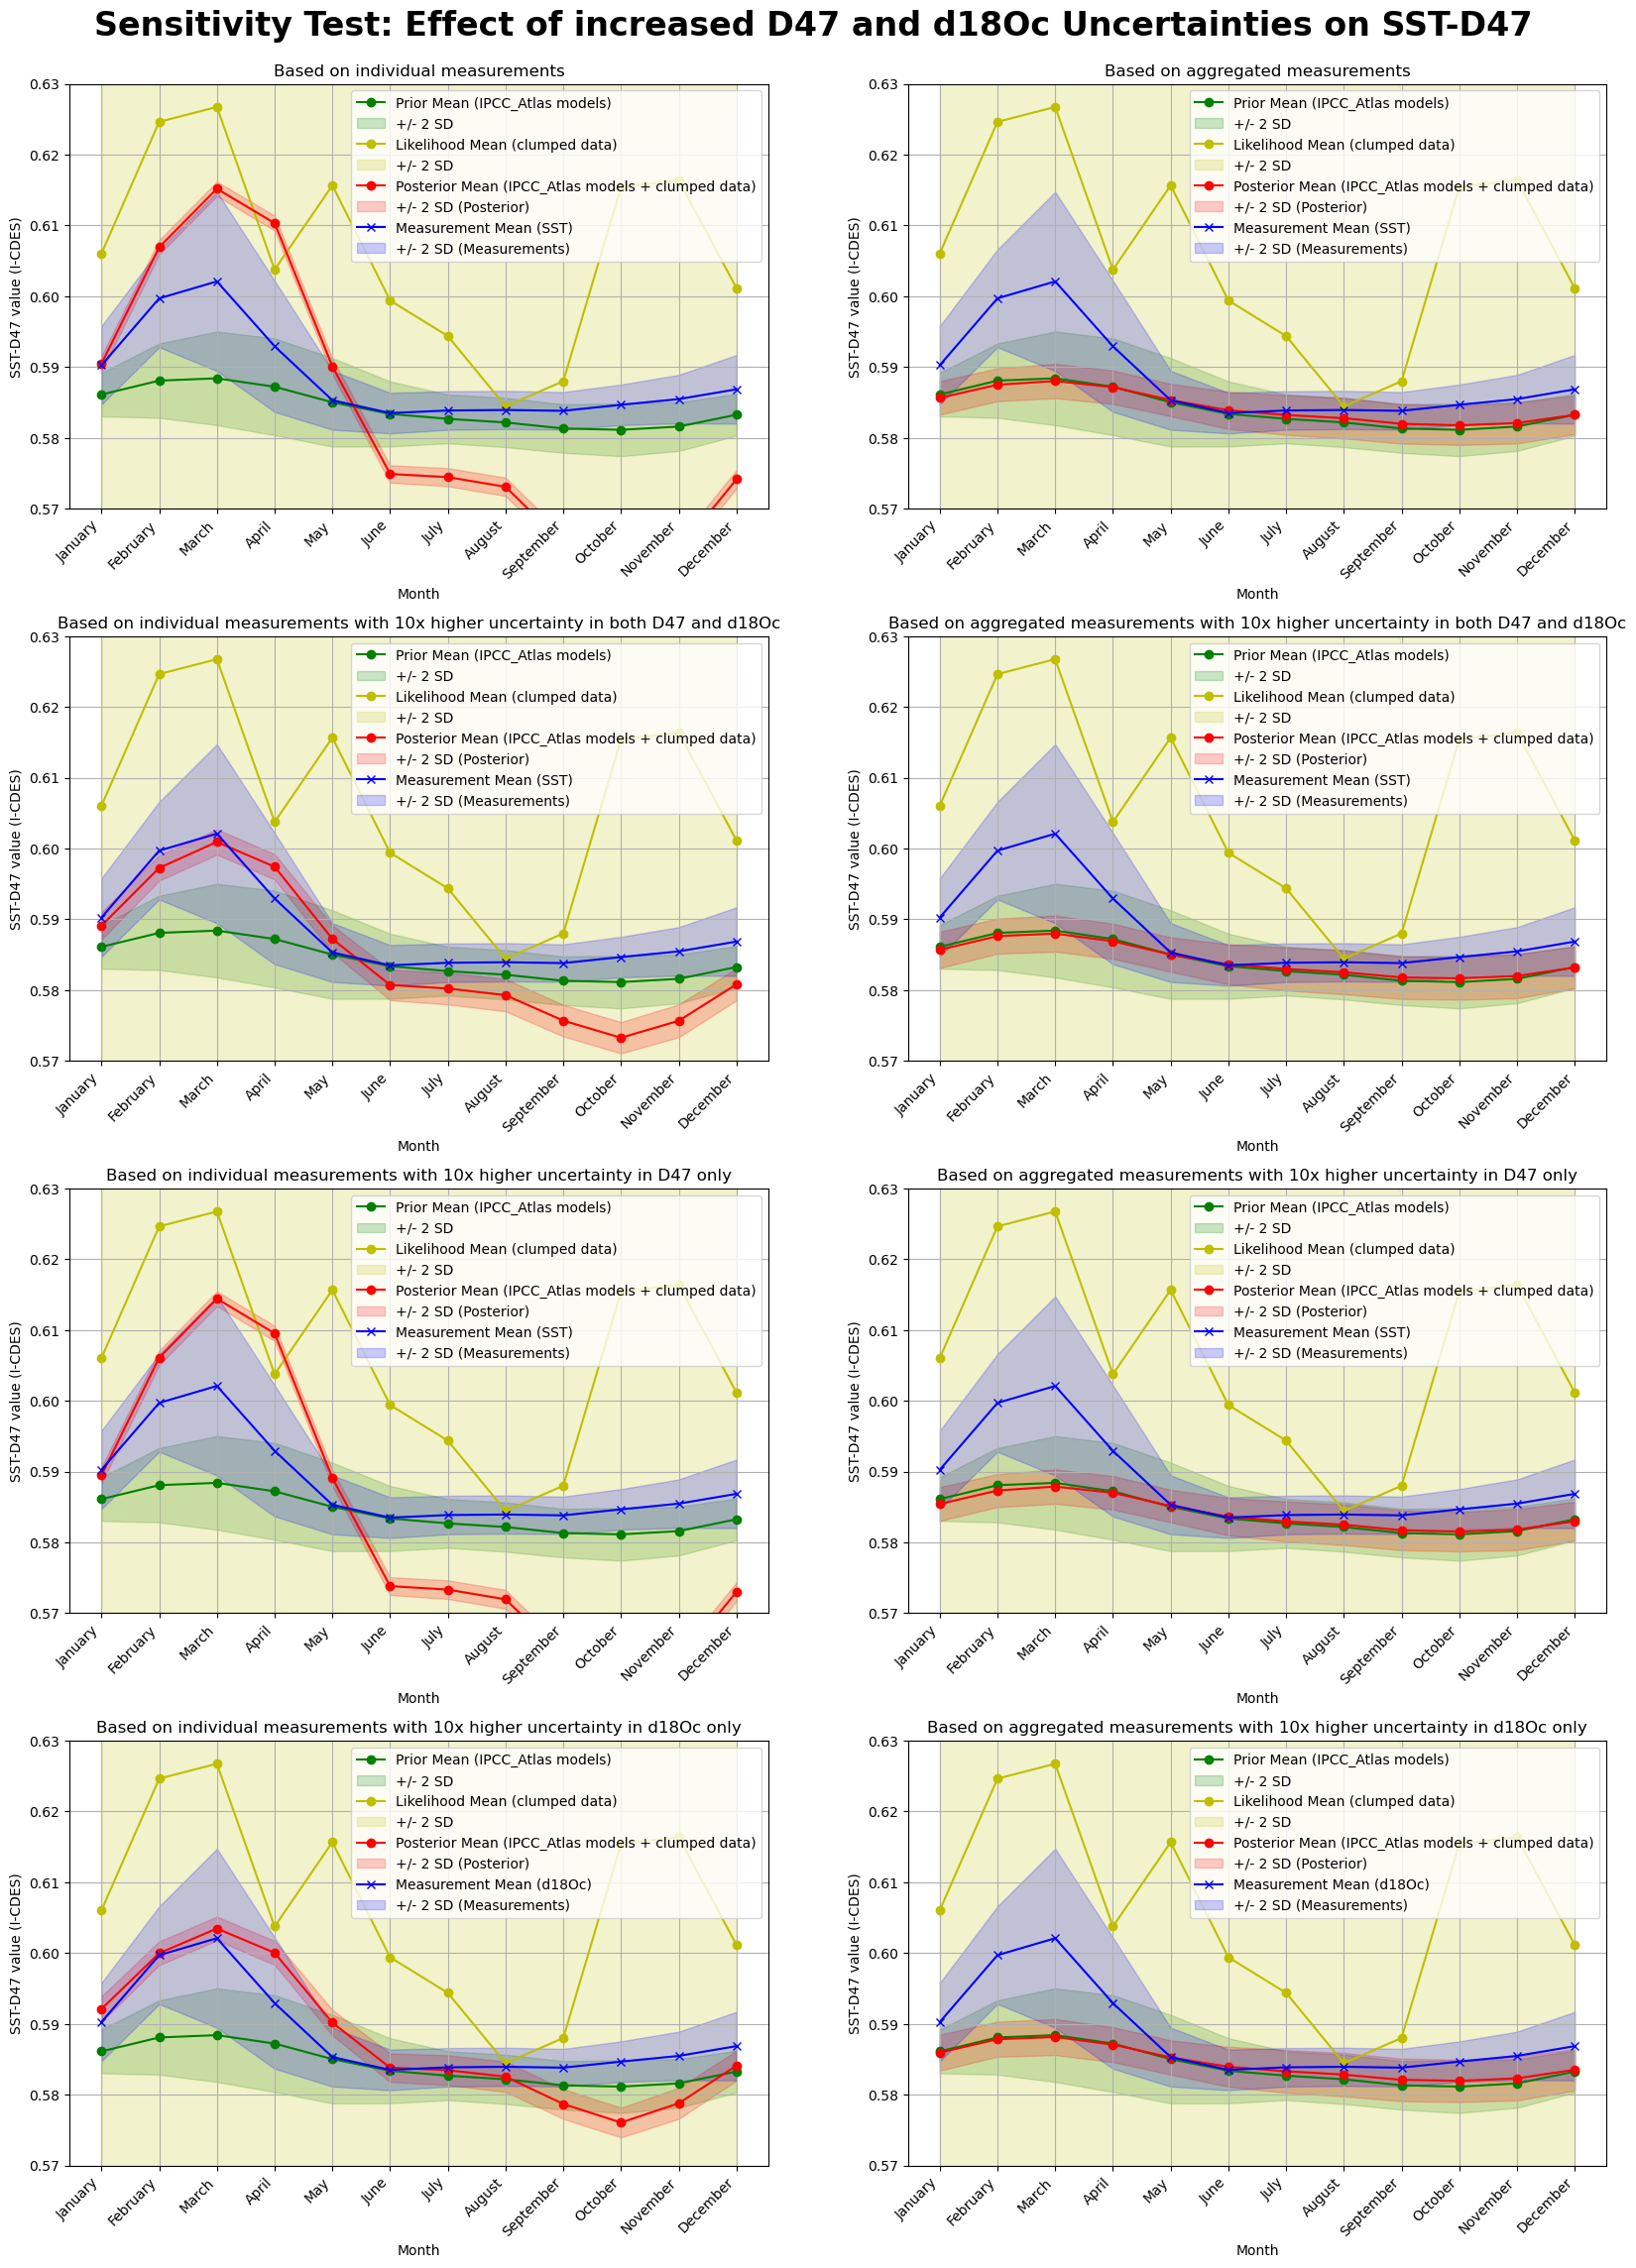

In [51]:
# Plot prior, likelihood and posterior distributions for D47 based on individual measurements

fig, axes = plt.subplots(4, 2, figsize=(20, 25))
fig.suptitle('Sensitivity Test: Effect of increased D47 and d18Oc Uncertainties on SST-D47', fontsize=24, fontweight='bold') # Provide title for the entire figure
plt.subplots_adjust(top=0.95) # Adjust top spacing to fit the title
plt.subplots_adjust(hspace=0.3) # Adjust vertical spacing between subplots to prevent overlap between titles and x-axis labels

# -- PANEL 1 -- DATA BASED ON INDIVIDUAL MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthlySC = np.sqrt(np.diag(cov_post_SST_D47_monthlySC))
std_prior_SST_D47_monthly_original = np.sqrt(np.diag(cov_prior_SST_D47_monthly_original))

# PRIOR
axes[0, 0].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 0].plot(months_scale, mu_post_SST_D47_monthlySC, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC - 2 * std_post_SST_D47_monthlySC,
    mu_post_SST_D47_monthlySC + 2 * std_post_SST_D47_monthlySC,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
# Set x-ticks and labels
axes[0, 0].set_xticks(months_scale)
axes[0, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 0].set_title('Based on individual measurements')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[0, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[0, 0].legend()
axes[0, 0].grid(True)

# -- PANEL 2 -- DATA BASED ON AGGREGATED MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthly_aggregated = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated))

# PRIOR
axes[0, 1].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated - 2 * std_post_SST_D47_monthly_aggregated,
    mu_post_SST_D47_monthly_aggregated + 2 * std_post_SST_D47_monthly_aggregated,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[0, 1].set_xticks(months_scale)
axes[0, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 1].set_title('Based on aggregated measurements')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[0, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[0, 1].legend()
axes[0, 1].grid(True)

# -- PANEL 3 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthlySC_HU = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU))

# PRIOR
axes[1, 0].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 0].plot(months_scale, mu_post_SST_D47_monthlySC_HU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC_HU - 2 * std_post_SST_D47_monthlySC_HU,
    mu_post_SST_D47_monthlySC_HU + 2 * std_post_SST_D47_monthlySC_HU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 0].set_xticks(months_scale)
axes[1, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 0].set_title('Based on individual measurements with 10x higher uncertainty in both D47 and d18Oc')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[1, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[1, 0].legend()
axes[1, 0].grid(True)

# -- PANEL 4 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthly_aggregated_HU = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU))

# PRIOR
axes[1, 1].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated_HU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated_HU - 2 * std_post_SST_D47_monthly_aggregated_HU,
    mu_post_SST_D47_monthly_aggregated_HU + 2 * std_post_SST_D47_monthly_aggregated_HU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 1].set_xticks(months_scale)
axes[1, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 1].set_title('Based on aggregated measurements with 10x higher uncertainty in both D47 and d18Oc')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[1, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[1, 1].legend()
axes[1, 1].grid(True)

# -- PANEL 5 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthlySC_HU_D47 = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU_D47))

# PRIOR
axes[2, 0].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 0].plot(months_scale, mu_post_SST_D47_monthlySC_HU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC_HU_D47 - 2 * std_post_SST_D47_monthlySC_HU_D47,
    mu_post_SST_D47_monthlySC_HU_D47 + 2 * std_post_SST_D47_monthlySC_HU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 0].set_xticks(months_scale)
axes[2, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 0].set_title('Based on individual measurements with 10x higher uncertainty in D47 only')
axes[2, 0].set_xlabel('Month')
axes[2, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[2, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[2, 0].legend()
axes[2, 0].grid(True)

# -- PANEL 6 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthly_aggregated_HU_D47 = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU_D47))

# PRIOR
axes[2, 1].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated_HU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated_HU_D47 - 2 * std_post_SST_D47_monthly_aggregated_HU_D47,
    mu_post_SST_D47_monthly_aggregated_HU_D47 + 2 * std_post_SST_D47_monthly_aggregated_HU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 1].set_xticks(months_scale)
axes[2, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 1].set_title('Based on aggregated measurements with 10x higher uncertainty in D47 only')
axes[2, 1].set_xlabel('Month')
axes[2, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[2, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[2, 1].legend()
axes[2, 1].grid(True)

# -- PANEL 7 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_SST_D47_monthlySC_HU_d18O = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU_d18O))

# PRIOR
axes[3, 0].plot(months_scale, mu_prior_SST_D47_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly - 2 * std_prior_SST_D47_monthly,
    mu_prior_SST_D47_monthly + 2 * std_prior_SST_D47_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 0].plot(months_scale, mu_post_SST_D47_monthlySC_HU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC_HU_d18O - 2 * std_post_SST_D47_monthlySC_HU_d18O,
    mu_post_SST_D47_monthlySC_HU_d18O + 2 * std_post_SST_D47_monthlySC_HU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 0].set_xticks(months_scale)
axes[3, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 0].set_title('Based on individual measurements with 10x higher uncertainty in d18Oc only')
axes[3, 0].set_xlabel('Month')
axes[3, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[3, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[3, 0].legend()
axes[3, 0].grid(True)

# -- PANEL 8 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_SST_D47_monthly_aggregated_HU_d18O = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU_d18O))

# PRIOR
axes[3, 1].plot(months_scale, mu_prior_SST_D47_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly - 2 * std_prior_SST_D47_monthly,
    mu_prior_SST_D47_monthly + 2 * std_prior_SST_D47_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated_HU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated_HU_d18O - 2 * std_post_SST_D47_monthly_aggregated_HU_d18O,
    mu_post_SST_D47_monthly_aggregated_HU_d18O + 2 * std_post_SST_D47_monthly_aggregated_HU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 1].set_xticks(months_scale)
axes[3, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 1].set_title('Based on aggregated measurements with 10x higher uncertainty in d18Oc only')
axes[3, 1].set_xlabel('Month')
axes[3, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[3, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[3, 1].legend()
axes[3, 1].grid(True)

# Show plot
plt.show()

### Plot results of uncertainty test with reduced uncertainty on D47 (SST) assimilation

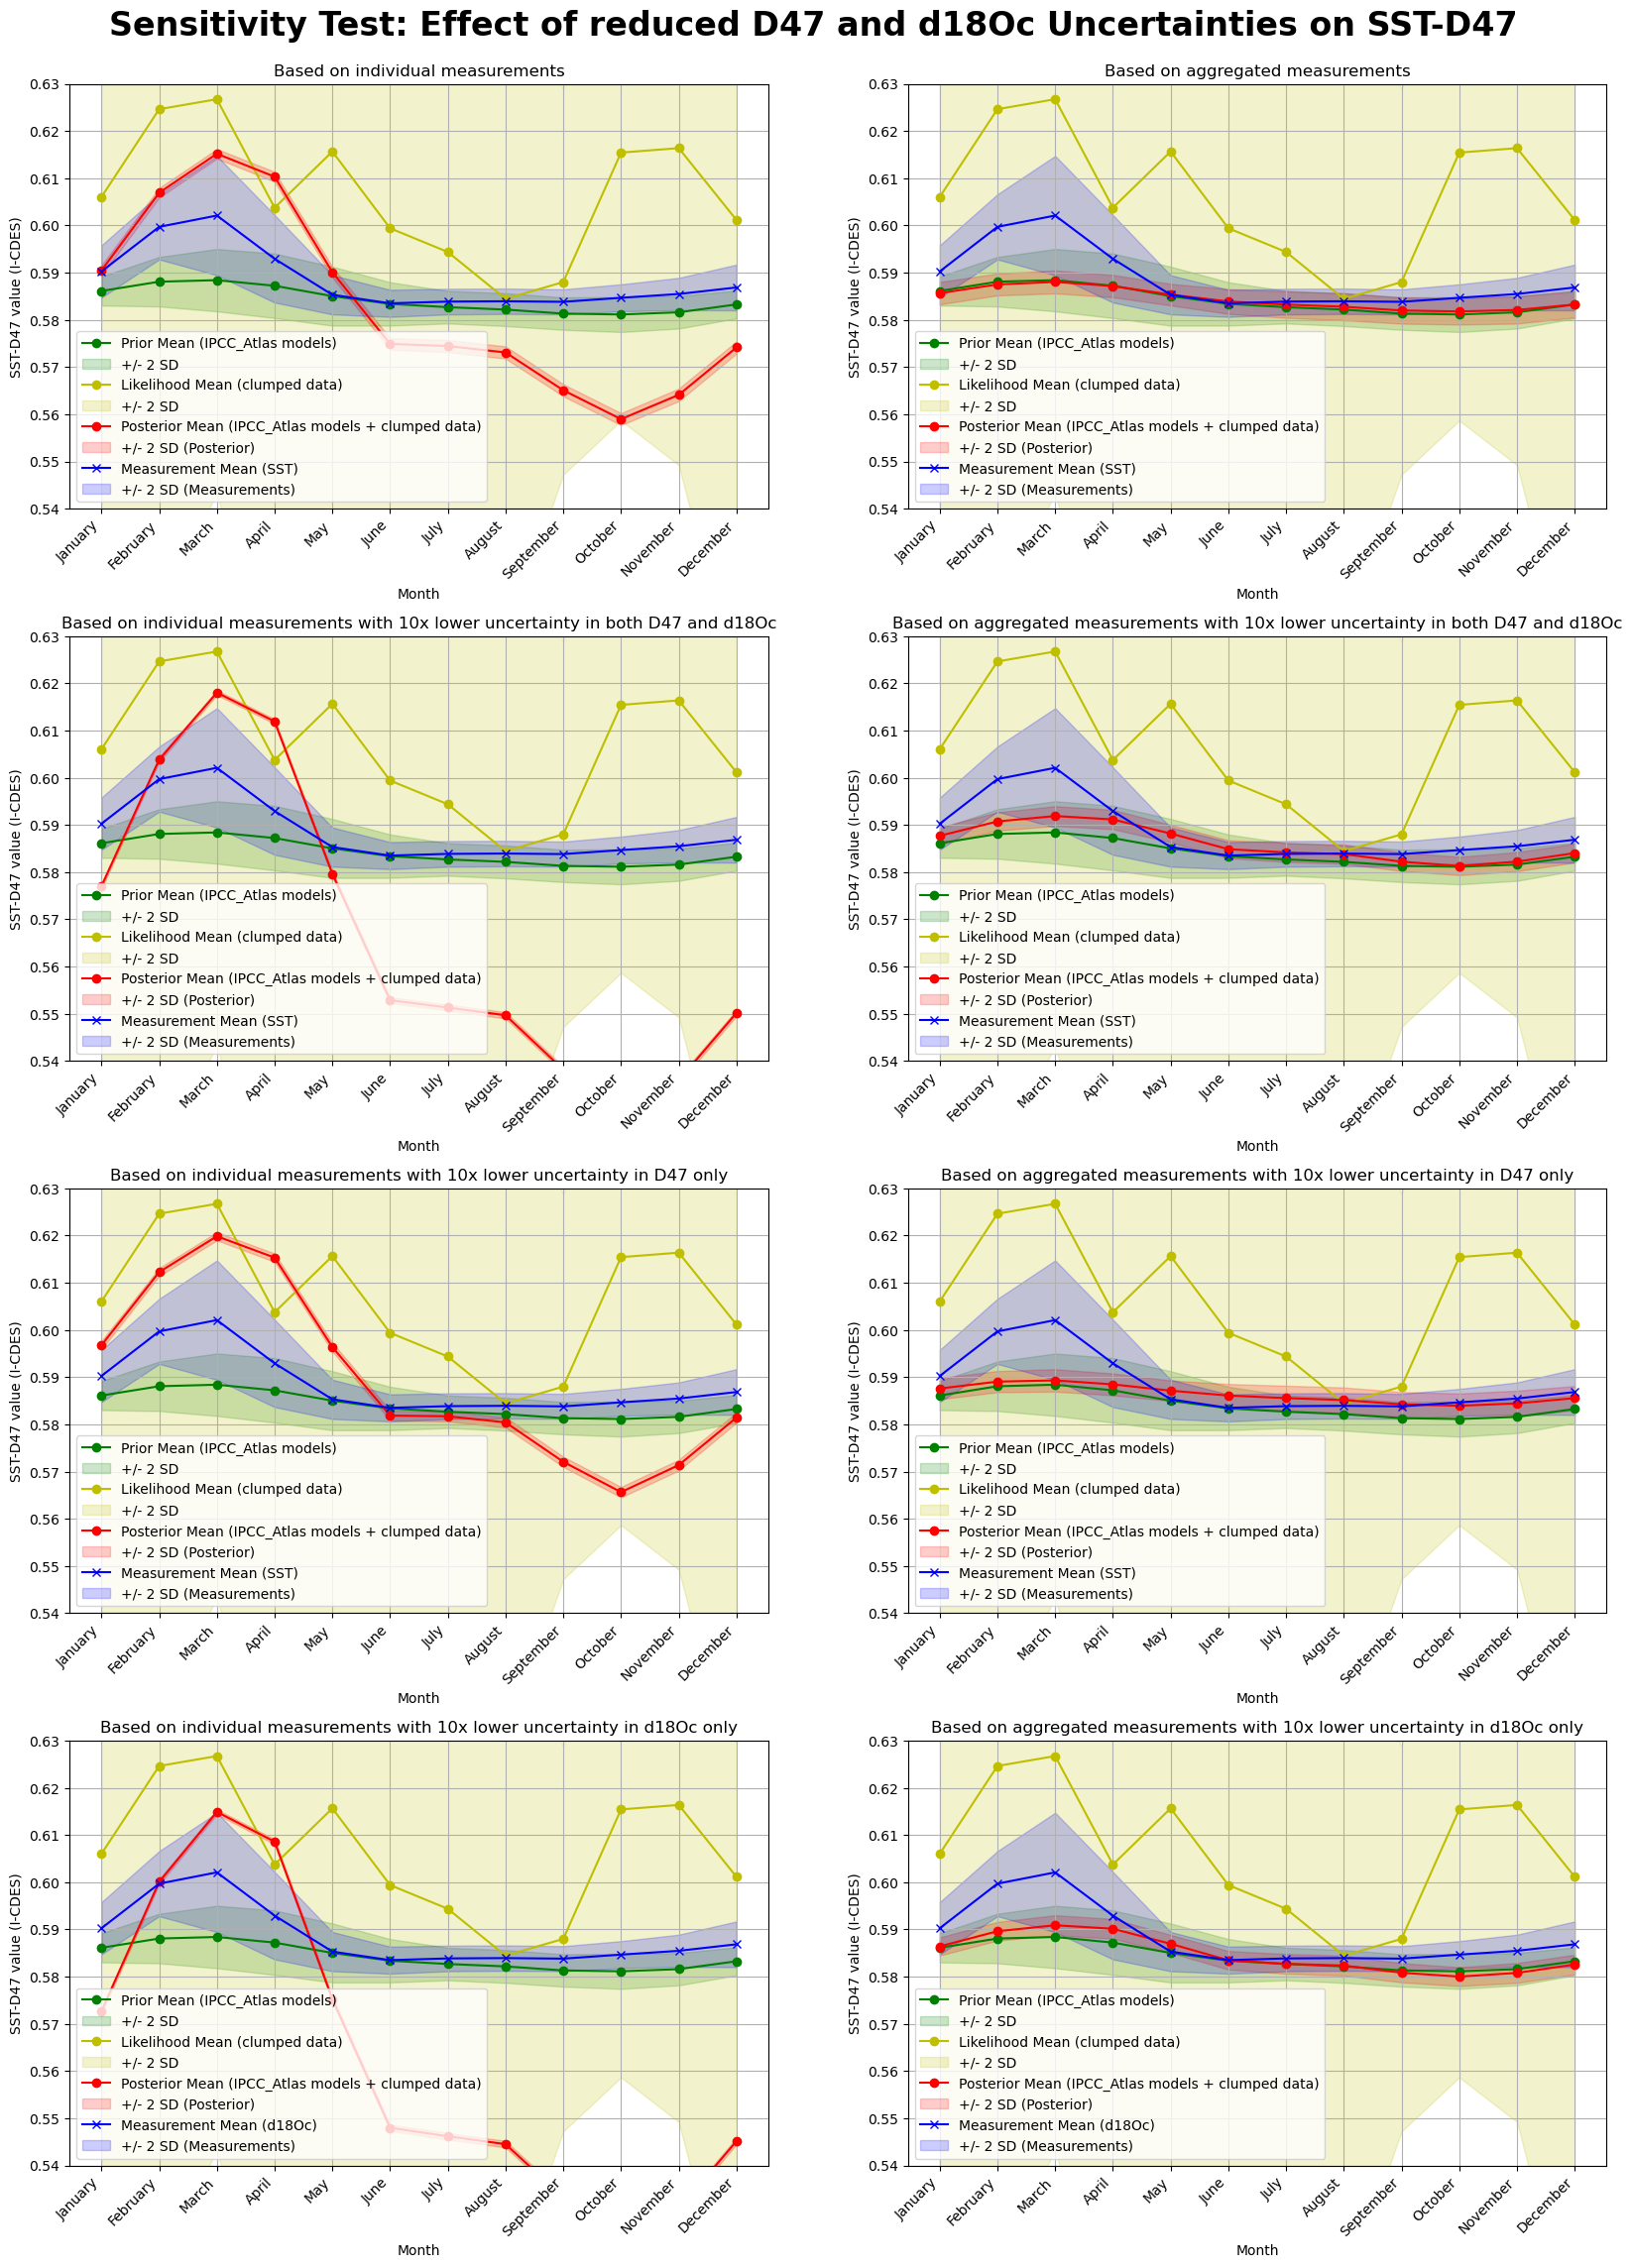

In [52]:
# Plot prior, likelihood and posterior distributions for D47 based on individual measurements

fig, axes = plt.subplots(4, 2, figsize=(20, 25))
fig.suptitle('Sensitivity Test: Effect of reduced D47 and d18Oc Uncertainties on SST-D47', fontsize=24, fontweight='bold') # Provide title for the entire figure
plt.subplots_adjust(top=0.95) # Adjust top spacing to fit the title
plt.subplots_adjust(hspace=0.3) # Adjust vertical spacing between subplots to prevent overlap between titles and x-axis labels

# -- PANEL 1 -- DATA BASED ON INDIVIDUAL MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthlySC = np.sqrt(np.diag(cov_post_SST_D47_monthlySC))
std_prior_SST_D47_monthly_original = np.sqrt(np.diag(cov_prior_SST_D47_monthly_original))

# PRIOR
axes[0, 0].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 0].plot(months_scale, mu_post_SST_D47_monthlySC, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC - 2 * std_post_SST_D47_monthlySC,
    mu_post_SST_D47_monthlySC + 2 * std_post_SST_D47_monthlySC,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
# Set x-ticks and labels
axes[0, 0].set_xticks(months_scale)
axes[0, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 0].set_title('Based on individual measurements')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[0, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[0, 0].legend()
axes[0, 0].grid(True)

# -- PANEL 2 -- DATA BASED ON AGGREGATED MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthly_aggregated = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated))

# PRIOR
axes[0, 1].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated - 2 * std_post_SST_D47_monthly_aggregated,
    mu_post_SST_D47_monthly_aggregated + 2 * std_post_SST_D47_monthly_aggregated,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[0, 1].set_xticks(months_scale)
axes[0, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 1].set_title('Based on aggregated measurements')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[0, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[0, 1].legend()
axes[0, 1].grid(True)

# -- PANEL 3 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthlySC_LU = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU))

# PRIOR
axes[1, 0].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 0].plot(months_scale, mu_post_SST_D47_monthlySC_LU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC_LU - 2 * std_post_SST_D47_monthlySC_LU,
    mu_post_SST_D47_monthlySC_LU + 2 * std_post_SST_D47_monthlySC_LU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 0].set_xticks(months_scale)
axes[1, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 0].set_title('Based on individual measurements with 10x lower uncertainty in both D47 and d18Oc')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[1, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[1, 0].legend()
axes[1, 0].grid(True)

# -- PANEL 4 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthly_aggregated_LU = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU))

# PRIOR
axes[1, 1].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated_LU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated_LU - 2 * std_post_SST_D47_monthly_aggregated_LU,
    mu_post_SST_D47_monthly_aggregated_LU + 2 * std_post_SST_D47_monthly_aggregated_LU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 1].set_xticks(months_scale)
axes[1, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 1].set_title('Based on aggregated measurements with 10x lower uncertainty in both D47 and d18Oc')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[1, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[1, 1].legend()
axes[1, 1].grid(True)

# -- PANEL 5 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthlySC_LU_D47 = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU_D47))

# PRIOR
axes[2, 0].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 0].plot(months_scale, mu_post_SST_D47_monthlySC_LU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC_LU_D47 - 2 * std_post_SST_D47_monthlySC_LU_D47,
    mu_post_SST_D47_monthlySC_LU_D47 + 2 * std_post_SST_D47_monthlySC_LU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 0].set_xticks(months_scale)
axes[2, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 0].set_title('Based on individual measurements with 10x lower uncertainty in D47 only')
axes[2, 0].set_xlabel('Month')
axes[2, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[2, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[2, 0].legend()
axes[2, 0].grid(True)

# -- PANEL 6 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_SST_D47_monthly_aggregated_LU_D47 = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU_D47))

# PRIOR
axes[2, 1].plot(months_scale, mu_prior_SST_D47_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly_original - 2 * std_prior_SST_D47_monthly_original,
    mu_prior_SST_D47_monthly_original + 2 * std_prior_SST_D47_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated_LU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated_LU_D47 - 2 * std_post_SST_D47_monthly_aggregated_LU_D47,
    mu_post_SST_D47_monthly_aggregated_LU_D47 + 2 * std_post_SST_D47_monthly_aggregated_LU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 1].set_xticks(months_scale)
axes[2, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 1].set_title('Based on aggregated measurements with 10x lower uncertainty in D47 only')
axes[2, 1].set_xlabel('Month')
axes[2, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[2, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[2, 1].legend()
axes[2, 1].grid(True)

# -- PANEL 7 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_SST_D47_monthlySC_LU_d18O = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU_d18O))

# PRIOR
axes[3, 0].plot(months_scale, mu_prior_SST_D47_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly - 2 * std_prior_SST_D47_monthly,
    mu_prior_SST_D47_monthly + 2 * std_prior_SST_D47_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 0].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 0].plot(months_scale, mu_post_SST_D47_monthlySC_LU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_post_SST_D47_monthlySC_LU_d18O - 2 * std_post_SST_D47_monthlySC_LU_d18O,
    mu_post_SST_D47_monthlySC_LU_d18O + 2 * std_post_SST_D47_monthlySC_LU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 0].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 0].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 0].set_xticks(months_scale)
axes[3, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 0].set_title('Based on individual measurements with 10x lower uncertainty in d18Oc only')
axes[3, 0].set_xlabel('Month')
axes[3, 0].set_ylabel('SST-D47 value (I-CDES)')
axes[3, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[3, 0].legend()
axes[3, 0].grid(True)

# -- PANEL 8 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_SST_D47_monthly_aggregated_LU_d18O = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU_d18O))

# PRIOR
axes[3, 1].plot(months_scale, mu_prior_SST_D47_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_prior_SST_D47_monthly - 2 * std_prior_SST_D47_monthly,
    mu_prior_SST_D47_monthly + 2 * std_prior_SST_D47_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 1].plot(months_scale, mu_likelihood_monthly_D47, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_D47 - 2 * std_likelihood_monthly_D47,
    mu_likelihood_monthly_D47 + 2 * std_likelihood_monthly_D47,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 1].plot(months_scale, mu_post_SST_D47_monthly_aggregated_LU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_post_SST_D47_monthly_aggregated_LU_d18O - 2 * std_post_SST_D47_monthly_aggregated_LU_d18O,
    mu_post_SST_D47_monthly_aggregated_LU_d18O + 2 * std_post_SST_D47_monthly_aggregated_LU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 1].plot(months_scale, mu_measurement_SST_D47_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 1].fill_between(
    months_scale,
    mu_measurement_SST_D47_monthly - 2 * std_measurement_SST_D47_monthly,
    mu_measurement_SST_D47_monthly + 2 * std_measurement_SST_D47_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 1].set_xticks(months_scale)
axes[3, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 1].set_title('Based on aggregated measurements with 10x lower uncertainty in d18Oc only')
axes[3, 1].set_xlabel('Month')
axes[3, 1].set_ylabel('SST-D47 value (I-CDES)')
axes[3, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[3, 1].legend()
axes[3, 1].grid(True)

# Show plot
plt.show()

### Plot results of uncertainty test with increased uncertainty on d18Oc assimilation

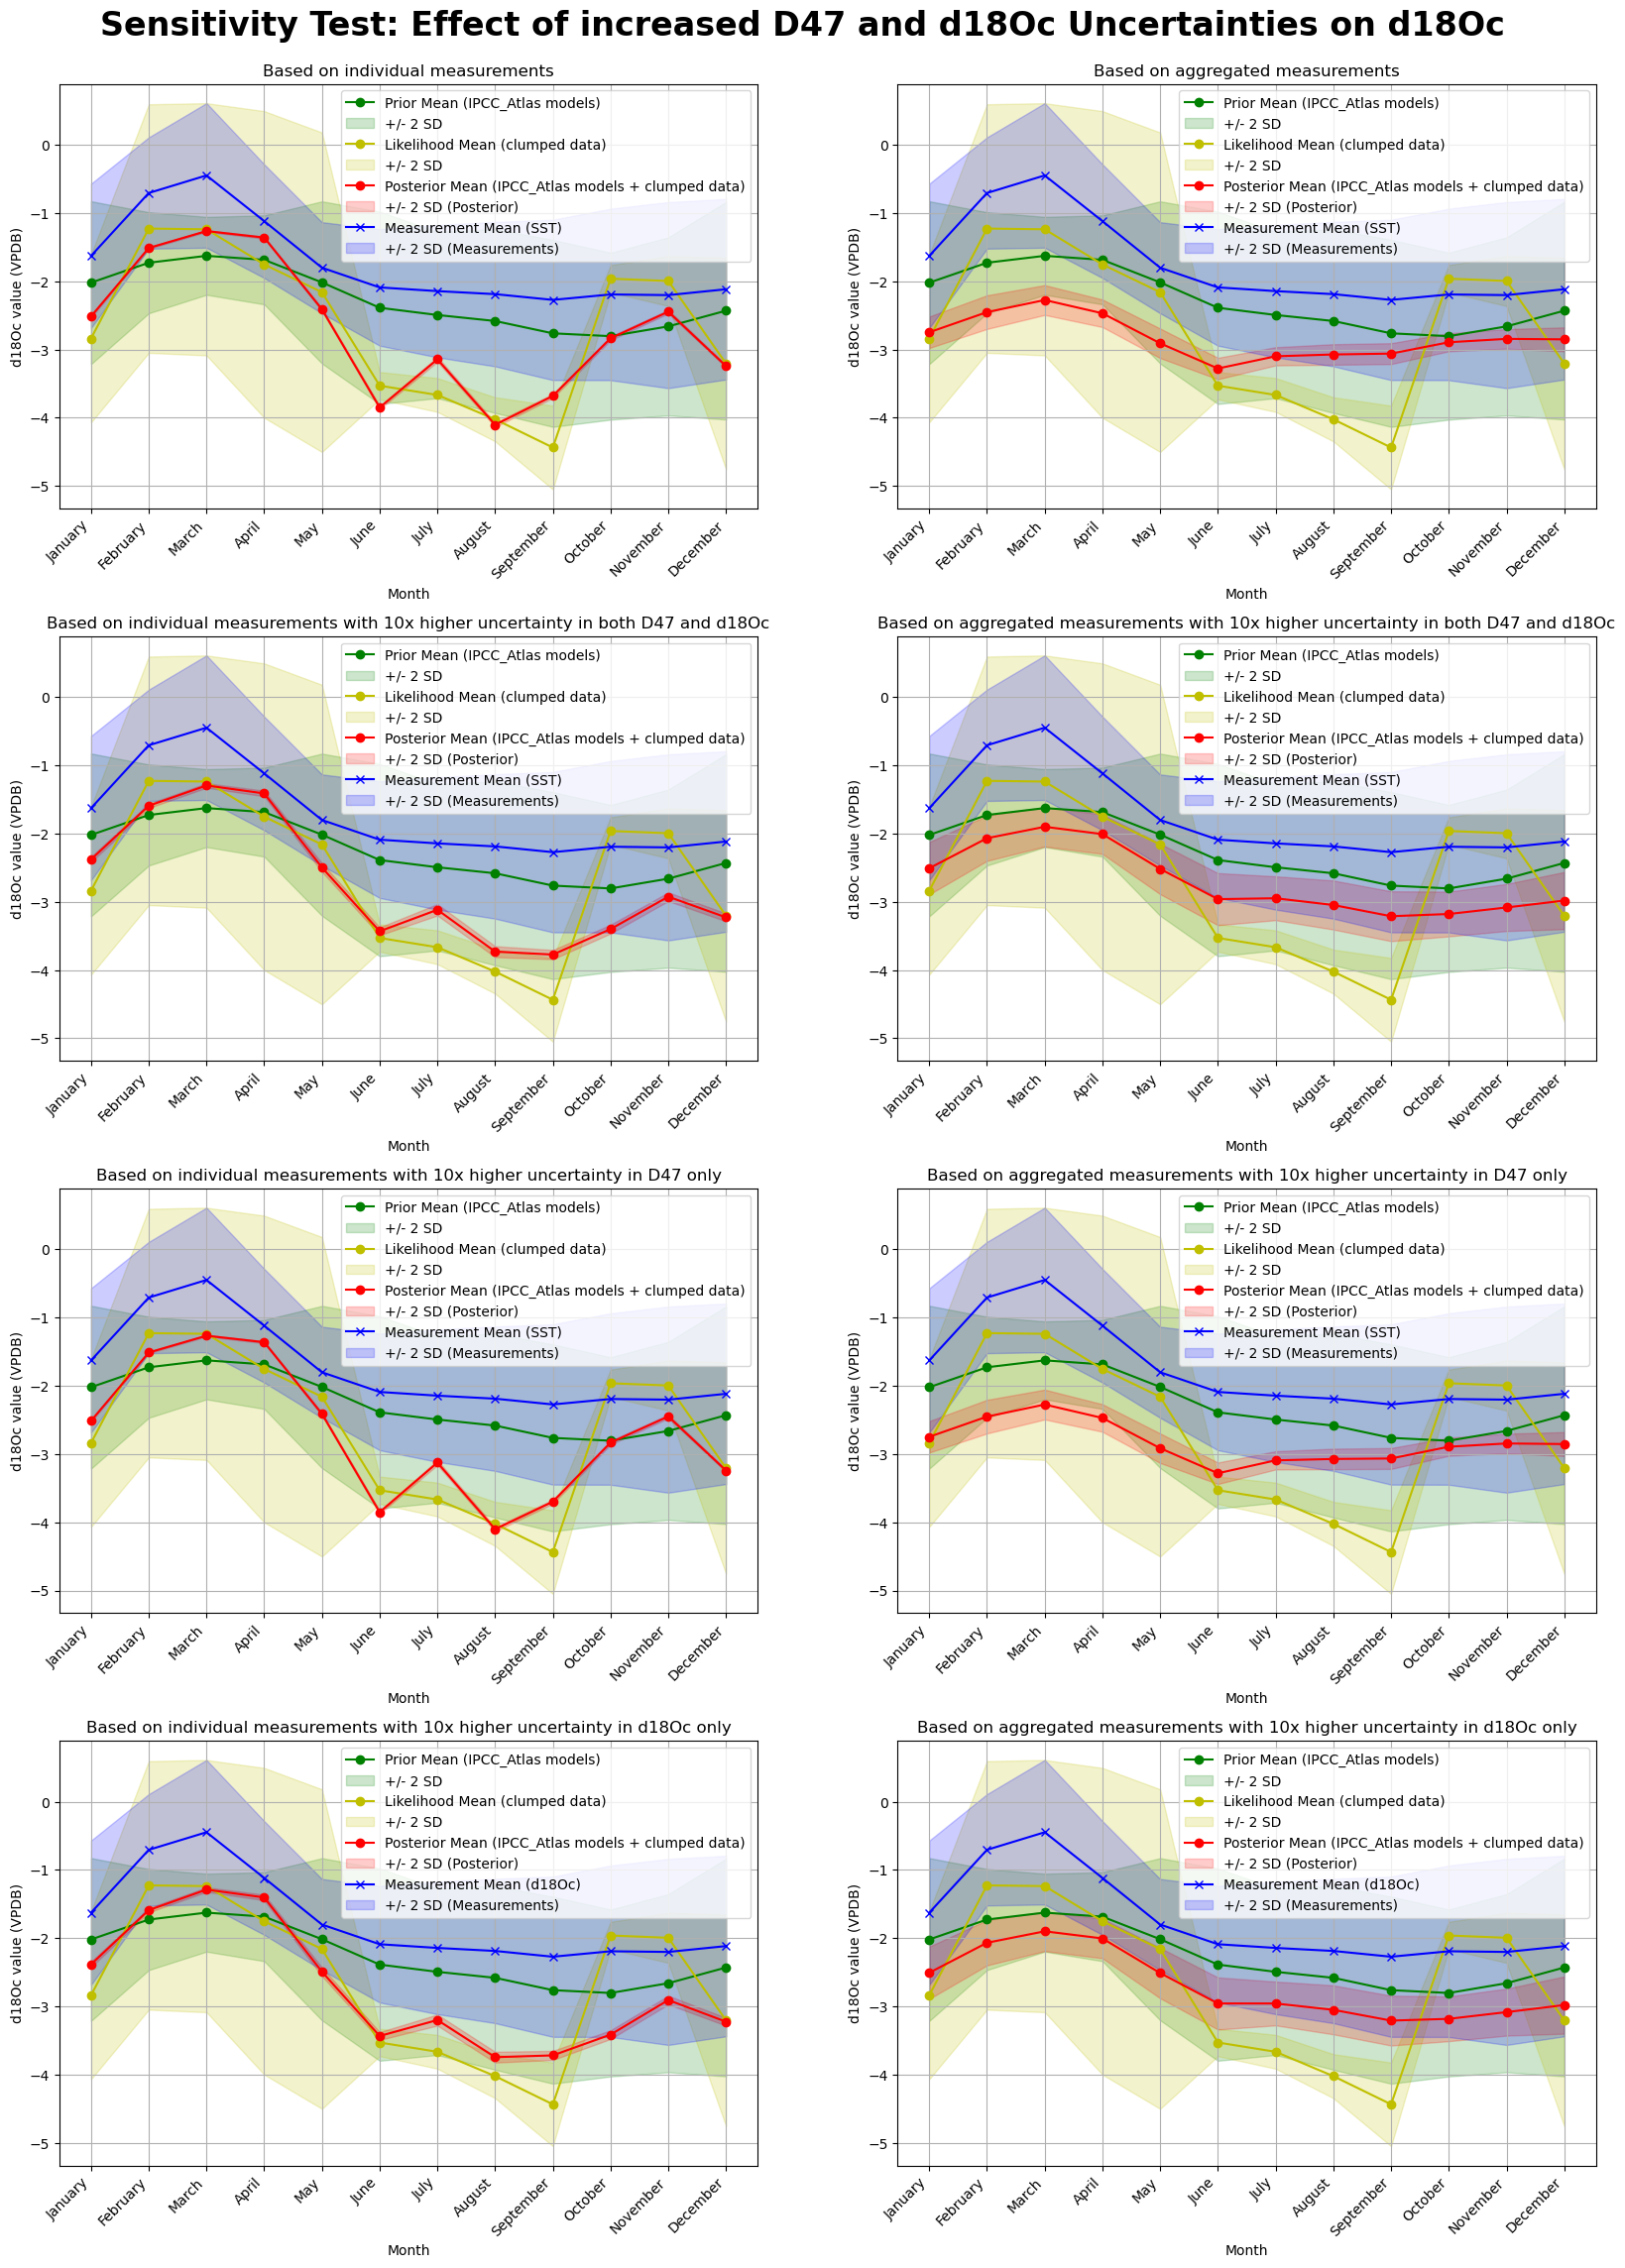

In [53]:
# Plot prior, likelihood and posterior distributions for D47 based on individual measurements

fig, axes = plt.subplots(4, 2, figsize=(20, 25))
fig.suptitle('Sensitivity Test: Effect of increased D47 and d18Oc Uncertainties on d18Oc', fontsize=24, fontweight='bold') # Provide title for the entire figure
plt.subplots_adjust(top=0.95) # Adjust top spacing to fit the title
plt.subplots_adjust(hspace=0.3) # Adjust vertical spacing between subplots to prevent overlap between titles and x-axis labels

# -- PANEL 1 -- DATA BASED ON INDIVIDUAL MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthlySC = np.sqrt(np.diag(cov_post_d18Oc_monthlySC))
std_prior_d18Oc_monthly_original = np.sqrt(np.diag(cov_prior_d18Oc_monthly_original))

# PRIOR
axes[0, 0].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 0].plot(months_scale, mu_post_d18Oc_monthlySC, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC - 2 * std_post_d18Oc_monthlySC,
    mu_post_d18Oc_monthlySC + 2 * std_post_d18Oc_monthlySC,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
# Set x-ticks and labels
axes[0, 0].set_xticks(months_scale)
axes[0, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 0].set_title('Based on individual measurements')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('d18Oc value (VPDB)')
# axes[0, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[0, 0].legend()
axes[0, 0].grid(True)

# -- PANEL 2 -- DATA BASED ON AGGREGATED MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthly_aggregated = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated))

# PRIOR
axes[0, 1].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated - 2 * std_post_d18Oc_monthly_aggregated,
    mu_post_d18Oc_monthly_aggregated + 2 * std_post_d18Oc_monthly_aggregated,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[0, 1].set_xticks(months_scale)
axes[0, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 1].set_title('Based on aggregated measurements')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('d18Oc value (VPDB)')
# axes[0, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[0, 1].legend()
axes[0, 1].grid(True)

# -- PANEL 3 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthlySC_HU = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU))

# PRIOR
axes[1, 0].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 0].plot(months_scale, mu_post_d18Oc_monthlySC_HU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC_HU - 2 * std_post_d18Oc_monthlySC_HU,
    mu_post_d18Oc_monthlySC_HU + 2 * std_post_d18Oc_monthlySC_HU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 0].set_xticks(months_scale)
axes[1, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 0].set_title('Based on individual measurements with 10x higher uncertainty in both D47 and d18Oc')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('d18Oc value (VPDB)')
# axes[1, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[1, 0].legend()
axes[1, 0].grid(True)

# -- PANEL 4 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthly_aggregated_HU = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU))

# PRIOR
axes[1, 1].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated_HU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated_HU - 2 * std_post_d18Oc_monthly_aggregated_HU,
    mu_post_d18Oc_monthly_aggregated_HU + 2 * std_post_d18Oc_monthly_aggregated_HU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 1].set_xticks(months_scale)
axes[1, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 1].set_title('Based on aggregated measurements with 10x higher uncertainty in both D47 and d18Oc')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('d18Oc value (VPDB)')
# axes[1, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[1, 1].legend()
axes[1, 1].grid(True)

# -- PANEL 5 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthlySC_HU_D47 = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU_D47))

# PRIOR
axes[2, 0].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 0].plot(months_scale, mu_post_d18Oc_monthlySC_HU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC_HU_D47 - 2 * std_post_d18Oc_monthlySC_HU_D47,
    mu_post_d18Oc_monthlySC_HU_D47 + 2 * std_post_d18Oc_monthlySC_HU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 0].set_xticks(months_scale)
axes[2, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 0].set_title('Based on individual measurements with 10x higher uncertainty in D47 only')
axes[2, 0].set_xlabel('Month')
axes[2, 0].set_ylabel('d18Oc value (VPDB)')
# axes[2, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[2, 0].legend()
axes[2, 0].grid(True)

# -- PANEL 6 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthly_aggregated_HU_D47 = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU_D47))

# PRIOR
axes[2, 1].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated_HU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated_HU_D47 - 2 * std_post_d18Oc_monthly_aggregated_HU_D47,
    mu_post_d18Oc_monthly_aggregated_HU_D47 + 2 * std_post_d18Oc_monthly_aggregated_HU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 1].set_xticks(months_scale)
axes[2, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 1].set_title('Based on aggregated measurements with 10x higher uncertainty in D47 only')
axes[2, 1].set_xlabel('Month')
axes[2, 1].set_ylabel('d18Oc value (VPDB)')
# axes[2, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[2, 1].legend()
axes[2, 1].grid(True)

# -- PANEL 7 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_d18Oc_monthlySC_HU_d18O = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU_d18O))

# PRIOR
axes[3, 0].plot(months_scale, mu_prior_d18Oc_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly - 2 * std_prior_d18Oc_monthly,
    mu_prior_d18Oc_monthly + 2 * std_prior_d18Oc_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 0].plot(months_scale, mu_post_d18Oc_monthlySC_HU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC_HU_d18O - 2 * std_post_d18Oc_monthlySC_HU_d18O,
    mu_post_d18Oc_monthlySC_HU_d18O + 2 * std_post_d18Oc_monthlySC_HU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 0].set_xticks(months_scale)
axes[3, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 0].set_title('Based on individual measurements with 10x higher uncertainty in d18Oc only')
axes[3, 0].set_xlabel('Month')
axes[3, 0].set_ylabel('d18Oc value (VPDB)')
# axes[3, 0].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[3, 0].legend()
axes[3, 0].grid(True)

# -- PANEL 8 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_d18Oc_monthly_aggregated_HU_d18O = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU_d18O))

# PRIOR
axes[3, 1].plot(months_scale, mu_prior_d18Oc_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly - 2 * std_prior_d18Oc_monthly,
    mu_prior_d18Oc_monthly + 2 * std_prior_d18Oc_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated_HU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated_HU_d18O - 2 * std_post_d18Oc_monthly_aggregated_HU_d18O,
    mu_post_d18Oc_monthly_aggregated_HU_d18O + 2 * std_post_d18Oc_monthly_aggregated_HU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 1].set_xticks(months_scale)
axes[3, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 1].set_title('Based on aggregated measurements with 10x higher uncertainty in d18Oc only')
axes[3, 1].set_xlabel('Month')
axes[3, 1].set_ylabel('d18Oc value (VPDB)')
# axes[3, 1].set_ylim(0.57, 0.63)  # Set y-axis limits for better visibility
axes[3, 1].legend()
axes[3, 1].grid(True)

# Show plot
plt.show()

### Plot results of uncertainty test with reduced uncertainty on d18Oc assimilation

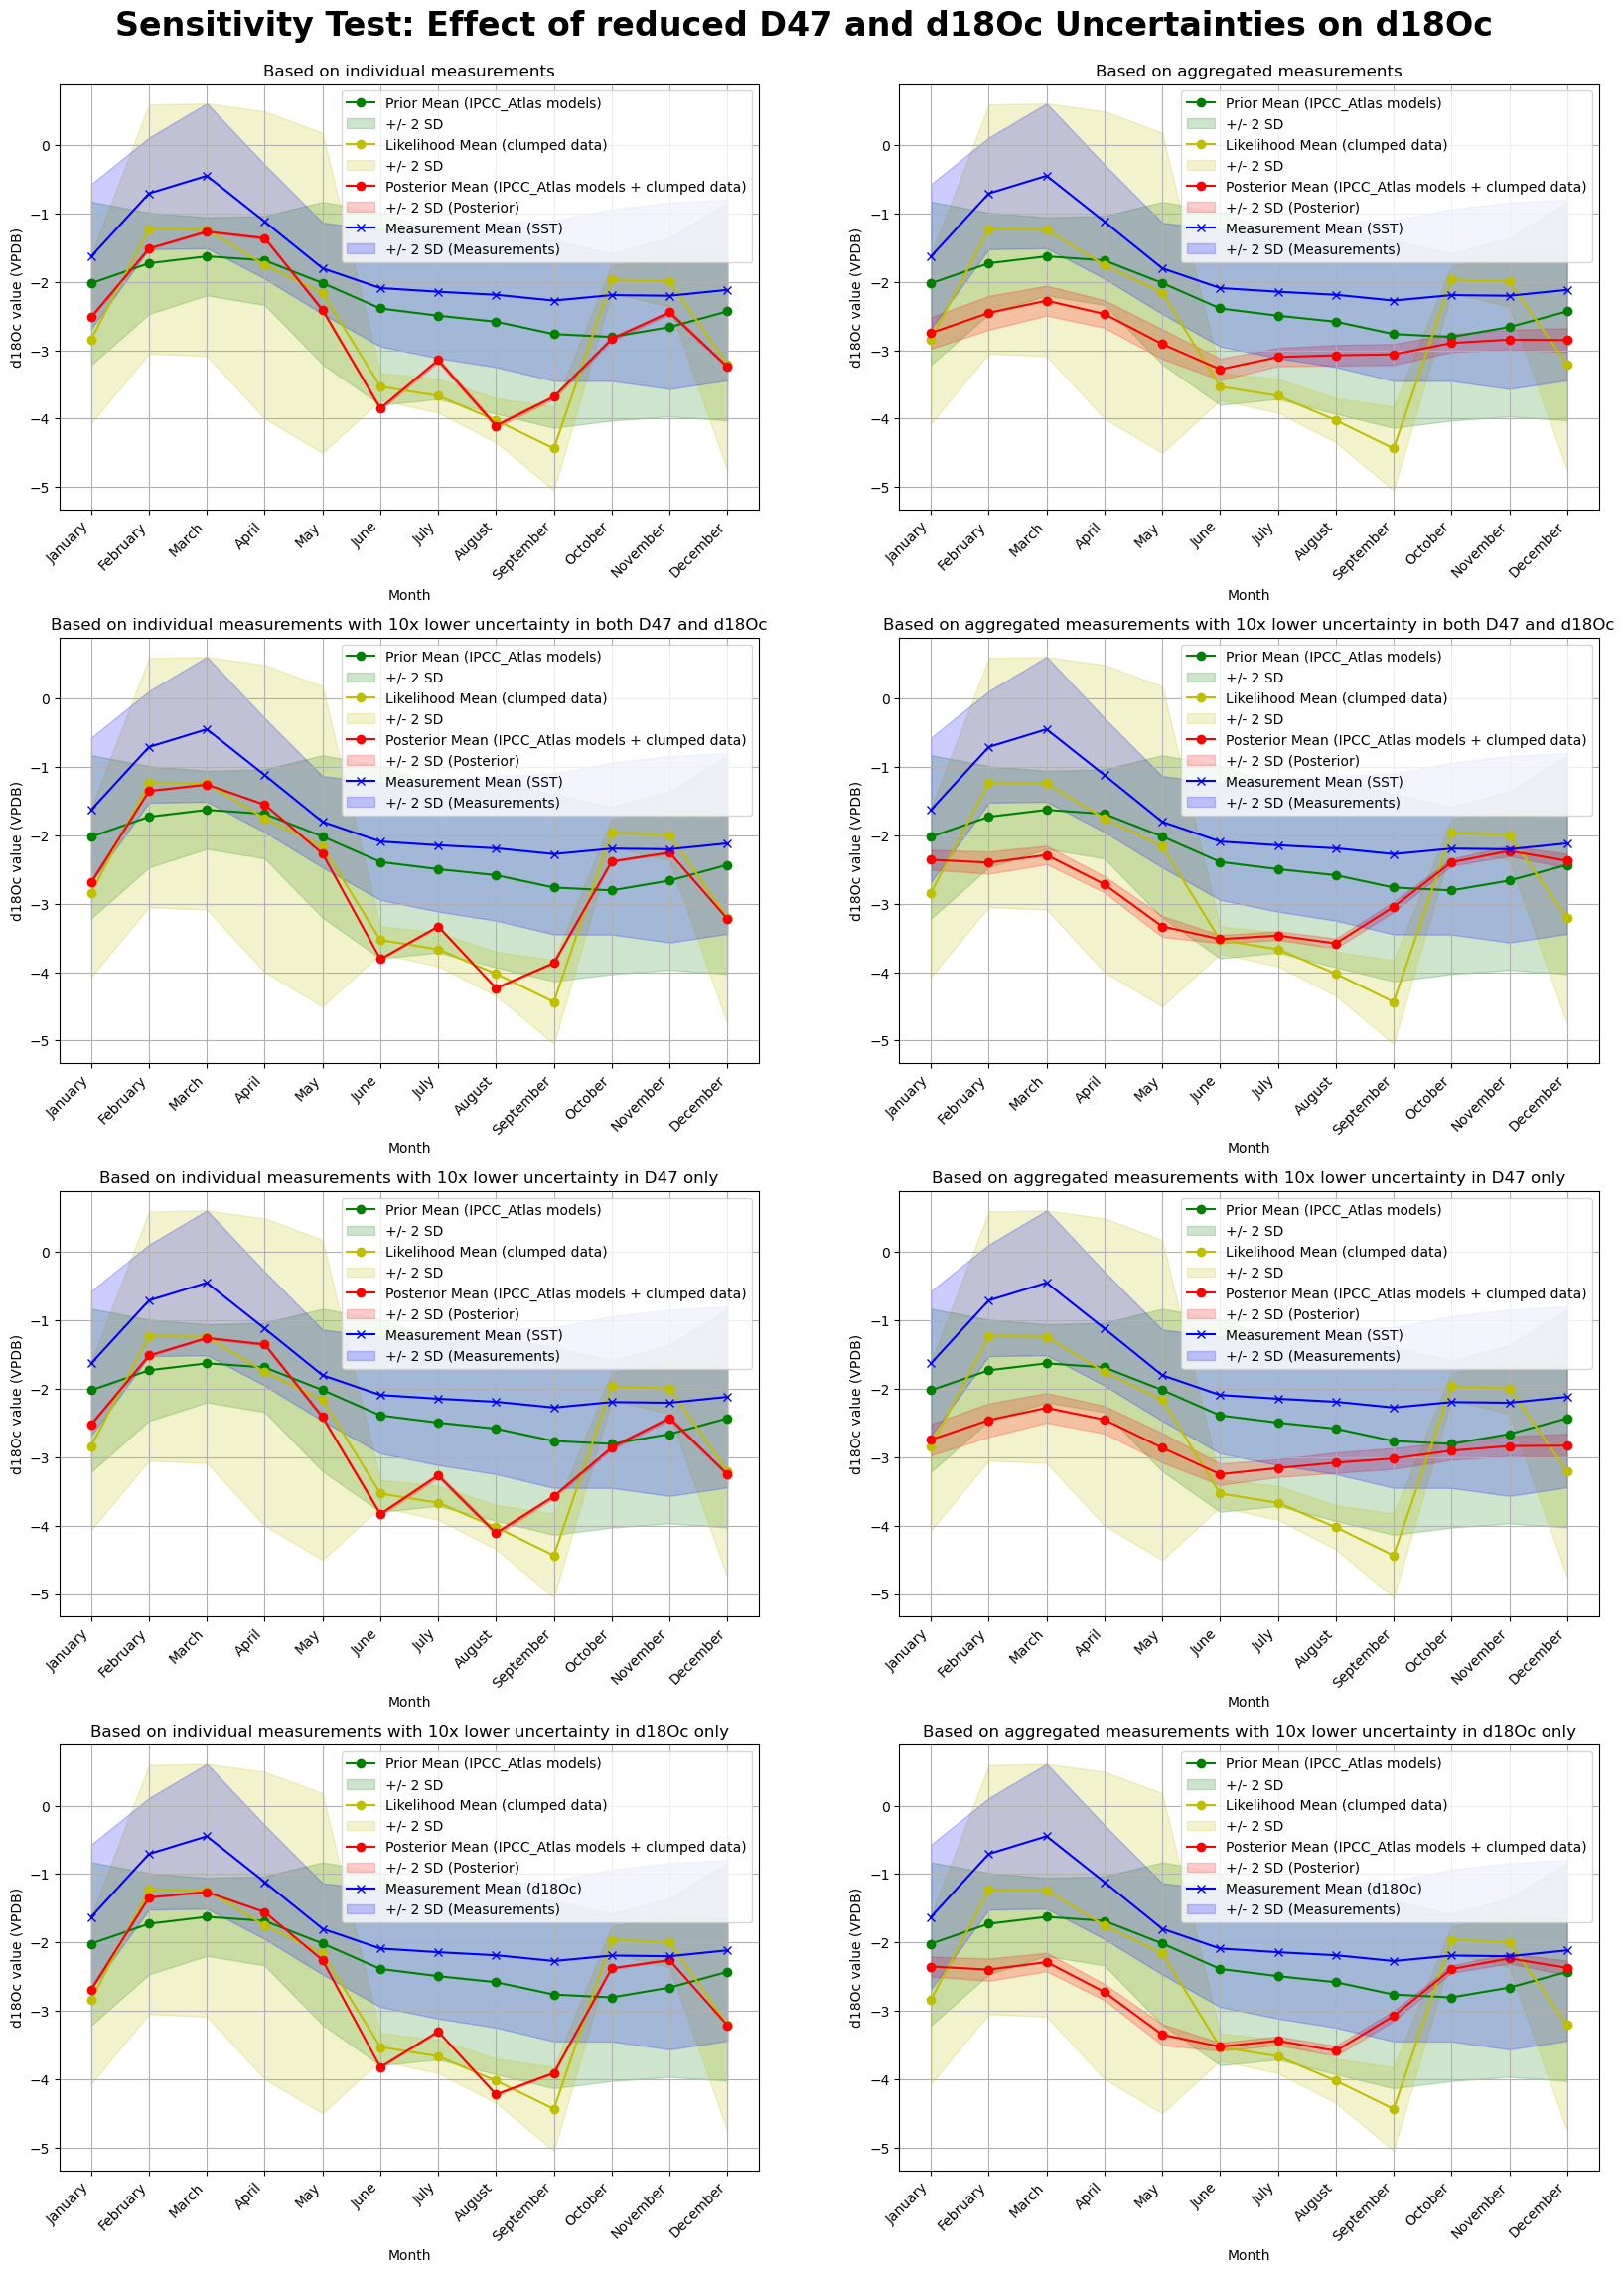

In [54]:
# Plot prior, likelihood and posterior distributions for D47 based on individual measurements

fig, axes = plt.subplots(4, 2, figsize=(20, 25))
fig.suptitle('Sensitivity Test: Effect of reduced D47 and d18Oc Uncertainties on d18Oc', fontsize=24, fontweight='bold') # Provide title for the entire figure
plt.subplots_adjust(top=0.95) # Adjust top spacing to fit the title
plt.subplots_adjust(hspace=0.3) # Adjust vertical spacing between subplots to prevent overlap between titles and x-axis labels

# -- PANEL 1 -- DATA BASED ON INDIVIDUAL MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthlySC = np.sqrt(np.diag(cov_post_d18Oc_monthlySC))
std_prior_d18Oc_monthly_original = np.sqrt(np.diag(cov_prior_d18Oc_monthly_original))

# PRIOR
axes[0, 0].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 0].plot(months_scale, mu_post_d18Oc_monthlySC, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC - 2 * std_post_d18Oc_monthlySC,
    mu_post_d18Oc_monthlySC + 2 * std_post_d18Oc_monthlySC,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
# Set x-ticks and labels
axes[0, 0].set_xticks(months_scale)
axes[0, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 0].set_title('Based on individual measurements')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('d18Oc value (VPDB)')
# axes[0, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[0, 0].legend()
axes[0, 0].grid(True)

# -- PANEL 2 -- DATA BASED ON AGGREGATED MEASUREMENTS
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthly_aggregated = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated))

# PRIOR
axes[0, 1].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[0, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[0, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[0, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated - 2 * std_post_d18Oc_monthly_aggregated,
    mu_post_d18Oc_monthly_aggregated + 2 * std_post_d18Oc_monthly_aggregated,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[0, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[0, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[0, 1].set_xticks(months_scale)
axes[0, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[0, 1].set_title('Based on aggregated measurements')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('d18Oc value (VPDB)')
# axes[0, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[0, 1].legend()
axes[0, 1].grid(True)

# -- PANEL 3 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthlySC_LU = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU))

# PRIOR
axes[1, 0].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 0].plot(months_scale, mu_post_d18Oc_monthlySC_LU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC_LU - 2 * std_post_d18Oc_monthlySC_LU,
    mu_post_d18Oc_monthlySC_LU + 2 * std_post_d18Oc_monthlySC_LU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 0].set_xticks(months_scale)
axes[1, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 0].set_title('Based on individual measurements with 10x lower uncertainty in both D47 and d18Oc')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('d18Oc value (VPDB)')
# axes[1, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[1, 0].legend()
axes[1, 0].grid(True)

# -- PANEL 4 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON BOTH D47 AND d18O
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthly_aggregated_LU = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU))

# PRIOR
axes[1, 1].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[1, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[1, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated_LU, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[1, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated_LU - 2 * std_post_d18Oc_monthly_aggregated_LU,
    mu_post_d18Oc_monthly_aggregated_LU + 2 * std_post_d18Oc_monthly_aggregated_LU,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[1, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[1, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[1, 1].set_xticks(months_scale)
axes[1, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[1, 1].set_title('Based on aggregated measurements with 10x lower uncertainty in both D47 and d18Oc')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('d18Oc value (VPDB)')
# axes[1, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[1, 1].legend()
axes[1, 1].grid(True)

# -- PANEL 5 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthlySC_LU_D47 = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU_D47))

# PRIOR
axes[2, 0].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 0].plot(months_scale, mu_post_d18Oc_monthlySC_LU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC_LU_D47 - 2 * std_post_d18Oc_monthlySC_LU_D47,
    mu_post_d18Oc_monthlySC_LU_D47 + 2 * std_post_d18Oc_monthlySC_LU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 0].set_xticks(months_scale)
axes[2, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 0].set_title('Based on individual measurements with 10x lower uncertainty in D47 only')
axes[2, 0].set_xlabel('Month')
axes[2, 0].set_ylabel('d18Oc value (VPDB)')
# axes[2, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[2, 0].legend()
axes[2, 0].grid(True)

# -- PANEL 6 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON D47 ONLY
# Calculate the updated seasonal posterior for SST_D47
std_post_d18Oc_monthly_aggregated_LU_D47 = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU_D47))

# PRIOR
axes[2, 1].plot(months_scale, mu_prior_d18Oc_monthly_original, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly_original - 2 * std_prior_d18Oc_monthly_original,
    mu_prior_d18Oc_monthly_original + 2 * std_prior_d18Oc_monthly_original,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[2, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[2, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated_LU_D47, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[2, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated_LU_D47 - 2 * std_post_d18Oc_monthly_aggregated_LU_D47,
    mu_post_d18Oc_monthly_aggregated_LU_D47 + 2 * std_post_d18Oc_monthly_aggregated_LU_D47,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[2, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (SST)', color='b', marker='x')
axes[2, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[2, 1].set_xticks(months_scale)
axes[2, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[2, 1].set_title('Based on aggregated measurements with 10x lower uncertainty in D47 only')
axes[2, 1].set_xlabel('Month')
axes[2, 1].set_ylabel('d18Oc value (VPDB)')
# axes[2, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[2, 1].legend()
axes[2, 1].grid(True)

# -- PANEL 7 -- DATA BASED ON INDIVIDUAL MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_d18Oc_monthlySC_LU_d18O = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU_d18O))

# PRIOR
axes[3, 0].plot(months_scale, mu_prior_d18Oc_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly - 2 * std_prior_d18Oc_monthly,
    mu_prior_d18Oc_monthly + 2 * std_prior_d18Oc_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 0].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 0].plot(months_scale, mu_post_d18Oc_monthlySC_LU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 0].fill_between(
    months_scale,
    mu_post_d18Oc_monthlySC_LU_d18O - 2 * std_post_d18Oc_monthlySC_LU_d18O,
    mu_post_d18Oc_monthlySC_LU_d18O + 2 * std_post_d18Oc_monthlySC_LU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 0].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 0].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 0].set_xticks(months_scale)
axes[3, 0].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 0].set_title('Based on individual measurements with 10x lower uncertainty in d18Oc only')
axes[3, 0].set_xlabel('Month')
axes[3, 0].set_ylabel('d18Oc value (VPDB)')
# axes[3, 0].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[3, 0].legend()
axes[3, 0].grid(True)

# -- PANEL 8 -- DATA BASED ON AGGREGATED MEASUREMENTS WITH HIGHER UNCERTAINTY ON d18Oc ONLY
# Calculate the updated seasonal posterior for D47
std_post_d18Oc_monthly_aggregated_LU_d18O = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU_d18O))

# PRIOR
axes[3, 1].plot(months_scale, mu_prior_d18Oc_monthly, label='Prior Mean (IPCC_Atlas models)', color='g', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_prior_d18Oc_monthly - 2 * std_prior_d18Oc_monthly,
    mu_prior_d18Oc_monthly + 2 * std_prior_d18Oc_monthly,
    color='g',
    alpha=0.2,
    label='+/- 2 SD'
)
# LIKELIHOOD
axes[3, 1].plot(months_scale, mu_likelihood_monthly_d18Oc, label='Likelihood Mean (clumped data)', color='y', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_likelihood_monthly_d18Oc - 2 * std_likelihood_monthly_d18Oc,
    mu_likelihood_monthly_d18Oc + 2 * std_likelihood_monthly_d18Oc,
    color='y',
    alpha=0.2,
    label='+/- 2 SD'
)
# POSTERIOR
axes[3, 1].plot(months_scale, mu_post_d18Oc_monthly_aggregated_LU_d18O, label='Posterior Mean (IPCC_Atlas models + clumped data)', color='r', marker='o')
axes[3, 1].fill_between(
    months_scale,
    mu_post_d18Oc_monthly_aggregated_LU_d18O - 2 * std_post_d18Oc_monthly_aggregated_LU_d18O,
    mu_post_d18Oc_monthly_aggregated_LU_d18O + 2 * std_post_d18Oc_monthly_aggregated_LU_d18O,
    color='r',
    alpha=0.2,
    label='+/- 2 SD (Posterior)'
)
# MEASUREMENT DATA
axes[3, 1].plot(months_scale, mu_measurement_d18Oc_monthly, label='Measurement Mean (d18Oc)', color='b', marker='x')
axes[3, 1].fill_between(
    months_scale,
    mu_measurement_d18Oc_monthly - 2 * std_measurement_d18Oc_monthly,
    mu_measurement_d18Oc_monthly + 2 * std_measurement_d18Oc_monthly,
    color='b',
    alpha=0.2,
    label='+/- 2 SD (Measurements)'
)
axes[3, 1].set_xticks(months_scale)
axes[3, 1].set_xticklabels(month_names, rotation=45, ha="right")
axes[3, 1].set_title('Based on aggregated measurements with 10x lower uncertainty in d18Oc only')
axes[3, 1].set_xlabel('Month')
axes[3, 1].set_ylabel('d18Oc value (VPDB)')
# axes[3, 1].set_ylim(0.54, 0.63)  # Set y-axis limits for better visibility
axes[3, 1].legend()
axes[3, 1].grid(True)

# Show plot
plt.show()

### Aggregate statistics on posterior outcomes on SST-D47 and d18Oc for all cases

In [55]:
# Prepare the data for the table
data_monthly = {
    "Data Type": [
        "Prior estimates, monthly resolved",
        "In situ measurements, monthly resolved",
        "Individual Measurements, monthly resolved",
        "Individual Measurements, monthly resolved (Age SD = 1 month)",
        "Individual Measurements, monthly resolved (SD D47 * 10)",
        "Individual Measurements, monthly resolved (SD d18Oc * 10)",
        "Individual Measurements, monthly resolved (both SDs * 10)",
        "Individual Measurements, monthly resolved (SD D47 * 0.1)",
        "Individual Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Individual Measurements, monthly resolved (both SDs * 0.1)",
        "Aggregated Measurements, monthly resolved",
        "Aggregated Measurements, monthly resolved (SD D47 * 10)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 10)",
        "Aggregated Measurements, monthly resolved (both SDs * 10)",
        "Aggregated Measurements, monthly resolved (SD D47 * 0.1)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, monthly resolved (both SDs * 0.1)"
    ]
}
data_seasonal = {
    "Data Type": [
        "Prior estimates, seasonally resolved",
        "In situ measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved (Age SD = 1 month)",
        "Individual Measurements, seasonally resolved (SD D47 * 10)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 10)",
        "Individual Measurements, seasonally resolved (both SDs * 10)",
        "Individual Measurements, seasonally resolved (SD D47 * 0.1)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Individual Measurements, seasonally resolved (both SDs * 0.1)",
        "Aggregated Measurements, seasonally resolved",
        "Aggregated Measurements, seasonally resolved (SD D47 * 10)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 10)",
        "Aggregated Measurements, seasonally resolved (both SDs * 10)",
        "Aggregated Measurements, seasonally resolved (SD D47 * 0.1)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, seasonally resolved (both SDs * 0.1)"
    ]
}

# Add monthly means and standard deviations to the data dictionary
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
seasons = ["winter", "spring", "summer", "autumn"]

# Process and rename the means and standard deviations for each data source
D47_means_prior_monthly = mu_prior_SST_D47_monthly_original
D47_stds_prior_monthly = np.sqrt(np.diag(cov_prior_SST_D47_monthly_original))

D47_means_individual_monthly = mu_post_SST_D47_monthlySC
D47_stds_individual_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC))
D47_means_individual_monthly_timeSD = mu_post_SST_D47_monthlySC_timeSD
D47_stds_individual_monthly_timeSD = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_timeSD))
D47_means_individual_hu_d47_monthly = mu_post_SST_D47_monthlySC_HU_D47
D47_stds_individual_hu_d47_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU_D47))
D47_means_individual_hu_d18o_monthly = mu_post_SST_D47_monthlySC_HU_d18O
D47_stds_individual_hu_d18o_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU_d18O))
D47_means_individual_hu_monthly = mu_post_SST_D47_monthlySC_HU
D47_stds_individual_hu_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_HU))
D47_means_individual_lu_d47_monthly = mu_post_SST_D47_monthlySC_LU_D47
D47_stds_individual_lu_d47_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU_D47))
D47_means_individual_lu_d18o_monthly = mu_post_SST_D47_monthlySC_LU_d18O
D47_stds_individual_lu_d18o_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU_d18O))
D47_means_individual_lu_monthly = mu_post_SST_D47_monthlySC_LU
D47_stds_individual_lu_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthlySC_LU))

D47_means_aggregated_monthly = mu_post_SST_D47_monthly_aggregated
D47_stds_aggregated_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated))
D47_means_aggregated_hu_d47_monthly = mu_post_SST_D47_monthly_aggregated_HU_D47
D47_stds_aggregated_hu_d47_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU_D47))
D47_means_aggregated_hu_d18o_monthly = mu_post_SST_D47_monthly_aggregated_HU_d18O
D47_stds_aggregated_hu_d18o_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU_d18O))
D47_means_aggregated_hu_monthly = mu_post_SST_D47_monthly_aggregated_HU
D47_stds_aggregated_hu_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_HU))
D47_means_aggregated_lu_d47_monthly = mu_post_SST_D47_monthly_aggregated_LU_D47
D47_stds_aggregated_lu_d47_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU_D47))
D47_means_aggregated_lu_d18o_monthly = mu_post_SST_D47_monthly_aggregated_LU_d18O
D47_stds_aggregated_lu_d18o_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU_d18O))
D47_means_aggregated_lu_monthly = mu_post_SST_D47_monthly_aggregated_LU
D47_stds_aggregated_lu_monthly = np.sqrt(np.diag(cov_post_SST_D47_monthly_aggregated_LU))

D47_means_prior_seasonal = mu_prior_SST_D47_seasonal_original
D47_stds_prior_seasonal = np.sqrt(np.diag(cov_prior_SST_D47_seasonal_original))

D47_means_individual_seasonal = mu_post_SST_D47_seasonalSC
D47_stds_individual_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC))
D47_means_individual_seasonal_timeSD = mu_post_SST_D47_seasonalSC_timeSD
D47_stds_individual_seasonal_timeSD = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_timeSD))
D47_means_individual_hu_d47_seasonal = mu_post_SST_D47_seasonalSC_HU_D47
D47_stds_individual_hu_d47_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_HU_D47))
D47_means_individual_hu_d18o_seasonal = mu_post_SST_D47_seasonalSC_HU_d18O
D47_stds_individual_hu_d18o_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_HU_d18O))
D47_means_individual_hu_seasonal = mu_post_SST_D47_seasonalSC_HU
D47_stds_individual_hu_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_HU))
D47_means_individual_lu_d47_seasonal = mu_post_SST_D47_seasonalSC_LU_D47
D47_stds_individual_lu_d47_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_LU_D47))
D47_means_individual_lu_d18o_seasonal = mu_post_SST_D47_seasonalSC_LU_d18O
D47_stds_individual_lu_d18o_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_LU_d18O))
D47_means_individual_lu_seasonal = mu_post_SST_D47_seasonalSC_LU
D47_stds_individual_lu_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonalSC_LU))

D47_means_aggregated_seasonal = mu_post_SST_D47_seasonal_aggregated
D47_stds_aggregated_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated))
D47_means_aggregated_hu_d47_seasonal = mu_post_SST_D47_seasonal_aggregated_HU_D47
D47_stds_aggregated_hu_d47_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_HU_D47))
D47_means_aggregated_hu_d18o_seasonal = mu_post_SST_D47_seasonal_aggregated_HU_d18O
D47_stds_aggregated_hu_d18o_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_HU_d18O))
D47_means_aggregated_hu_seasonal = mu_post_SST_D47_seasonal_aggregated_HU
D47_stds_aggregated_hu_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_HU))
D47_means_aggregated_lu_d47_seasonal = mu_post_SST_D47_seasonal_aggregated_LU_D47
D47_stds_aggregated_lu_d47_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_LU_D47))
D47_means_aggregated_lu_d18o_seasonal = mu_post_SST_D47_seasonal_aggregated_LU_d18O
D47_stds_aggregated_lu_d18o_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_LU_d18O))
D47_means_aggregated_lu_seasonal = mu_post_SST_D47_seasonal_aggregated_LU
D47_stds_aggregated_lu_seasonal = np.sqrt(np.diag(cov_post_SST_D47_seasonal_aggregated_LU))

d18Oc_means_prior_monthly = mu_prior_d18Oc_monthly_original
d18Oc_stds_prior_monthly = np.sqrt(np.diag(cov_prior_d18Oc_monthly_original))

d18Oc_means_individual_monthly = mu_post_d18Oc_monthlySC
d18Oc_stds_individual_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC))
d18Oc_means_individual_monthly_timeSD = mu_post_d18Oc_monthlySC_timeSD
d18Oc_stds_individual_monthly_timeSD = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_timeSD))
d18Oc_means_individual_hu_d47_monthly = mu_post_d18Oc_monthlySC_HU_D47
d18Oc_stds_individual_hu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU_D47))
d18Oc_means_individual_hu_d18o_monthly = mu_post_d18Oc_monthlySC_HU_d18O
d18Oc_stds_individual_hu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU_d18O))
d18Oc_means_individual_hu_monthly = mu_post_d18Oc_monthlySC_HU
d18Oc_stds_individual_hu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_HU))
d18Oc_means_individual_lu_d47_monthly = mu_post_d18Oc_monthlySC_LU_D47
d18Oc_stds_individual_lu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU_D47))
d18Oc_means_individual_lu_d18o_monthly = mu_post_d18Oc_monthlySC_LU_d18O
d18Oc_stds_individual_lu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU_d18O))
d18Oc_means_individual_lu_monthly = mu_post_d18Oc_monthlySC_LU
d18Oc_stds_individual_lu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthlySC_LU))

d18Oc_means_aggregated_monthly = mu_post_d18Oc_monthly_aggregated
d18Oc_stds_aggregated_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated))
d18Oc_means_aggregated_hu_d47_monthly = mu_post_d18Oc_monthly_aggregated_HU_D47
d18Oc_stds_aggregated_hu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU_D47))
d18Oc_means_aggregated_hu_d18o_monthly = mu_post_d18Oc_monthly_aggregated_HU_d18O
d18Oc_stds_aggregated_hu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU_d18O))
d18Oc_means_aggregated_hu_monthly = mu_post_d18Oc_monthly_aggregated_HU
d18Oc_stds_aggregated_hu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_HU))
d18Oc_means_aggregated_lu_d47_monthly = mu_post_d18Oc_monthly_aggregated_LU_D47
d18Oc_stds_aggregated_lu_d47_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU_D47))
d18Oc_means_aggregated_lu_d18o_monthly = mu_post_d18Oc_monthly_aggregated_LU_d18O
d18Oc_stds_aggregated_lu_d18o_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU_d18O))
d18Oc_means_aggregated_lu_monthly = mu_post_d18Oc_monthly_aggregated_LU
d18Oc_stds_aggregated_lu_monthly = np.sqrt(np.diag(cov_post_d18Oc_monthly_aggregated_LU))

d18Oc_means_prior_seasonal = mu_prior_d18Oc_seasonal_original
d18Oc_stds_prior_seasonal = np.sqrt(np.diag(cov_prior_d18Oc_seasonal_original))

d18Oc_means_individual_seasonal = mu_post_d18Oc_seasonalSC
d18Oc_stds_individual_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC))
d18Oc_means_individual_seasonal_timeSD = mu_post_d18Oc_seasonalSC_timeSD
d18Oc_stds_individual_seasonal_timeSD = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_timeSD))
d18Oc_means_individual_hu_d47_seasonal = mu_post_d18Oc_seasonalSC_HU_D47
d18Oc_stds_individual_hu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_HU_D47))
d18Oc_means_individual_hu_d18o_seasonal = mu_post_d18Oc_seasonalSC_HU_d18O
d18Oc_stds_individual_hu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_HU_d18O))
d18Oc_means_individual_hu_seasonal = mu_post_d18Oc_seasonalSC_HU
d18Oc_stds_individual_hu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_HU))
d18Oc_means_individual_lu_d47_seasonal = mu_post_d18Oc_seasonalSC_LU_D47
d18Oc_stds_individual_lu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_LU_D47))
d18Oc_means_individual_lu_d18o_seasonal = mu_post_d18Oc_seasonalSC_LU_d18O
d18Oc_stds_individual_lu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_LU_d18O))
d18Oc_means_individual_lu_seasonal = mu_post_d18Oc_seasonalSC_LU
d18Oc_stds_individual_lu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonalSC_LU))

d18Oc_means_aggregated_seasonal = mu_post_d18Oc_seasonal_aggregated
d18Oc_stds_aggregated_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated))
d18Oc_means_aggregated_hu_d47_seasonal = mu_post_d18Oc_seasonal_aggregated_HU_D47
d18Oc_stds_aggregated_hu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_HU_D47))
d18Oc_means_aggregated_hu_d18o_seasonal = mu_post_d18Oc_seasonal_aggregated_HU_d18O
d18Oc_stds_aggregated_hu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_HU_d18O))
d18Oc_means_aggregated_hu_seasonal = mu_post_d18Oc_seasonal_aggregated_HU
d18Oc_stds_aggregated_hu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_HU))
d18Oc_means_aggregated_lu_d47_seasonal = mu_post_d18Oc_seasonal_aggregated_LU_D47
d18Oc_stds_aggregated_lu_d47_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_LU_D47))
d18Oc_means_aggregated_lu_d18o_seasonal = mu_post_d18Oc_seasonal_aggregated_LU_d18O
d18Oc_stds_aggregated_lu_d18o_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_LU_d18O))
d18Oc_means_aggregated_lu_seasonal = mu_post_d18Oc_seasonal_aggregated_LU
d18Oc_stds_aggregated_lu_seasonal = np.sqrt(np.diag(cov_post_d18Oc_seasonal_aggregated_LU))

# Combine all means and standard deviations into the data structure
all_D47_means_monthly = [
    D47_means_prior_monthly,
    mu_measurement_SST_D47_monthly,
    D47_means_individual_monthly,
    D47_means_individual_monthly_timeSD,
    D47_means_individual_hu_d47_monthly,
    D47_means_individual_hu_d18o_monthly,
    D47_means_individual_hu_monthly,
    D47_means_individual_lu_d47_monthly,
    D47_means_individual_lu_d18o_monthly,
    D47_means_individual_lu_monthly,
    D47_means_aggregated_monthly,
    D47_means_aggregated_hu_d47_monthly,
    D47_means_aggregated_hu_d18o_monthly,
    D47_means_aggregated_hu_monthly,
    D47_means_aggregated_lu_d47_monthly,
    D47_means_aggregated_lu_d18o_monthly,
    D47_means_aggregated_lu_monthly
]
all_D47_stds_monthly = [
    D47_stds_prior_monthly,
    std_measurement_SST_D47_monthly,
    D47_stds_individual_monthly,
    D47_stds_individual_monthly_timeSD,
    D47_stds_individual_hu_d47_monthly,
    D47_stds_individual_hu_d18o_monthly,
    D47_stds_individual_hu_monthly,
    D47_stds_individual_lu_d47_monthly,
    D47_stds_individual_lu_d18o_monthly,
    D47_stds_individual_lu_monthly,
    D47_stds_aggregated_monthly,
    D47_stds_aggregated_hu_d47_monthly,
    D47_stds_aggregated_hu_d18o_monthly,
    D47_stds_aggregated_hu_monthly,
    D47_stds_aggregated_lu_d47_monthly,
    D47_stds_aggregated_lu_d18o_monthly,
    D47_stds_aggregated_lu_monthly
]

all_D47_means_seasonal = [
    D47_means_prior_seasonal,
    mu_measurement_SST_D47_seasonal,
    D47_means_individual_seasonal,
    D47_means_individual_seasonal_timeSD,
    D47_means_individual_hu_d47_seasonal,
    D47_means_individual_hu_d18o_seasonal,
    D47_means_individual_hu_seasonal,
    D47_means_individual_lu_d47_seasonal,
    D47_means_individual_lu_d18o_seasonal,
    D47_means_individual_lu_seasonal,
    D47_means_aggregated_seasonal,
    D47_means_aggregated_hu_d47_seasonal,
    D47_means_aggregated_hu_d18o_seasonal,
    D47_means_aggregated_hu_seasonal,
    D47_means_aggregated_lu_d47_seasonal,
    D47_means_aggregated_lu_d18o_seasonal,
    D47_means_aggregated_lu_seasonal
]
all_D47_stds_seasonal = [
    D47_stds_prior_seasonal,
    std_measurement_SST_D47_seasonal,
    D47_stds_individual_seasonal,
    D47_stds_individual_seasonal_timeSD,
    D47_stds_individual_hu_d47_seasonal,
    D47_stds_individual_hu_d18o_seasonal,
    D47_stds_individual_hu_seasonal,
    D47_stds_individual_lu_d47_seasonal,
    D47_stds_individual_lu_d18o_seasonal,
    D47_stds_individual_lu_seasonal,
    D47_stds_aggregated_seasonal,
    D47_stds_aggregated_hu_d47_seasonal,
    D47_stds_aggregated_hu_d18o_seasonal,
    D47_stds_aggregated_hu_seasonal,
    D47_stds_aggregated_lu_d47_seasonal,
    D47_stds_aggregated_lu_d18o_seasonal,
    D47_stds_aggregated_lu_seasonal
]

all_d18Oc_means_monthly = [
    d18Oc_means_prior_monthly,
    mu_measurement_d18Oc_monthly,
    d18Oc_means_individual_monthly,
    d18Oc_means_individual_monthly_timeSD,
    d18Oc_means_individual_hu_d47_monthly,
    d18Oc_means_individual_hu_d18o_monthly,
    d18Oc_means_individual_hu_monthly,
    d18Oc_means_individual_lu_d47_monthly,
    d18Oc_means_individual_lu_d18o_monthly,
    d18Oc_means_individual_lu_monthly,
    d18Oc_means_aggregated_monthly,
    d18Oc_means_aggregated_hu_d47_monthly,
    d18Oc_means_aggregated_hu_d18o_monthly,
    d18Oc_means_aggregated_hu_monthly,
    d18Oc_means_aggregated_lu_d47_monthly,
    d18Oc_means_aggregated_lu_d18o_monthly,
    d18Oc_means_aggregated_lu_monthly
]
all_d18Oc_stds_monthly = [
    d18Oc_stds_prior_monthly,
    std_measurement_d18Oc_monthly,
    d18Oc_stds_individual_monthly,
    d18Oc_stds_individual_monthly_timeSD,
    d18Oc_stds_individual_hu_d47_monthly,
    d18Oc_stds_individual_hu_d18o_monthly,
    d18Oc_stds_individual_hu_monthly,
    d18Oc_stds_individual_lu_d47_monthly,
    d18Oc_stds_individual_lu_d18o_monthly,
    d18Oc_stds_individual_lu_monthly,
    d18Oc_stds_aggregated_monthly,
    d18Oc_stds_aggregated_hu_d47_monthly,
    d18Oc_stds_aggregated_hu_d18o_monthly,
    d18Oc_stds_aggregated_hu_monthly,
    d18Oc_stds_aggregated_lu_d47_monthly,
    d18Oc_stds_aggregated_lu_d18o_monthly,
    d18Oc_stds_aggregated_lu_monthly
]

all_d18Oc_means_seasonal = [
    d18Oc_means_prior_seasonal,
    mu_measurement_d18Oc_seasonal,
    d18Oc_means_individual_seasonal,
    d18Oc_means_individual_seasonal_timeSD,
    d18Oc_means_individual_hu_d47_seasonal,
    d18Oc_means_individual_hu_d18o_seasonal,
    d18Oc_means_individual_hu_seasonal,
    d18Oc_means_individual_lu_d47_seasonal,
    d18Oc_means_individual_lu_d18o_seasonal,
    d18Oc_means_individual_lu_seasonal,
    d18Oc_means_aggregated_seasonal,
    d18Oc_means_aggregated_hu_d47_seasonal,
    d18Oc_means_aggregated_hu_d18o_seasonal,
    d18Oc_means_aggregated_hu_seasonal,
    d18Oc_means_aggregated_lu_d47_seasonal,
    d18Oc_means_aggregated_lu_d18o_seasonal,
    d18Oc_means_aggregated_lu_seasonal
]
all_d18Oc_stds_seasonal = [
    d18Oc_stds_prior_seasonal,
    std_measurement_d18Oc_seasonal,
    d18Oc_stds_individual_seasonal,
    d18Oc_stds_individual_seasonal_timeSD,
    d18Oc_stds_individual_hu_d47_seasonal,
    d18Oc_stds_individual_hu_d18o_seasonal,
    d18Oc_stds_individual_hu_seasonal,
    d18Oc_stds_individual_lu_d47_seasonal,
    d18Oc_stds_individual_lu_d18o_seasonal,
    d18Oc_stds_individual_lu_seasonal,
    d18Oc_stds_aggregated_seasonal,
    d18Oc_stds_aggregated_hu_d47_seasonal,
    d18Oc_stds_aggregated_hu_d18o_seasonal,
    d18Oc_stds_aggregated_hu_seasonal,
    d18Oc_stds_aggregated_lu_d47_seasonal,
    d18Oc_stds_aggregated_lu_d18o_seasonal,
    d18Oc_stds_aggregated_lu_seasonal
]

# Create a dictionary to store all the data
all_data_monthly = {"Data Type": data_monthly["Data Type"]}
all_data_seasonal = {"Data Type": data_seasonal["Data Type"]}

# Add D47 means and stds
for i, month in enumerate(months):
    all_data_monthly[f"{month} D47 Mean"] = [means[i] for means in all_D47_means_monthly]
    all_data_monthly[f"{month} D47 Std"] = [stds[i] for stds in all_D47_stds_monthly]
    # Add d18Oc means and stds
    all_data_monthly[f"{month} d18Oc Mean"] = [means[i] for means in all_d18Oc_means_monthly]
    all_data_monthly[f"{month} d18Oc Std"] = [stds[i] for stds in all_d18Oc_stds_monthly]

for i, season in enumerate(seasons):
    all_data_seasonal[f"{season} D47 Mean"] = [means[i] for means in all_D47_means_seasonal]
    all_data_seasonal[f"{season} D47 Std"] = [stds[i] for stds in all_D47_stds_seasonal]
    # Add d18Oc means and stds
    all_data_seasonal[f"{season} d18Oc Mean"] = [means[i] for means in all_d18Oc_means_seasonal]
    all_data_seasonal[f"{season} d18Oc Std"] = [stds[i] for stds in all_d18Oc_stds_seasonal]

# Create the Pandas DataFrame
all_uncertainty_test_table_df_monthly = pd.DataFrame(all_data_monthly)
all_uncertainty_test_table_df_seasonal = pd.DataFrame(all_data_seasonal)

# Set the 'Data Type' column as the index
all_uncertainty_test_table_df_monthly = all_uncertainty_test_table_df_monthly.set_index("Data Type")
all_uncertainty_test_table_df_seasonal = all_uncertainty_test_table_df_seasonal.set_index("Data Type")

# Export the table to a CSV file
all_uncertainty_test_table_df_monthly.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/all_uncertainty_test_table_monthly.csv")
all_uncertainty_test_table_df_seasonal.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/all_uncertainty_test_table_seasonal.csv")

print("Combined data exported to Sensitivity_test_D47_d18Oc_uncertainties/all_uncertainty_test_table_monthly.csv")
print("...and to Sensitivity_test_D47_d18Oc_uncertainties/all_uncertainty_test_table_seasonal.csv")

Combined data exported to Sensitivity_test_D47_d18Oc_uncertainties/all_uncertainty_test_table_monthly.csv
...and to Sensitivity_test_D47_d18Oc_uncertainties/all_uncertainty_test_table_seasonal.csv


## Plot accuracy and precision in function of uncertainty

### Extract data on accuracy and precision

In [56]:
# Calculate accuracy of monthly D47 and d18Oc from difference between mean and measurement mean
accuracy_D47_monthly = all_uncertainty_test_table_df_monthly.filter(like='D47 Mean').subtract(mu_measurement_SST_D47_monthly).abs()
accuracy_d18Oc_monthly = all_uncertainty_test_table_df_monthly.filter(like='d18Oc Mean').subtract(mu_measurement_d18Oc_monthly).abs()

# Calculate accuracy of seasonal D47 and d18Oc from difference between mean and measurement mean
accuracy_D47_seasonal = all_uncertainty_test_table_df_seasonal.filter(like='D47 Mean').subtract(mu_measurement_SST_D47_seasonal).abs()
accuracy_d18Oc_seasonal = all_uncertainty_test_table_df_seasonal.filter(like='d18Oc Mean').subtract(mu_measurement_d18Oc_seasonal).abs()

# Calculate precision of monthly D47 and d18Oc from standard deviation
precision_D47_monthly = all_uncertainty_test_table_df_monthly.filter(like='D47 Std')
precision_d18Oc_monthly = all_uncertainty_test_table_df_monthly.filter(like='d18Oc Std')

# Calculate precision of seasonal D47 and d18Oc from standard deviation
precision_D47_seasonal = all_uncertainty_test_table_df_seasonal.filter(like='D47 Std')
precision_d18Oc_seasonal = all_uncertainty_test_table_df_seasonal.filter(like='d18Oc Std')

### Combine plots of accuracy and precision

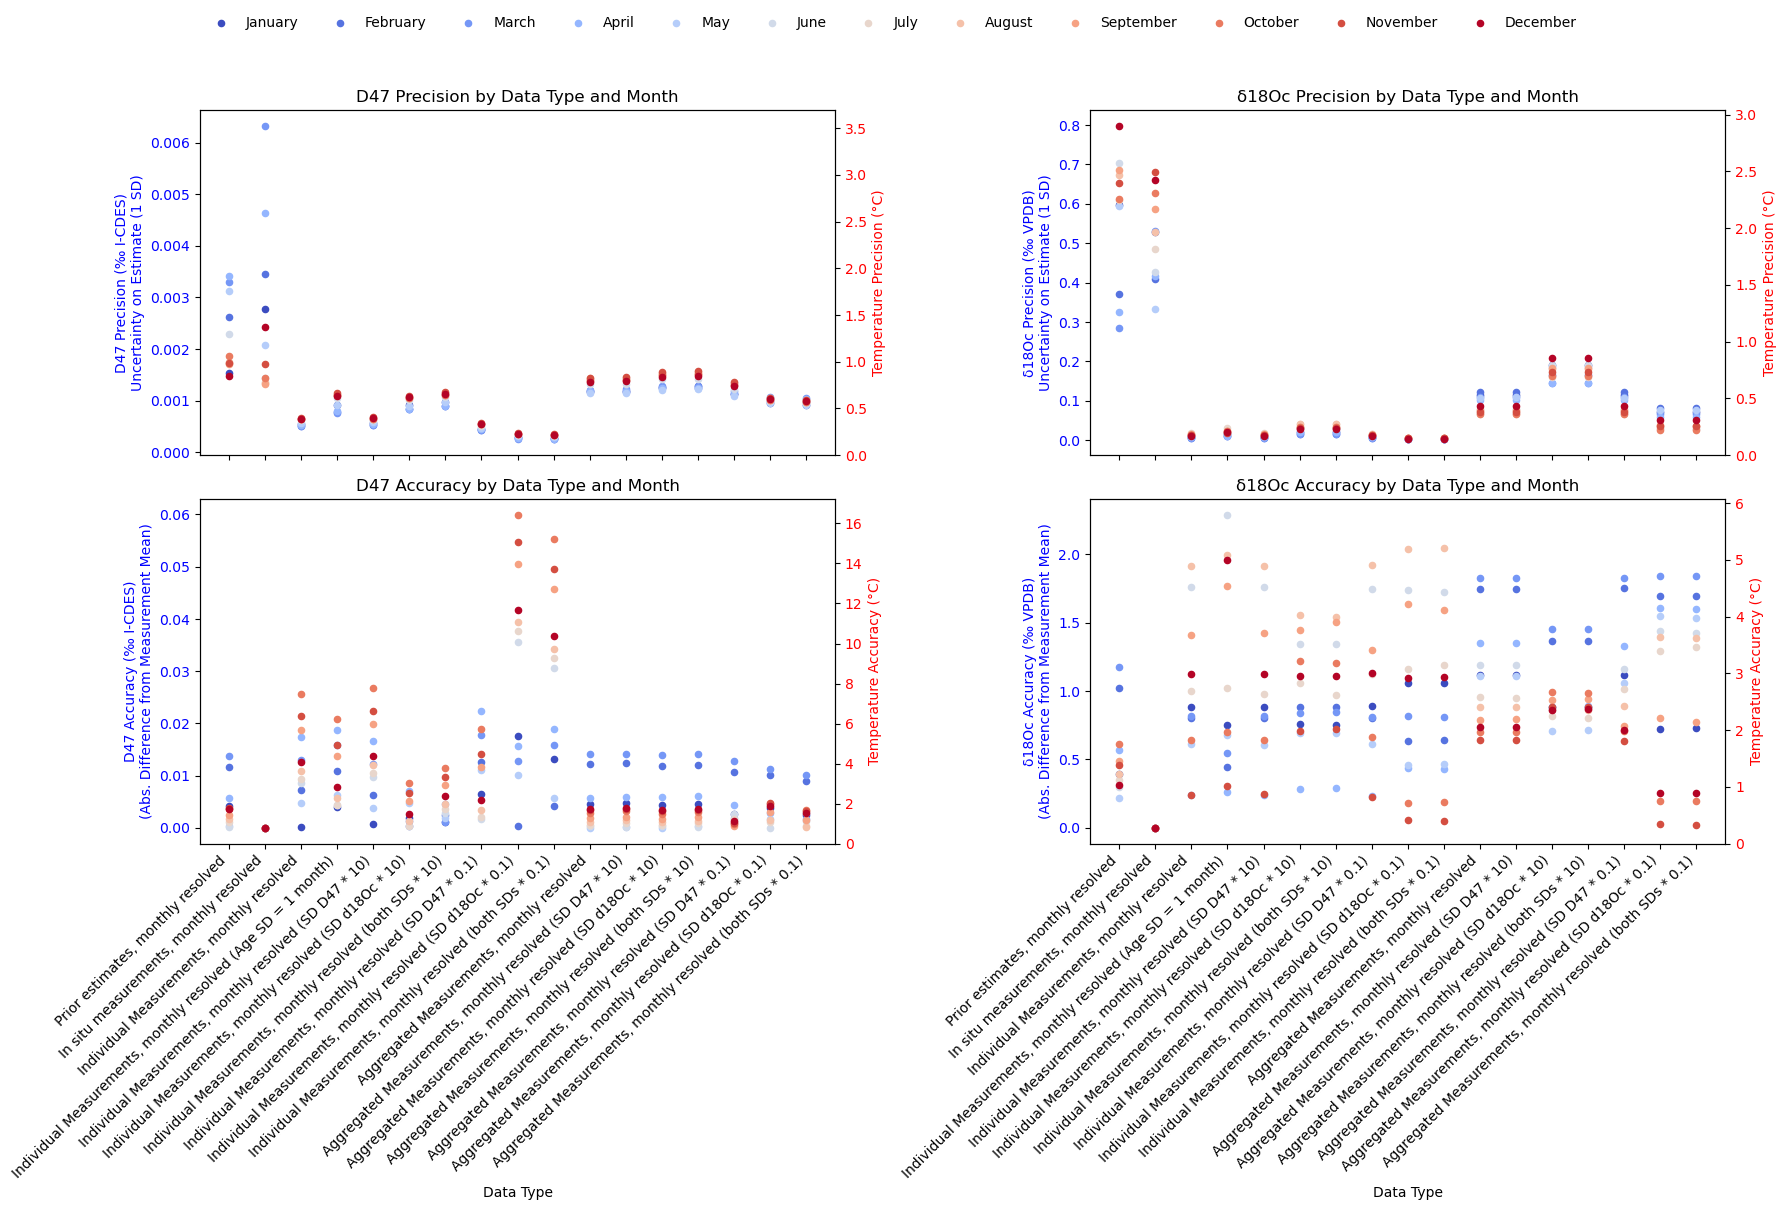

In [57]:
fig, ((ax2, ax4), (ax1, ax3)) = plt.subplots(
    2, 2, figsize=(18, 12), sharex='col'
)
fig.subplots_adjust(hspace=0.1, wspace=0.25)  # reduce vertical & horizontal spacing

# Define a colormap across all months
cmap = plt.cm.coolwarm
colors = [cmap(i / (len(months)-1)) for i in range(len(months))]
color_dict = dict(zip(months, colors))

# ---------------------------------------------------------
# --- Accuracy Plot (Bottom Left: D47) ---
for month in months:
    ax1.scatter(accuracy_D47_monthly.index, accuracy_D47_monthly[f"{month} D47 Mean"], s=20, label=month, color=color_dict[month])

ax1.set_xticks(accuracy_D47_monthly.index)
ax1.set_xticklabels(accuracy_D47_monthly.index, rotation=45, ha="right")
ax1.set_xlabel('Data Type')
ax1.set_ylabel('D47 Accuracy (‰ I-CDES)\n(Abs. Difference from Measurement Mean)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis for temperature
ax1_temp = ax1.twinx()
ax1_temp.set_ylabel('Temperature Accuracy (°C)', color='red')
ax1_temp.tick_params(axis='y', labelcolor='red')
temp_min1 = 0
temp_max1 = np.max(mu_measurement_SST_monthly) - D47c.OGLS23.T47(
    D47=D47c.OGLS23.T47(T=np.mean(mu_measurement_SST_monthly))[0] + 0.05
)[0]
ax1_temp.set_ylim(temp_min1, temp_max1)

ax1.set_title('D47 Accuracy by Data Type and Month')

# ---------------------------------------------------------
# --- Precision Plot (Top Left: D47) ---
for month in months:
    ax2.scatter(precision_D47_monthly.index, precision_D47_monthly[f"{month} D47 Std"], s=20, color=color_dict[month])

ax2.set_ylabel('D47 Precision (‰ I-CDES)\nUncertainty on Estimate (1 SD)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax2_temp = ax2.twinx()
ax2_temp.set_ylabel('Temperature Precision (°C)', color='red')
ax2_temp.tick_params(axis='y', labelcolor='red')
temp_min2 = 0
temp_max2 = np.max(mu_measurement_SST_monthly) - D47c.OGLS23.T47(
    D47=D47c.OGLS23.T47(T=np.mean(mu_measurement_SST_monthly))[0] + 0.006
)[0]
ax2_temp.set_ylim(temp_min2, temp_max2)

ax2.set_title('D47 Precision by Data Type and Month')

# ---------------------------------------------------------
# --- Accuracy Plot (Bottom Right: δ18Oc) ---
for month in months:
    ax3.scatter(accuracy_d18Oc_monthly.index, accuracy_d18Oc_monthly[f"{month} d18Oc Mean"], s=20, label=month, color=color_dict[month])

ax3.set_xticks(accuracy_d18Oc_monthly.index)
ax3.set_xticklabels(accuracy_d18Oc_monthly.index, rotation=45, ha="right")
ax3.set_xlabel('Data Type')
ax3.set_ylabel('δ18Oc Accuracy (‰ VPDB)\n(Abs. Difference from Measurement Mean)', color='blue')
ax3.tick_params(axis='y', labelcolor='blue')
ax3.set_title('δ18Oc Accuracy by Data Type and Month')

# Secondary axis for temperature, based on d18Oc-temperature conversion used above
ax3_temp = ax3.twinx()
ax3_temp.set_ylabel('Temperature Accuracy (°C)', color='red')
ax3_temp.tick_params(axis='y', labelcolor='red')
temp_min3 = 0
temp_max3 = np.max(mu_measurement_SST_monthly) - (20.6 - 4.34 * (((20.6 - np.max(mu_measurement_SST_monthly)) / 4.34  - 0.27) + 1.4 + 0.27))
ax3_temp.set_ylim(temp_min3, temp_max3)

# ---------------------------------------------------------
# --- Precision Plot (Top Right: δ18Oc) ---
for month in months:
    ax4.scatter(precision_d18Oc_monthly.index, precision_d18Oc_monthly[f"{month} d18Oc Std"], s=20, color=color_dict[month])

ax4.set_ylabel('δ18Oc Precision (‰ VPDB)\nUncertainty on Estimate (1 SD)', color='blue')
ax4.tick_params(axis='y', labelcolor='blue')
ax4.set_title('δ18Oc Precision by Data Type and Month')

# Secondary axis for temperature, based on d18Oc-temperature conversion used above
ax4_temp = ax4.twinx()
ax4_temp.set_ylabel('Temperature Precision (°C)', color='red')
ax4_temp.tick_params(axis='y', labelcolor='red')
temp_min4 = 0
temp_max4 = np.max(mu_measurement_SST_monthly) - (20.6 - 4.34 * (((20.6 - np.max(mu_measurement_SST_monthly)) / 4.34  - 0.27) + 0.7 + 0.27))
ax4_temp.set_ylim(temp_min4, temp_max4)

# ---------------------------------------------------------
# Shared legend above all plots
handles1, labels1 = ax1.get_legend_handles_labels()
fig.legend(handles1, labels1,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.01),
           ncol=len(months),
           frameon=False)

# Hide top x-axis labels
ax2.tick_params(axis='x', labelbottom=False)
ax4.tick_params(axis='x', labelbottom=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for legend
plt.show()


### Combined plot of measurements, priors and posteriors with precision uncertainties

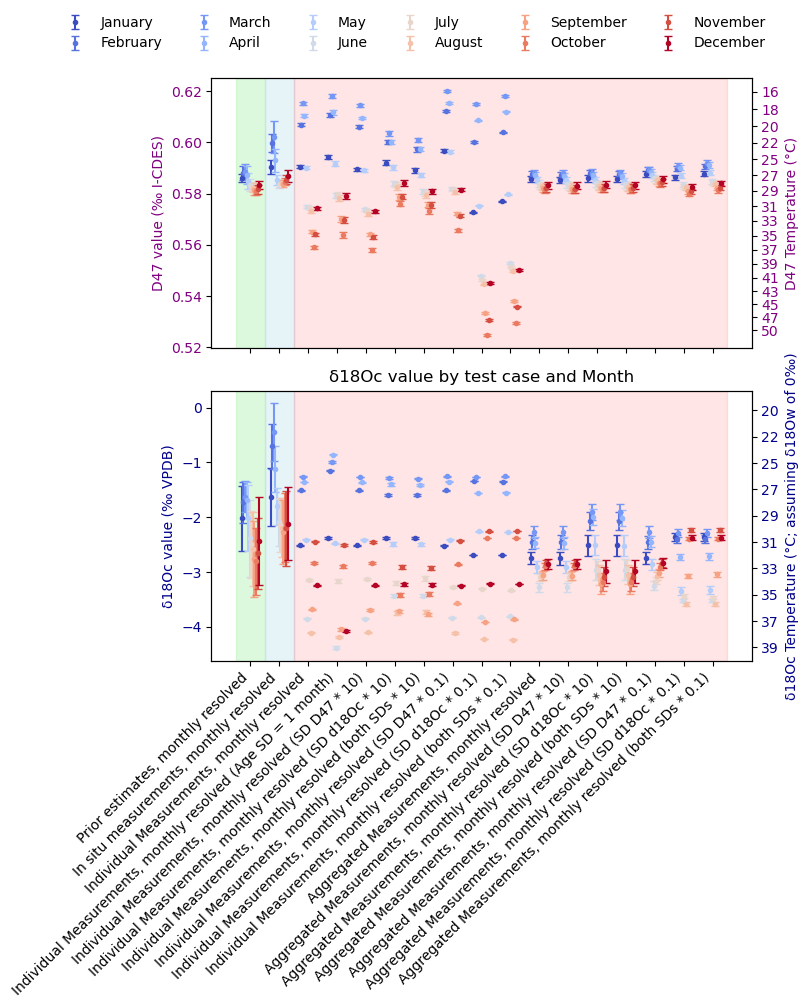

In [58]:
fig, (ax1, ax3) = plt.subplots(
    2, 1, figsize=(8, 10), sharex='col'
)
fig.subplots_adjust(hspace=0.1, wspace=0.25)  # reduce vertical & horizontal spacing

# Define a colormap across all months
cmap = plt.cm.coolwarm
colors = [cmap(i / (len(months)-1)) for i in range(len(months))]
color_dict = dict(zip(months, colors))

# Define offsets for x-axis to avoid overlapping error bars
x_offsets = np.linspace(-0.3, 0.3, len(months))

# Define x values for each data type
x_values = np.arange(len(all_uncertainty_test_table_df_monthly.index))

# --- D47 plot ---
for month in months:
    ax1.errorbar(
        x = x_values + x_offsets[months.index(month)],
        y = all_uncertainty_test_table_df_monthly[f"{month} D47 Mean"],
        yerr = all_uncertainty_test_table_df_monthly[f"{month} D47 Std"],
        capsize = 3,
        fmt='.',
        label=month,
        color=color_dict[month]
    )
# Add light green rectangle to highlight prior
ax1.add_patch(
    Rectangle(
        (-0.5, ax1.get_ylim()[0]),  # (x,y)
        1,                          # width
        ax1.get_ylim()[1] - ax1.get_ylim()[0],  # height
        color='lightgreen',
        alpha=0.3,
    )
)
# Add light blue rectangle to highlight measurement
ax1.add_patch(
    Rectangle(
        (0.5, ax1.get_ylim()[0]),  # (x,y)
        1,                          # width
        ax1.get_ylim()[1] - ax1.get_ylim()[0],  # height
        color='lightblue',
        alpha=0.3,
    )
)
# Add light red rectangle to highlight posteriors
ax1.add_patch(
    Rectangle(
        (1.5, ax1.get_ylim()[0]),  # (x,y)
        15,         # width
        ax1.get_ylim()[1] - ax1.get_ylim()[0],  # height
        color='red',
        alpha=0.1,
    )
)
ax1.set_xticks(x_values)
ax1.set_xticklabels(all_uncertainty_test_table_df_monthly.index, rotation=45, ha="right")
# ax1.set_xlabel('test case')
ax1.set_ylabel('D47 value (‰ I-CDES)', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# Secondary axis for temperature
ax1_temp = ax1.twinx()
ax1_temp.set_ylabel('D47 Temperature (°C)', color='purple')
ax1_temp.tick_params(axis='y', labelcolor='purple')
ax1_temp.set_yticks(
    ticks = D47c.OGLS23.T47(T = np.linspace(0, 50, 25))[0],
    labels = np.linspace(0, 50, 25).astype(int)
)
ax1_temp.set_ylim(ax1.get_ylim())

# --- δ18Oc Plot ---

for month in months:
    ax3.errorbar(
        x = x_values + x_offsets[months.index(month)],
        y = all_uncertainty_test_table_df_monthly[f"{month} d18Oc Mean"],
        yerr = all_uncertainty_test_table_df_monthly[f"{month} d18Oc Std"],
        capsize = 3,
        fmt='.',
        label=month,
        color=color_dict[month]
    )
# Add light green rectangle to highlight prior
ax3.add_patch(
    Rectangle(
        (-0.5, ax3.get_ylim()[0]),  # (x,y)
        1,                          # width
        ax3.get_ylim()[1] - ax3.get_ylim()[0],  # height
        color='lightgreen',
        alpha=0.3,
    )
)
# Add light blue rectangle to highlight measurement
ax3.add_patch(
    Rectangle(
        (0.5, ax3.get_ylim()[0]),  # (x,y)
        1,                          # width
        ax3.get_ylim()[1] - ax3.get_ylim()[0],  # height
        color='lightblue',
        alpha=0.3,
    )
)
# Add light red rectangle to highlight posteriors
ax3.add_patch(
    Rectangle(
        (1.5, ax3.get_ylim()[0]),  # (x,y)
        15,         # width
        ax3.get_ylim()[1] - ax3.get_ylim()[0],  # height
        color='red',
        alpha=0.1,
    )
)
ax3.set_xticks(x_values)
ax3.set_xticklabels(all_uncertainty_test_table_df_monthly.index, rotation=45, ha="right")
ax3.set_ylabel('δ18Oc value (‰ VPDB)', color='darkblue')
ax3.tick_params(axis='y', labelcolor='darkblue')

# Secondary axis for temperature, based on d18Oc-temperature conversion used above
ax3_temp = ax3.twinx()
ax3_temp.set_ylabel('δ18Oc Temperature (°C; assuming δ18Ow of 0‰)', color='darkblue')
ax3_temp.tick_params(axis='y', labelcolor='darkblue')
ax3_temp.set_yticks(
    ticks = ((20.6 - np.linspace(0, 50, 25)) / 4.34  - 0.27) + 0 + 0.27,
    labels = np.linspace(0, 50, 25).astype(int)
)
ax3_temp.set_ylim(ax3.get_ylim())
ax3.set_title('δ18Oc value by test case and Month')

# ---------------------------------------------------------
# Shared legend above all plots
handles1, labels1 = ax1.get_legend_handles_labels()
fig.legend(handles1, labels1,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.01),
           ncol=len(months) / 2,
           frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for legend
plt.show()

### Aggregate statistics on posterior outcomes on SST and SAT for all cases

In [59]:
# Prepare the data for the table
data_monthly = {
    "Data Type": [
        "Prior estimates, monthly resolved",
        "In situ measurements, monthly resolved",
        "Individual Measurements, monthly resolved",
        "Individual Measurements, monthly resolved (Age SD = 1 month)",
        "Individual Measurements, monthly resolved (SD D47 * 10)",
        "Individual Measurements, monthly resolved (SD d18Oc * 10)",
        "Individual Measurements, monthly resolved (both SDs * 10)",
        "Individual Measurements, monthly resolved (SD D47 * 0.1)",
        "Individual Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Individual Measurements, monthly resolved (both SDs * 0.1)",
        "Aggregated Measurements, monthly resolved",
        "Aggregated Measurements, monthly resolved (SD D47 * 10)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 10)",
        "Aggregated Measurements, monthly resolved (both SDs * 10)",
        "Aggregated Measurements, monthly resolved (SD D47 * 0.1)",
        "Aggregated Measurements, monthly resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, monthly resolved (both SDs * 0.1)"
    ]
}

data_seasonal = {
    "Data Type": [
        "Prior estimates, seasonally resolved",
        "In situ measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved",
        "Individual Measurements, seasonally resolved (Age SD = 1 month)",
        "Individual Measurements, seasonally resolved (SD D47 * 10)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 10)",
        "Individual Measurements, seasonally resolved (both SDs * 10)",
        "Individual Measurements, seasonally resolved (SD D47 * 0.1)",
        "Individual Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Individual Measurements, seasonally resolved (both SDs * 0.1)",
        "Aggregated Measurements, seasonally resolved",
        "Aggregated Measurements, seasonally resolved (SD D47 * 10)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 10)",
        "Aggregated Measurements, seasonally resolved (both SDs * 10)",
        "Aggregated Measurements, seasonally resolved (SD D47 * 0.1)",
        "Aggregated Measurements, seasonally resolved (SD d18Oc * 0.1)",
        "Aggregated Measurements, seasonally resolved (both SDs * 0.1)"
    ]
}

# Add monthly means and standard deviations to the data dictionary
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
seasons = ["winter", "spring", "summer", "autumn"]

# Process and rename the means and standard deviations for each data source
SST_means_prior_monthly = D47c.OGLS23.T47(D47 = mu_prior_SST_D47_monthly_original, sD47 = cov_prior_SST_D47_monthly_original, return_covar = True)[0]
SST_stds_prior_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_prior_SST_D47_monthly_original, sD47 = cov_prior_SST_D47_monthly_original, return_covar = True)[1]))

SST_means_individual_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC, sD47 = cov_post_SST_D47_monthlySC, return_covar = True)[0]
SST_stds_individual_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC, sD47 = cov_post_SST_D47_monthlySC, return_covar = True)[1]))
SST_means_individual_monthly_timeSD = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_timeSD, sD47 = cov_post_SST_D47_monthlySC_timeSD, return_covar = True)[0]
SST_stds_individual_monthly_timeSD = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_timeSD, sD47 = cov_post_SST_D47_monthlySC_timeSD, return_covar = True)[1]))
SST_means_individual_hu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_HU_D47, sD47 = cov_post_SST_D47_monthlySC_HU_D47, return_covar = True)[0]
SST_stds_individual_hu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_HU_D47, sD47 = cov_post_SST_D47_monthlySC_HU_D47, return_covar = True)[1]))
SST_means_individual_hu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_HU_d18O, sD47 = cov_post_SST_D47_monthlySC_HU_d18O, return_covar = True)[0]
SST_stds_individual_hu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_HU_d18O, sD47 = cov_post_SST_D47_monthlySC_HU_d18O, return_covar = True)[1]))
SST_means_individual_hu_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_HU, sD47 = cov_post_SST_D47_monthlySC_HU, return_covar = True)[0]
SST_stds_individual_hu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_HU, sD47 = cov_post_SST_D47_monthlySC_HU, return_covar = True)[1]))
SST_means_individual_lu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_LU_D47, sD47 = cov_post_SST_D47_monthlySC_LU_D47, return_covar = True)[0]
SST_stds_individual_lu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_LU_D47, sD47 = cov_post_SST_D47_monthlySC_LU_D47, return_covar = True)[1]))
SST_means_individual_lu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_LU_d18O, sD47 = cov_post_SST_D47_monthlySC_LU_d18O, return_covar = True)[0]
SST_stds_individual_lu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_LU_d18O, sD47 = cov_post_SST_D47_monthlySC_LU_d18O, return_covar = True)[1]))
SST_means_individual_lu_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_LU, sD47 = cov_post_SST_D47_monthlySC_LU, return_covar = True)[0]
SST_stds_individual_lu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthlySC_LU, sD47 = cov_post_SST_D47_monthlySC_LU, return_covar = True)[1]))

SST_means_aggregated_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated, sD47 = cov_post_SST_D47_monthly_aggregated, return_covar = True)[0]
SST_stds_aggregated_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated, sD47 = cov_post_SST_D47_monthly_aggregated, return_covar = True)[1]))
SST_means_aggregated_hu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_HU_D47, sD47 = cov_post_SST_D47_monthly_aggregated_HU_D47, return_covar = True)[0]
SST_stds_aggregated_hu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_HU_D47, sD47 = cov_post_SST_D47_monthly_aggregated_HU_D47, return_covar = True)[1]))
SST_means_aggregated_hu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_HU_d18O, sD47 = cov_post_SST_D47_monthly_aggregated_HU_d18O, return_covar = True)[0]
SST_stds_aggregated_hu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_HU_d18O, sD47 = cov_post_SST_D47_monthly_aggregated_HU_d18O, return_covar = True)[1]))
SST_means_aggregated_hu_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_HU, sD47 = cov_post_SST_D47_monthly_aggregated_HU, return_covar = True)[0]
SST_stds_aggregated_hu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_HU, sD47 = cov_post_SST_D47_monthly_aggregated_HU, return_covar = True)[1]))
SST_means_aggregated_lu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_LU_D47, sD47 = cov_post_SST_D47_monthly_aggregated_LU_D47, return_covar = True)[0]
SST_stds_aggregated_lu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_LU_D47, sD47 = cov_post_SST_D47_monthly_aggregated_LU_D47, return_covar = True)[1]))
SST_means_aggregated_lu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_LU_d18O, sD47 = cov_post_SST_D47_monthly_aggregated_LU_d18O, return_covar = True)[0]
SST_stds_aggregated_lu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_LU_d18O, sD47 = cov_post_SST_D47_monthly_aggregated_LU_d18O, return_covar = True)[1]))
SST_means_aggregated_lu_monthly = D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_LU, sD47 = cov_post_SST_D47_monthly_aggregated_LU, return_covar = True)[0]
SST_stds_aggregated_lu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_monthly_aggregated_LU, sD47 = cov_post_SST_D47_monthly_aggregated_LU, return_covar = True)[1]))

SAT_means_prior_monthly = D47c.OGLS23.T47(D47 = mu_prior_SAT_D47_monthly_original, sD47 = cov_prior_SAT_D47_monthly_original, return_covar = True)[0]
SAT_stds_prior_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_prior_SAT_D47_monthly_original, sD47 = cov_prior_SAT_D47_monthly_original, return_covar = True)[1]))

SAT_means_individual_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC, sD47 = cov_post_SAT_D47_monthlySC, return_covar = True)[0]
SAT_stds_individual_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC, sD47 = cov_post_SAT_D47_monthlySC, return_covar = True)[1]))
SAT_means_individual_monthly_timeSD = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_timeSD, sD47 = cov_post_SAT_D47_monthlySC_timeSD, return_covar = True)[0]
SAT_stds_individual_monthly_timeSD = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_timeSD, sD47 = cov_post_SAT_D47_monthlySC_timeSD, return_covar = True)[1]))
SAT_means_individual_hu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_HU_D47, sD47 = cov_post_SAT_D47_monthlySC_HU_D47, return_covar = True)[0]
SAT_stds_individual_hu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_HU_D47, sD47 = cov_post_SAT_D47_monthlySC_HU_D47, return_covar = True)[1]))
SAT_means_individual_hu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_HU_d18O, sD47 = cov_post_SAT_D47_monthlySC_HU_d18O, return_covar = True)[0]
SAT_stds_individual_hu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_HU_d18O, sD47 = cov_post_SAT_D47_monthlySC_HU_d18O, return_covar = True)[1]))
SAT_means_individual_hu_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_HU, sD47 = cov_post_SAT_D47_monthlySC_HU, return_covar = True)[0]
SAT_stds_individual_hu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_HU, sD47 = cov_post_SAT_D47_monthlySC_HU, return_covar = True)[1]))
SAT_means_individual_lu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_LU_D47, sD47 = cov_post_SAT_D47_monthlySC_LU_D47, return_covar = True)[0]
SAT_stds_individual_lu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_LU_D47, sD47 = cov_post_SAT_D47_monthlySC_LU_D47, return_covar = True)[1]))
SAT_means_individual_lu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_LU_d18O, sD47 = cov_post_SAT_D47_monthlySC_LU_d18O, return_covar = True)[0]
SAT_stds_individual_lu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_LU_d18O, sD47 = cov_post_SAT_D47_monthlySC_LU_d18O, return_covar = True)[1]))
SAT_means_individual_lu_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_LU, sD47 = cov_post_SAT_D47_monthlySC_LU, return_covar = True)[0]
SAT_stds_individual_lu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthlySC_LU, sD47 = cov_post_SAT_D47_monthlySC_LU, return_covar = True)[1]))

SAT_means_aggregated_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated, sD47 = cov_post_SAT_D47_monthly_aggregated, return_covar = True)[0]
SAT_stds_aggregated_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated, sD47 = cov_post_SAT_D47_monthly_aggregated, return_covar = True)[1]))
SAT_means_aggregated_hu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_HU_D47, sD47 = cov_post_SAT_D47_monthly_aggregated_HU_D47, return_covar = True)[0]
SAT_stds_aggregated_hu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_HU_D47, sD47 = cov_post_SAT_D47_monthly_aggregated_HU_D47, return_covar = True)[1]))
SAT_means_aggregated_hu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_HU_d18O, sD47 = cov_post_SAT_D47_monthly_aggregated_HU_d18O, return_covar = True)[0]
SAT_stds_aggregated_hu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_HU_d18O, sD47 = cov_post_SAT_D47_monthly_aggregated_HU_d18O, return_covar = True)[1]))
SAT_means_aggregated_hu_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_HU, sD47 = cov_post_SAT_D47_monthly_aggregated_HU, return_covar = True)[0]
SAT_stds_aggregated_hu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_HU, sD47 = cov_post_SAT_D47_monthly_aggregated_HU, return_covar = True)[1]))
SAT_means_aggregated_lu_d47_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_LU_D47, sD47 = cov_post_SAT_D47_monthly_aggregated_LU_D47, return_covar = True)[0]
SAT_stds_aggregated_lu_d47_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_LU_D47, sD47 = cov_post_SAT_D47_monthly_aggregated_LU_D47, return_covar = True)[1]))
SAT_means_aggregated_lu_d18o_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_LU_d18O, sD47 = cov_post_SAT_D47_monthly_aggregated_LU_d18O, return_covar = True)[0]
SAT_stds_aggregated_lu_d18o_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_LU_d18O, sD47 = cov_post_SAT_D47_monthly_aggregated_LU_d18O, return_covar = True)[1]))
SAT_means_aggregated_lu_monthly = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_LU, sD47 = cov_post_SAT_D47_monthly_aggregated_LU, return_covar = True)[0]
SAT_stds_aggregated_lu_monthly = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_monthly_aggregated_LU, sD47 = cov_post_SAT_D47_monthly_aggregated_LU, return_covar = True)[1]))

SST_means_prior_seasonal = D47c.OGLS23.T47(D47 = mu_prior_SST_D47_seasonal_original, sD47 = cov_prior_SST_D47_seasonal_original, return_covar = True)[0]
SST_stds_prior_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_prior_SST_D47_seasonal_original, sD47 = cov_prior_SST_D47_seasonal_original, return_covar = True)[1]))

SST_means_individual_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC, sD47 = cov_post_SST_D47_seasonalSC, return_covar = True)[0]
SST_stds_individual_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC, sD47 = cov_post_SST_D47_seasonalSC, return_covar = True)[1]))
SST_means_individual_seasonal_timeSD = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_timeSD, sD47 = cov_post_SST_D47_seasonalSC_timeSD, return_covar = True)[0]
SST_stds_individual_seasonal_timeSD = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_timeSD, sD47 = cov_post_SST_D47_seasonalSC_timeSD, return_covar = True)[1]))
SST_means_individual_hu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_HU_D47, sD47 = cov_post_SST_D47_seasonalSC_HU_D47, return_covar = True)[0]
SST_stds_individual_hu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_HU_D47, sD47 = cov_post_SST_D47_seasonalSC_HU_D47, return_covar = True)[1]))
SST_means_individual_hu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_HU_d18O, sD47 = cov_post_SST_D47_seasonalSC_HU_d18O, return_covar = True)[0]
SST_stds_individual_hu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_HU_d18O, sD47 = cov_post_SST_D47_seasonalSC_HU_d18O, return_covar = True)[1]))
SST_means_individual_hu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_HU, sD47 = cov_post_SST_D47_seasonalSC_HU, return_covar = True)[0]
SST_stds_individual_hu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_HU, sD47 = cov_post_SST_D47_seasonalSC_HU, return_covar = True)[1]))
SST_means_individual_lu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_LU_D47, sD47 = cov_post_SST_D47_seasonalSC_LU_D47, return_covar = True)[0]
SST_stds_individual_lu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_LU_D47, sD47 = cov_post_SST_D47_seasonalSC_LU_D47, return_covar = True)[1]))
SST_means_individual_lu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_LU_d18O, sD47 = cov_post_SST_D47_seasonalSC_LU_d18O, return_covar = True)[0]
SST_stds_individual_lu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_LU_d18O, sD47 = cov_post_SST_D47_seasonalSC_LU_d18O, return_covar = True)[1]))
SST_means_individual_lu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_LU, sD47 = cov_post_SST_D47_seasonalSC_LU, return_covar = True)[0]
SST_stds_individual_lu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonalSC_LU, sD47 = cov_post_SST_D47_seasonalSC_LU, return_covar = True)[1]))

SST_means_aggregated_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated, sD47 = cov_post_SST_D47_seasonal_aggregated, return_covar = True)[0]
SST_stds_aggregated_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated, sD47 = cov_post_SST_D47_seasonal_aggregated, return_covar = True)[1]))
SST_means_aggregated_hu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_HU_D47, sD47 = cov_post_SST_D47_seasonal_aggregated_HU_D47, return_covar = True)[0]
SST_stds_aggregated_hu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_HU_D47, sD47 = cov_post_SST_D47_seasonal_aggregated_HU_D47, return_covar = True)[1]))
SST_means_aggregated_hu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_HU_d18O, sD47 = cov_post_SST_D47_seasonal_aggregated_HU_d18O, return_covar = True)[0]
SST_stds_aggregated_hu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_HU_d18O, sD47 = cov_post_SST_D47_seasonal_aggregated_HU_d18O, return_covar = True)[1]))
SST_means_aggregated_hu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_HU, sD47 = cov_post_SST_D47_seasonal_aggregated_HU, return_covar = True)[0]
SST_stds_aggregated_hu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_HU, sD47 = cov_post_SST_D47_seasonal_aggregated_HU, return_covar = True)[1]))
SST_means_aggregated_lu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_LU_D47, sD47 = cov_post_SST_D47_seasonal_aggregated_LU_D47, return_covar = True)[0]
SST_stds_aggregated_lu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_LU_D47, sD47 = cov_post_SST_D47_seasonal_aggregated_LU_D47, return_covar = True)[1]))
SST_means_aggregated_lu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_LU_d18O, sD47 = cov_post_SST_D47_seasonal_aggregated_LU_d18O, return_covar = True)[0]
SST_stds_aggregated_lu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_LU_d18O, sD47 = cov_post_SST_D47_seasonal_aggregated_LU_d18O, return_covar = True)[1]))
SST_means_aggregated_lu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_LU, sD47 = cov_post_SST_D47_seasonal_aggregated_LU, return_covar = True)[0]
SST_stds_aggregated_lu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SST_D47_seasonal_aggregated_LU, sD47 = cov_post_SST_D47_seasonal_aggregated_LU, return_covar = True)[1]))

SAT_means_prior_seasonal = D47c.OGLS23.T47(D47 = mu_prior_SAT_D47_seasonal_original, sD47 = cov_prior_SAT_D47_seasonal_original, return_covar = True)[0]
SAT_stds_prior_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_prior_SAT_D47_seasonal_original, sD47 = cov_prior_SAT_D47_seasonal_original, return_covar = True)[1]))

SAT_means_individual_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC, sD47 = cov_post_SAT_D47_seasonalSC, return_covar = True)[0]
SAT_stds_individual_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC, sD47 = cov_post_SAT_D47_seasonalSC, return_covar = True)[1]))
SAT_means_individual_seasonal_timeSD = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_timeSD, sD47 = cov_post_SAT_D47_seasonalSC_timeSD, return_covar = True)[0]
SAT_stds_individual_seasonal_timeSD = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_timeSD, sD47 = cov_post_SAT_D47_seasonalSC_timeSD, return_covar = True)[1]))
SAT_means_individual_hu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_HU_D47, sD47 = cov_post_SAT_D47_seasonalSC_HU_D47, return_covar = True)[0]
SAT_stds_individual_hu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_HU_D47, sD47 = cov_post_SAT_D47_seasonalSC_HU_D47, return_covar = True)[1]))
SAT_means_individual_hu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_HU_d18O, sD47 = cov_post_SAT_D47_seasonalSC_HU_d18O, return_covar = True)[0]
SAT_stds_individual_hu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_HU_d18O, sD47 = cov_post_SAT_D47_seasonalSC_HU_d18O, return_covar = True)[1]))
SAT_means_individual_hu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_HU, sD47 = cov_post_SAT_D47_seasonalSC_HU, return_covar = True)[0]
SAT_stds_individual_hu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_HU, sD47 = cov_post_SAT_D47_seasonalSC_HU, return_covar = True)[1]))
SAT_means_individual_lu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_LU_D47, sD47 = cov_post_SAT_D47_seasonalSC_LU_D47, return_covar = True)[0]
SAT_stds_individual_lu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_LU_D47, sD47 = cov_post_SAT_D47_seasonalSC_LU_D47, return_covar = True)[1]))
SAT_means_individual_lu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_LU_d18O, sD47 = cov_post_SAT_D47_seasonalSC_LU_d18O, return_covar = True)[0]
SAT_stds_individual_lu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_LU_d18O, sD47 = cov_post_SAT_D47_seasonalSC_LU_d18O, return_covar = True)[1]))
SAT_means_individual_lu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_LU, sD47 = cov_post_SAT_D47_seasonalSC_LU, return_covar = True)[0]
SAT_stds_individual_lu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonalSC_LU, sD47 = cov_post_SAT_D47_seasonalSC_LU, return_covar = True)[1]))

SAT_means_aggregated_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated, sD47 = cov_post_SAT_D47_seasonal_aggregated, return_covar = True)[0]
SAT_stds_aggregated_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated, sD47 = cov_post_SAT_D47_seasonal_aggregated, return_covar = True)[1]))
SAT_means_aggregated_hu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_HU_D47, sD47 = cov_post_SAT_D47_seasonal_aggregated_HU_D47, return_covar = True)[0]
SAT_stds_aggregated_hu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_HU_D47, sD47 = cov_post_SAT_D47_seasonal_aggregated_HU_D47, return_covar = True)[1]))
SAT_means_aggregated_hu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_HU_d18O, sD47 = cov_post_SAT_D47_seasonal_aggregated_HU_d18O, return_covar = True)[0]
SAT_stds_aggregated_hu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_HU_d18O, sD47 = cov_post_SAT_D47_seasonal_aggregated_HU_d18O, return_covar = True)[1]))
SAT_means_aggregated_hu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_HU, sD47 = cov_post_SAT_D47_seasonal_aggregated_HU, return_covar = True)[0]
SAT_stds_aggregated_hu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_HU, sD47 = cov_post_SAT_D47_seasonal_aggregated_HU, return_covar = True)[1]))
SAT_means_aggregated_lu_d47_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_LU_D47, sD47 = cov_post_SAT_D47_seasonal_aggregated_LU_D47, return_covar = True)[0]
SAT_stds_aggregated_lu_d47_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_LU_D47, sD47 = cov_post_SAT_D47_seasonal_aggregated_LU_D47, return_covar = True)[1]))
SAT_means_aggregated_lu_d18o_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_LU_d18O, sD47 = cov_post_SAT_D47_seasonal_aggregated_LU_d18O, return_covar = True)[0]
SAT_stds_aggregated_lu_d18o_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_LU_d18O, sD47 = cov_post_SAT_D47_seasonal_aggregated_LU_d18O, return_covar = True)[1]))
SAT_means_aggregated_lu_seasonal = D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_LU, sD47 = cov_post_SAT_D47_seasonal_aggregated_LU, return_covar = True)[0]
SAT_stds_aggregated_lu_seasonal = np.sqrt(np.diag(D47c.OGLS23.T47(D47 = mu_post_SAT_D47_seasonal_aggregated_LU, sD47 = cov_post_SAT_D47_seasonal_aggregated_LU, return_covar = True)[1]))

# Combine all means and standard deviations into the data structure
all_SST_means_monthly = [
    SST_means_prior_monthly,
    mu_measurement_SST_monthly,
    SST_means_individual_monthly,
    SST_means_individual_monthly_timeSD,
    SST_means_individual_hu_d47_monthly,
    SST_means_individual_hu_d18o_monthly,
    SST_means_individual_hu_monthly,
    SST_means_individual_lu_d47_monthly,
    SST_means_individual_lu_d18o_monthly,
    SST_means_individual_lu_monthly,
    SST_means_aggregated_monthly,
    SST_means_aggregated_hu_d47_monthly,
    SST_means_aggregated_hu_d18o_monthly,
    SST_means_aggregated_hu_monthly,
    SST_means_aggregated_lu_d47_monthly,
    SST_means_aggregated_lu_d18o_monthly,
    SST_means_aggregated_lu_monthly
]
all_SST_stds_monthly = [
    SST_stds_prior_monthly,
    std_measurement_SST_monthly,
    SST_stds_individual_monthly,
    SST_stds_individual_monthly_timeSD,
    SST_stds_individual_hu_d47_monthly,
    SST_stds_individual_hu_d18o_monthly,
    SST_stds_individual_hu_monthly,
    SST_stds_individual_lu_d47_monthly,
    SST_stds_individual_lu_d18o_monthly,
    SST_stds_individual_lu_monthly,
    SST_stds_aggregated_monthly,
    SST_stds_aggregated_hu_d47_monthly,
    SST_stds_aggregated_hu_d18o_monthly,
    SST_stds_aggregated_hu_monthly,
    SST_stds_aggregated_lu_d47_monthly,
    SST_stds_aggregated_lu_d18o_monthly,
    SST_stds_aggregated_lu_monthly
]

all_SAT_means_monthly = [
    SAT_means_prior_monthly,
    mu_measurement_SAT_monthly,
    SAT_means_individual_monthly,
    SAT_means_individual_monthly_timeSD,
    SAT_means_individual_hu_d47_monthly,
    SAT_means_individual_hu_d18o_monthly,
    SAT_means_individual_hu_monthly,
    SAT_means_individual_lu_d47_monthly,
    SAT_means_individual_lu_d18o_monthly,
    SAT_means_individual_lu_monthly,
    SAT_means_aggregated_monthly,
    SAT_means_aggregated_hu_d47_monthly,
    SAT_means_aggregated_hu_d18o_monthly,
    SAT_means_aggregated_hu_monthly,
    SAT_means_aggregated_lu_d47_monthly,
    SAT_means_aggregated_lu_d18o_monthly,
    SAT_means_aggregated_lu_monthly
]
all_SAT_stds_monthly = [
    SAT_stds_prior_monthly,
    std_measurement_SAT_monthly,
    SAT_stds_individual_monthly,
    SAT_stds_individual_monthly_timeSD,
    SAT_stds_individual_hu_d47_monthly,
    SAT_stds_individual_hu_d18o_monthly,
    SAT_stds_individual_hu_monthly,
    SAT_stds_individual_lu_d47_monthly,
    SAT_stds_individual_lu_d18o_monthly,
    SAT_stds_individual_lu_monthly,
    SAT_stds_aggregated_monthly,
    SAT_stds_aggregated_hu_d47_monthly,
    SAT_stds_aggregated_hu_d18o_monthly,
    SAT_stds_aggregated_hu_monthly,
    SAT_stds_aggregated_lu_d47_monthly,
    SAT_stds_aggregated_lu_d18o_monthly,
    SAT_stds_aggregated_lu_monthly
]

# Combine all means and standard deviations into the data structure
all_SST_means_seasonal = [
    SST_means_prior_seasonal,
    mu_measurement_SST_seasonal,
    SST_means_individual_seasonal,
    SST_means_individual_seasonal_timeSD,
    SST_means_individual_hu_d47_seasonal,
    SST_means_individual_hu_d18o_seasonal,
    SST_means_individual_hu_seasonal,
    SST_means_individual_lu_d47_seasonal,
    SST_means_individual_lu_d18o_seasonal,
    SST_means_individual_lu_seasonal,
    SST_means_aggregated_seasonal,
    SST_means_aggregated_hu_d47_seasonal,
    SST_means_aggregated_hu_d18o_seasonal,
    SST_means_aggregated_hu_seasonal,
    SST_means_aggregated_lu_d47_seasonal,
    SST_means_aggregated_lu_d18o_seasonal,
    SST_means_aggregated_lu_seasonal
]
all_SST_stds_seasonal = [
    SST_stds_prior_seasonal,
    std_measurement_SST_seasonal,
    SST_stds_individual_seasonal,
    SST_stds_individual_seasonal_timeSD,
    SST_stds_individual_hu_d47_seasonal,
    SST_stds_individual_hu_d18o_seasonal,
    SST_stds_individual_hu_seasonal,
    SST_stds_individual_lu_d47_seasonal,
    SST_stds_individual_lu_d18o_seasonal,
    SST_stds_individual_lu_seasonal,
    SST_stds_aggregated_seasonal,
    SST_stds_aggregated_hu_d47_seasonal,
    SST_stds_aggregated_hu_d18o_seasonal,
    SST_stds_aggregated_hu_seasonal,
    SST_stds_aggregated_lu_d47_seasonal,
    SST_stds_aggregated_lu_d18o_seasonal,
    SST_stds_aggregated_lu_seasonal
]

all_SAT_means_seasonal = [
    SAT_means_prior_seasonal,
    mu_measurement_SAT_seasonal,
    SAT_means_individual_seasonal,
    SAT_means_individual_seasonal_timeSD,
    SAT_means_individual_hu_d47_seasonal,
    SAT_means_individual_hu_d18o_seasonal,
    SAT_means_individual_hu_seasonal,
    SAT_means_individual_lu_d47_seasonal,
    SAT_means_individual_lu_d18o_seasonal,
    SAT_means_individual_lu_seasonal,
    SAT_means_aggregated_seasonal,
    SAT_means_aggregated_hu_d47_seasonal,
    SAT_means_aggregated_hu_d18o_seasonal,
    SAT_means_aggregated_hu_seasonal,
    SAT_means_aggregated_lu_d47_seasonal,
    SAT_means_aggregated_lu_d18o_seasonal,
    SAT_means_aggregated_lu_seasonal
]
all_SAT_stds_seasonal = [
    SAT_stds_prior_seasonal,
    std_measurement_SAT_seasonal,
    SAT_stds_individual_seasonal,
    SAT_stds_individual_seasonal_timeSD,
    SAT_stds_individual_hu_d47_seasonal,
    SAT_stds_individual_hu_d18o_seasonal,
    SAT_stds_individual_hu_seasonal,
    SAT_stds_individual_lu_d47_seasonal,
    SAT_stds_individual_lu_d18o_seasonal,
    SAT_stds_individual_lu_seasonal,
    SAT_stds_aggregated_seasonal,
    SAT_stds_aggregated_hu_d47_seasonal,
    SAT_stds_aggregated_hu_d18o_seasonal,
    SAT_stds_aggregated_hu_seasonal,
    SAT_stds_aggregated_lu_d47_seasonal,
    SAT_stds_aggregated_lu_d18o_seasonal,
    SAT_stds_aggregated_lu_seasonal
]

# Create a dictionary to store all the data
all_temperature_data_monthly = {"Data Type": data_monthly["Data Type"]}
all_temperature_data_seasonal = {"Data Type": data_seasonal["Data Type"]}

# Add SST means and stds
for i, month in enumerate(months):
    all_temperature_data_monthly[f"{month} SST Mean"] = [means[i] for means in all_SST_means_monthly]
    all_temperature_data_monthly[f"{month} SST Std"] = [stds[i] for stds in all_SST_stds_monthly]
    all_temperature_data_monthly[f"{month} SAT Mean"] = [means[i] for means in all_SAT_means_monthly]
    all_temperature_data_monthly[f"{month} SAT Std"] = [stds[i] for stds in all_SAT_stds_monthly]

for i, season in enumerate(seasons):
    all_temperature_data_seasonal[f"{season} SST Mean"] = [means[i] for means in all_SST_means_seasonal]
    all_temperature_data_seasonal[f"{season} SST Std"] = [stds[i] for stds in all_SST_stds_seasonal]
    all_temperature_data_seasonal[f"{season} SAT Mean"] = [means[i] for means in all_SAT_means_seasonal]
    all_temperature_data_seasonal[f"{season} SAT Std"] = [stds[i] for stds in all_SAT_stds_seasonal]

# Create the Pandas DataFrame
all_temperature_uncertainty_test_table_df_monthly = pd.DataFrame(all_temperature_data_monthly)
all_temperature_uncertainty_test_table_df_seasonal = pd.DataFrame(all_temperature_data_seasonal)

# Set the 'Data Type' column as the index
all_temperature_uncertainty_test_table_df_monthly = all_temperature_uncertainty_test_table_df_monthly.set_index("Data Type")
all_temperature_uncertainty_test_table_df_seasonal = all_temperature_uncertainty_test_table_df_seasonal.set_index("Data Type")

# Export the table to a CSV file
all_temperature_uncertainty_test_table_df_monthly.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/all_temperature_uncertainty_test_table_monthly.csv")
all_temperature_uncertainty_test_table_df_seasonal.to_csv("Sensitivity_test_D47_d18Oc_uncertainties/all_temperature_uncertainty_test_table_seasonal.csv")

print("Combined data exported to Sensitivity_test_D47_d18Oc_uncertainties/all_temperature_uncertainty_test_table_monthly.csv")
print("...and Sensitivity_test_D47_d18Oc_uncertainties/all_temperature_uncertainty_test_table_seasonal.csv")

Combined data exported to Sensitivity_test_D47_d18Oc_uncertainties/all_temperature_uncertainty_test_table_monthly.csv
...and Sensitivity_test_D47_d18Oc_uncertainties/all_temperature_uncertainty_test_table_seasonal.csv


### Combined plot of measurements, priors and posteriors with precision uncertainties for temperature

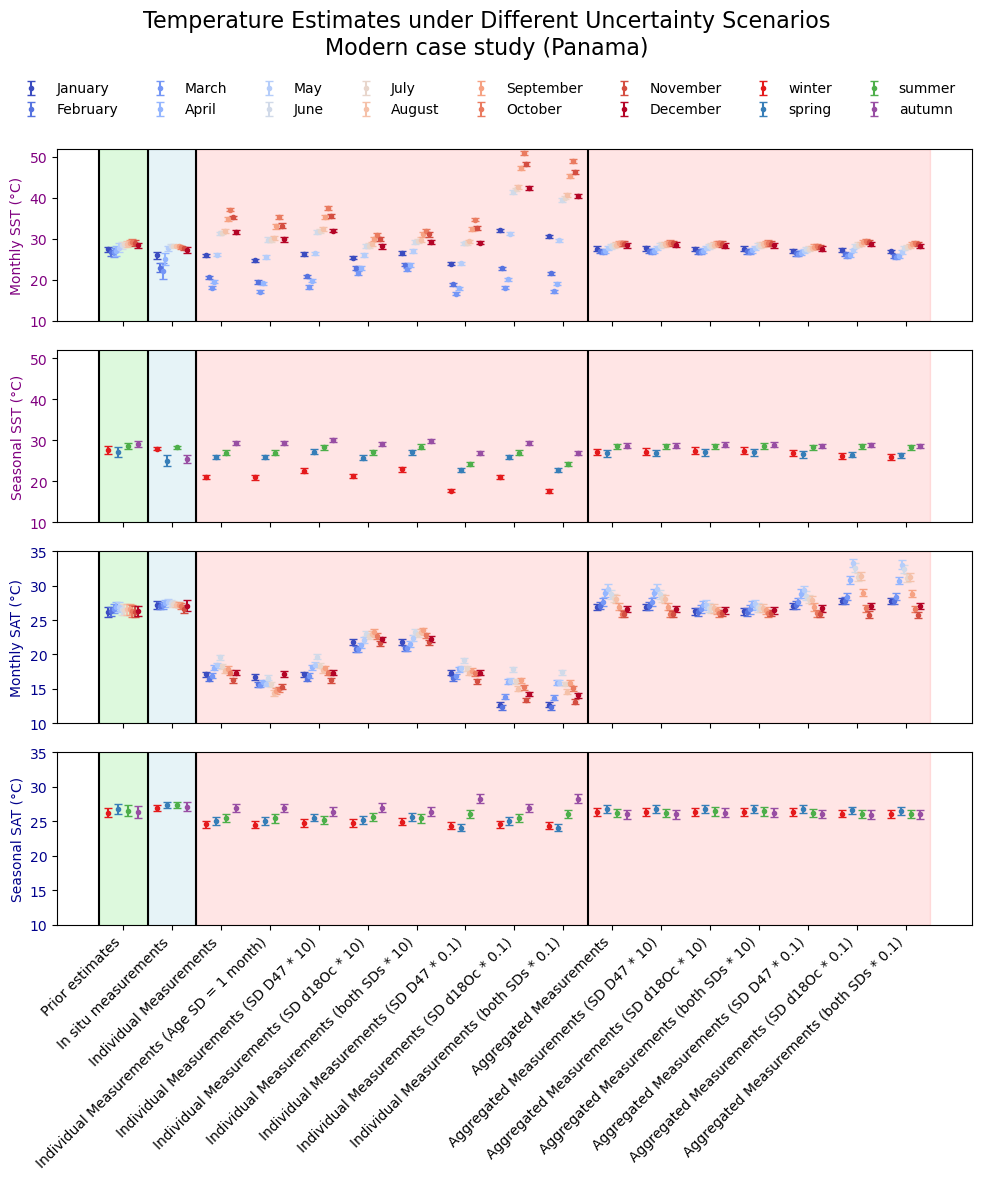

In [60]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1, figsize=(10, 12), sharex='col'
)
fig.subplots_adjust(hspace=0.1, wspace=0.25)  # reduce vertical & horizontal spacing

# Define a colormap across all months
months_cmap = plt.cm.coolwarm
month_colors = [months_cmap(i / (len(months)-1)) for i in range(len(months))]
months_color_dict = dict(zip(months, month_colors))

# Define colormap for seasons
season_cmap = plt.cm.Set1
season_colors = [season_cmap(i) for i in range(len(seasons))]
season_color_dict = dict(zip(seasons, season_colors))

# Define offsets for x-axis to avoid overlapping error bars
x_offsets_months = np.linspace(-0.3, 0.3, len(months))
x_offsets_seasons = np.linspace(-0.3, 0.3, len(seasons))

# Define x values for each data type
x_values = np.arange(len(all_temperature_uncertainty_test_table_df_monthly.index))
x_labels = [str(lbl).replace(", monthly resolved", "") for lbl in all_temperature_uncertainty_test_table_df_monthly.index]

# --- monthly SST plot ---
for month in months:
    ax1.errorbar(
        x = x_values + x_offsets_months[months.index(month)],
        y = all_temperature_uncertainty_test_table_df_monthly[f"{month} SST Mean"],
        yerr = all_temperature_uncertainty_test_table_df_monthly[f"{month} SST Std"],
        capsize = 3,
        fmt='.',
        label=month,
        color=months_color_dict[month]
    )
# Add light green rectangle to highlight prior bounded by lines
ax1.axvline(x=-0.5, color = "black")
ax1.add_patch(
    Rectangle(
        (-0.5, 52),  # (x,y)
        1,                          # width
        10 - 52,  # height
        color='lightgreen',
        alpha=0.3,
    )
)
# Add light blue rectangle to highlight measurement bounded by lines
ax1.axvline(x=0.5, color = "black")
ax1.add_patch(
    Rectangle(
        (0.5, 52),  # (x,y)
        1,                          # width
        10 - 52,  # height
        color='lightblue',
        alpha=0.3,
    )
)
# Add light red rectangle to highlight posteriors bounded by lines
ax1.axvline(x=1.5, color = "black")
ax1.add_patch(
    Rectangle(
        (1.5, 52),  # (x,y)
        15,         # width
        10 - 52,  # height
        color='red',
        alpha=0.1,
    )
)
# Separate individual from aggregated measurements
ax1.axvline(x=9.5, color = "black")
# Plot layout
ax1.set_xticks(x_values)
ax1.set_xticklabels(x_labels, rotation=45, ha="right")
ax1.set_ylabel('Monthly SST (°C)', color='purple')
ax1.set_ylim(10, 52)
ax1.tick_params(axis='y', labelcolor='purple')

# --- seasonal SST plot ---
for season in seasons:
    ax2.errorbar(
        x = x_values + x_offsets_seasons[seasons.index(season)],
        y = all_temperature_uncertainty_test_table_df_seasonal[f"{season} SST Mean"],
        yerr = all_temperature_uncertainty_test_table_df_seasonal[f"{season} SST Std"],
        capsize = 3,
        fmt='.',
        label=season,
        color=season_color_dict[season]
    )
# Add light green rectangle to highlight prior bounded by lines
ax2.axvline(x=-0.5, color = "black")
ax2.add_patch(
    Rectangle(
        (-0.5, 52),  # (x,y)
        1,                          # width
        10 - 52,  # height
        color='lightgreen',
        alpha=0.3,
    )
)
# Add light blue rectangle to highlight measurement bounded by lines
ax2.axvline(x=0.5, color = "black")
ax2.add_patch(
    Rectangle(
        (0.5, 52),  # (x,y)
        1,                          # width
        10 - 52,  # height
        color='lightblue',
        alpha=0.3,
    )
)
# Add light red rectangle to highlight posteriors bounded by lines
ax2.axvline(x=1.5, color = "black")
ax2.add_patch(
    Rectangle(
        (1.5, 52),  # (x,y)
        15,         # width
        10 - 52,  # height
        color='red',
        alpha=0.1,
    )
)
# Separate individual from aggregated measurements
ax2.axvline(x=9.5, color = "black")
# Plot layout
ax2.set_xticks(x_values)
ax2.set_xticklabels(x_labels, rotation=45, ha="right")
ax2.set_ylabel('Seasonal SST (°C)', color='purple')
ax2.set_ylim(10, 52)
ax2.tick_params(axis='y', labelcolor='purple')

# --- monthly SAT plot ---
for month in months:
    ax3.errorbar(
        x = x_values + x_offsets_months[months.index(month)],
        y = all_temperature_uncertainty_test_table_df_monthly[f"{month} SAT Mean"],
        yerr = all_temperature_uncertainty_test_table_df_monthly[f"{month} SAT Std"],
        capsize = 3,
        fmt='.',
        label=month,
        color=months_color_dict[month]
    )
# Add light green rectangle to highlight prior bounded by lines
ax3.axvline(x=-0.5, color = "black")
ax3.add_patch(
    Rectangle(
        (-0.5, 35),  # (x,y)
        1,                          # width
        10 - 35,  # height
        color='lightgreen',
        alpha=0.3,
    )
)
# Add light blue rectangle to highlight measurement bounded by lines
ax3.axvline(x=0.5, color = "black")
ax3.add_patch(
    Rectangle(
        (0.5, 35),  # (x,y)
        1,                          # width
        10 - 35,  # height
        color='lightblue',
        alpha=0.3,
    )
)
# Add light red rectangle to highlight posteriors bounded by lines
ax3.axvline(x=1.5, color = "black")
ax3.add_patch(
    Rectangle(
        (1.5, 35),  # (x,y)
        15,         # width
        10 - 35,  # height
        color='red',
        alpha=0.1,
    )
)
# Separate individual from aggregated measurements
ax3.axvline(x=9.5, color = "black")
# Plot layout
ax3.set_xticks(x_values)
ax3.set_xticklabels(x_labels, rotation=45, ha="right")
ax3.set_ylabel('Monthly SAT (°C)', color='darkblue')
ax3.set_ylim(10, 35)
ax3.tick_params(axis='y', labelcolor='darkblue')

# --- seasonal SAT plot ---
for season in seasons:
    ax4.errorbar(
        x = x_values + x_offsets_seasons[seasons.index(season)],
        y = all_temperature_uncertainty_test_table_df_seasonal[f"{season} SAT Mean"],
        yerr = all_temperature_uncertainty_test_table_df_seasonal[f"{season} SAT Std"],
        capsize = 3,
        fmt='.',
        label=season,
        color=season_color_dict[season]
    )
# Add light green rectangle to highlight prior bounded by lines
ax4.axvline(x=-0.5, color = "black")
ax4.add_patch(
    Rectangle(
        (-0.5, 35),  # (x,y)
        1,                          # width
        10 - 35,  # height
        color='lightgreen',
        alpha=0.3,
    )
)
# Add light blue rectangle to highlight measurement bounded by lines
ax4.axvline(x=0.5, color = "black")
ax4.add_patch(
    Rectangle(
        (0.5, 35),  # (x,y)
        1,                          # width
        10 - 35,  # height
        color='lightblue',
        alpha=0.3,
    )
)
# Add light red rectangle to highlight posteriors bounded by lines
ax4.axvline(x=1.5, color = "black")
ax4.add_patch(
    Rectangle(
        (1.5, 35),  # (x,y)
        15,         # width
        10 - 35,  # height
        color='red',
        alpha=0.1,
    )
)
# Separate individual from aggregated measurements
ax4.axvline(x=9.5, color = "black")
# Plot layout
ax4.set_xticks(x_values)
ax4.set_xticklabels(x_labels, rotation=45, ha="right")
ax4.set_ylabel('Seasonal SAT (°C)', color='darkblue')
ax4.set_ylim(10, 35)
ax4.tick_params(axis='y', labelcolor='darkblue')
# ---------------------------------------------------------
# Shared legend above all plots
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2,
           loc="upper center",
           bbox_to_anchor=(0.5, 0.93),
           ncol=8,
           frameon=False)

plt.suptitle('Temperature Estimates under Different Uncertainty Scenarios\nModern case study (Panama)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for legend
plt.show()